# Анализ поведения пользователей, предсказание покупок и рекомендательная система для e-commerce

#### 1. Business Understanding

E-commerce платформы ежедневно обрабатывают большое количество пользовательских событий: просмотры товаров, добавления в корзину и покупки. Однако высокий трафик не гарантирует высокую конверсию: значительная часть пользователей покидает платформу без покупки.

Для бизнеса важно понимать весь пользовательский путь — от первого просмотра товара до транзакции — чтобы выявлять точки потерь в воронке, находить пользователей с высоким намерением покупки и персонализировать рекомендации.

В проекте используется Retail Rocket Dataset, содержащий реальные пользовательские события e-commerce платформы за ~4.5 месяца.

Проект направлен на построение системы, объединяющей продуктовую аналитику, предсказание покупки, сегментацию пользователей и рекомендательную систему.

---

#### 1.1 Бизнес-проблема

Большинство пользовательских взаимодействий не заканчиваются покупкой.

Основные проблемы платформы:

пользователи ограничиваются просмотрами товаров;
отсутствует модель предсказания покупки;
недостаточно понимания пользовательских сегментов;
рекомендации недостаточно персонализированы;
сложно определить пользователей с высоким purchase intent.

В результате бизнес теряет потенциальную выручку и неэффективно использует трафик.

---

## 1.2 Цель проекта

Построить систему анализа пользовательского поведения, которая позволяет:

- анализировать путь пользователя;
- предсказывать вероятность покупки;
- сегментировать пользователей;
- формировать персонализированные рекомендации;
- поддерживать продуктовые и маркетинговые решения.

---

## 1.3 Основные задачи проекта

`Product Analytics`
- анализ событий view, addtocart, transaction;
- построение воронки view → addtocart → transaction;
- анализ пользовательской активности;
- анализ товаров и временных паттернов.

---

`Purchase Prediction`

Построение модели бинарной классификации:

1 — пользователь совершит покупку;
0 — не совершит покупку.

Используются поведенческие признаки пользователей: активность, корзина, recency, интерес к категориям и история покупок.

---

`User Segmentation`

Кластеризация пользователей для выделения поведенческих сегментов:

- случайные посетители;
- активные исследователи;
- пользователи с высоким намерением покупки;
- покупатели с историей транзакций.

---

`Recommendation System`

Построение item-item recommendation system на основе истории взаимодействий пользователей с товарами.

Также используется popularity baseline для сравнения.

---

`Business Decision Layer`

Объединение результатов аналитики, ML-модели, кластеризации и рекомендаций в бизнес-логику:

- сегменты пользователей;
- вероятность покупки;
- персональные рекомендации;
- продуктовые действия.

---

## 1.4 Ожидаемый бизнес-эффект

Результаты проекта позволяют:

- находить точки потерь в воронке;
- выявлять пользователей с высокой вероятностью покупки;
- персонализировать рекомендации;
- запускать retargeting;
- улучшать cross-sell/upsell стратегии.

---

## 1.5 Ограничения проекта

- отсутствуют данные о цене товаров;
- часть товарных признаков обезличена;
- отсутствуют демографические данные пользователей;
- ограниченный период наблюдения;
- offline-оценка рекомендаций не заменяет A/B - тестирование.

---

# 2. Описание данных: Retail Rocket Dataset

Проект использует Retail Rocket Dataset, включающий пользовательские события, свойства товаров и структуру категорий.

1. `events.csv` — пользовательские события

Файл содержит лог действий пользователей на платформе.

Основные признаки:

- **timestamp** — время события в Unix-формате, миллисекунды;
- **visitorid** — уникальный идентификатор пользователя;
- **event** — тип действия пользователя;
- **itemid** — идентификатор товара;
- **transactionid** — идентификатор транзакции, заполняется только для событий типа `transaction`.

Признак **event** принимает три значения:

- `view` — просмотр товара;
- `addtocart` — добавление товара в корзину;
- `transaction` — покупка.

Таблица `events` является основной для анализа поведения пользователей, построения конверсионной воронки и формирования целевой переменной для задачи предсказания покупки.

---

2. `item_properties_part1.csv` и `item_properties_part2.csv` — свойства товаров

Файлы содержат динамические характеристики товаров, изменяющиеся во времени.

Основные признаки:

- **timestamp** — момент фиксации свойства товара;
- **itemid** — идентификатор товара;
- **property** — тип свойства товара;
- **value** — значение свойства.

Свойства товаров частично обезличены и могут быть представлены в закодированном виде. Среди них могут встречаться признаки, связанные с категорией, доступностью товара и другими характеристиками.

---

3. `category_tree.csv` — иерархия товарных категорий

Файл описывает структуру каталога товаров.

Основные признаки:

- **categoryid** — идентификатор категории;
- **parentid** — идентификатор родительской категории.

---


## Этап 1. Подготовка и первичная проверка данных

На этом этапе проверим пропуски, дубликаты, типы данных и корректность временного периода. Это нужно, чтобы убедиться, что данные можно использовать для EDA и построения моделей.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
DATA_PATH = "../data/"

events = pd.read_csv(DATA_PATH + "events.csv")

item_props_1 = pd.read_csv(
    DATA_PATH + "item_properties_part1.csv"
)

item_props_2 = pd.read_csv(
    DATA_PATH + "item_properties_part2.csv"
)

category_tree = pd.read_csv(
    DATA_PATH + "category_tree.csv"
)

In [ ]:
item_properties = pd.concat(
    [item_props_1, item_props_2],
    ignore_index=True
)

In [ ]:
display(events.shape)
display(item_properties.shape)
display(category_tree.shape)

(2756101, 5)

(20275902, 4)

(1669, 2)

In [ ]:
display(events.head())
display(item_properties.head())
display(category_tree.head())

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [ ]:
events.info()
item_properties.info()
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 618.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [ ]:
# проверка пропусков
display(events.isna().sum())
display(item_properties.isna().sum())
display(category_tree.isna().sum())

,0
timestamp,0
visitorid,0
event,0
itemid,0
transactionid,2733644


,0
timestamp,0
itemid,0
property,0
value,0


,0
categoryid,0
parentid,25


In [ ]:
# проверка дубликатов
display(events.duplicated().sum())
display(item_properties.duplicated().sum())
display(category_tree.duplicated().sum())

np.int64(460)

np.int64(0)

np.int64(0)

In [ ]:
# Проверяем типы событий и их соотношение
# Ожидаем три типа: view, addtocart, transaction
display(events["event"].value_counts())


,count
event,
view,2664312
addtocart,69332
transaction,22457


In [ ]:
# приведение timestamp к datetime
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")
item_properties["timestamp"] = pd.to_datetime(item_properties["timestamp"], unit="ms")

In [ ]:
# привевдение типов данных
events["visitorid"] = events["visitorid"].astype(int)
events["itemid"] = events["itemid"].astype(int)

In [ ]:
# создание бинарного признака покупки
events["is_purchase"] = events["transactionid"].notna().astype(int)

In [ ]:
# явно отметим корневые категории в category_tree
category_tree["parentid"] = category_tree["parentid"].fillna(-1)

In [ ]:
# удалим дубликаты в events
events = events.drop_duplicates()
events.duplicated().sum()

np.int64(0)

In [ ]:
# сортировка по времени
events = events.sort_values("timestamp")
item_properties = item_properties.sort_values("timestamp")

In [ ]:
events["timestamp"].min(), events["timestamp"].max()

(Timestamp('2015-05-03 03:00:04.384000'),
 Timestamp('2015-09-18 02:59:47.788000'))

Данные проекта представлены тремя основными таблицами:

- пользовательские события `events` — около 2.7 млн событий;
- свойства товаров `item_properties` — около 20 млн записей о свойствах товаров;
- иерархия категорий `category_tree` — 1669 категорий.

Пропуски в `transactionid` являются ожидаемыми: это поле заполняется только для событий `transaction`, а для `view` и `addtocart` остаётся пустым. Пропуски в `parentid` таблицы `category_tree` также логичны, так как соответствуют корневым категориям.

В `events` обнаружено небольшое количество полных дубликатов; их доля незначительна, поэтому они были удалены. Период наблюдений составляет около 4.5 месяцев.

На этапе первичной проверки видно, что события распределены неравномерно: просмотры значительно преобладают над добавлениями в корзину и покупками. Это важно учитывать при дальнейшем анализе воронки и построении модели предсказания покупки.

## Этап 2. EDA: анализ пользовательского поведения и товарной воронки

На этом этапе исследуем структуру пользовательских событий, конверсионную воронку, активность пользователей, популярность товаров и временные паттерны поведения.

Цель EDA — понять, где происходят основные потери в пользовательском пути, какие особенности есть у пользователей и товаров, а также какие признаки могут быть полезны для дальнейшего построения модели предсказания покупки.

### Базовая аналитика продукта

In [ ]:
# Повторная сортировка как защитная мера перед расчётами EDA
events = events.sort_values("timestamp").reset_index(drop=True)

events.head()


,timestamp,visitorid,event,itemid,transactionid,is_purchase
0,2015-05-03 03:00:04.384,693516,addtocart,297662,NaN,0
1,2015-05-03 03:00:11.289,829044,view,60987,NaN,0
2,2015-05-03 03:00:13.048,652699,view,252860,NaN,0
3,2015-05-03 03:00:24.154,1125936,view,33661,NaN,0
4,2015-05-03 03:00:26.228,693516,view,297662,NaN,0


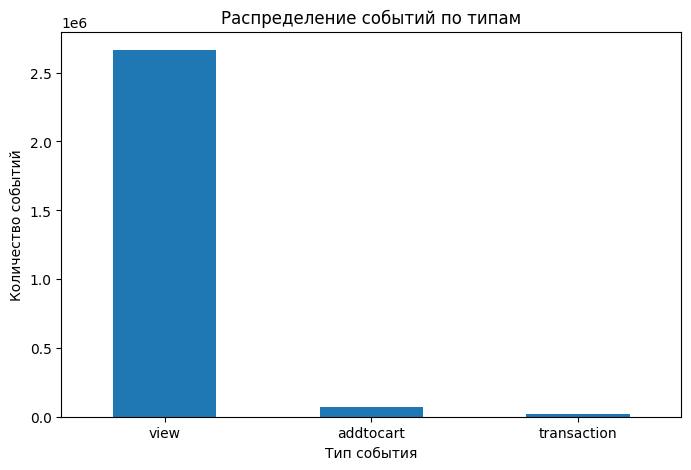

In [ ]:
# Считаем количество событий каждого типа
event_funnel = (
    events["event"]
    .value_counts()
    .reindex(["view", "addtocart", "transaction"])
)

# Визуализируем распределение событий по типам
event_funnel.plot(kind="bar", figsize=(8, 5))

plt.title("Распределение событий по типам")
plt.xlabel("Тип события")
plt.ylabel("Количество событий")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Рассчитываем событийные конверсии между этапами воронки
view_to_cart_events = event_funnel["addtocart"] / event_funnel["view"]
cart_to_purchase_events = event_funnel["transaction"] / event_funnel["addtocart"]
view_to_purchase_events = event_funnel["transaction"] / event_funnel["view"]

print(f"Event view → addtocart: {view_to_cart_events:.2%}")
print(f"Event addtocart → transaction: {cart_to_purchase_events:.2%}")
print(f"Event view → transaction: {view_to_purchase_events:.2%}")

Event view → addtocart: 2.59%
Event addtocart → transaction: 32.56%
Event view → transaction: 0.84%


В данных сильно преобладают просмотры товаров:
* view: 2 664 218 событий — 96.68%
* addtocart: 68 966 событий — 2.50%
* transaction: 22 457 событий — 0.81%

- Очень низкая конверсия из просмотра в добавление в корзину (~2.6%)  
Большинство пользователей просматривают товары, но не проявляют явного намерения к покупке

- Достаточно высокая конверсия из корзины в покупку (~32.6%)  
Если пользователь добавил товар в корзину, вероятность покупки заметно возрастает

- Общая конверсия просмотра в покупку остаётся низкой (~0.84%)  
Основной “провал” воронки происходит на раннем этапе интереса к товару

Это указывает на потенциал улучшения рекомендательной системы, карточек товаров и механик вовлечения пользователя.

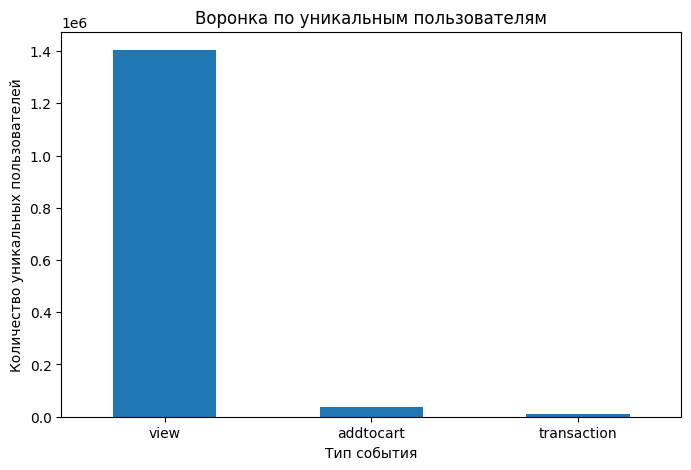

In [ ]:
# считаем, сколько уникальных пользователей дошло до каждого этапа
user_funnel = (
    events
    .groupby("event")["visitorid"]
    .nunique()
    .reindex(["view", "addtocart", "transaction"])
)

# Визуализируем воронку по уникальным пользователям
user_funnel.plot(kind="bar", figsize=(8, 5))

plt.title("Воронка по уникальным пользователям")
plt.xlabel("Тип события")
plt.ylabel("Количество уникальных пользователей")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Рассчитываем пользовательские конверсии активности между этапами воронки
view_to_cart_users = user_funnel["addtocart"] / user_funnel["view"]
cart_to_purchase_users = user_funnel["transaction"] / user_funnel["addtocart"]
view_to_purchase_users = user_funnel["transaction"] / user_funnel["view"]

print(f"User view → addtocart: {view_to_cart_users:.2%}")
print(f"User addtocart → transaction: {cart_to_purchase_users:.2%}")
print(f"User view → transaction: {view_to_purchase_users:.2%}")

User view → addtocart: 2.69%
User addtocart → transaction: 31.07%
User view → transaction: 0.83%


В данных сильно преобладают просмотры товаров, тогда как добавления в корзину и покупки встречаются значительно реже. До покупки доходит менее 1% пользователей, просмотревших товары.

При этом этап `addtocart` является важным сигналом покупательского намерения: среди пользователей, добавивших товар в корзину, доля дошедших до покупки заметно выше. Поэтому признаки, связанные с корзиной, будут важны при построении модели предсказания покупки.

### Анализ пользователей

In [ ]:
# Общее количество пользователей
n_users = events["visitorid"].nunique()
print("Всего пользователей:", n_users)

Всего пользователей: 1407580


In [ ]:
# сколько действий совершает каждый пользователь
user_activity = events.groupby("visitorid").size()
user_activity.describe()

,0
count,1.407580e+06
mean,1.957715e+00
std,1.257981e+01
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,7.757000e+03


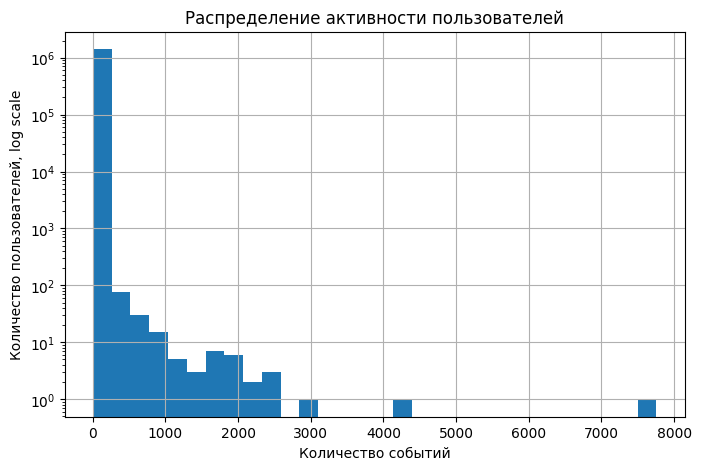

In [ ]:
# визуализация распределения
# логарифмическая шкала нужна из-за сильной асимметрии распределения
user_activity.hist(bins=30, figsize=(8, 5))

plt.yscale("log")
plt.title("Распределение активности пользователей")
plt.xlabel("Количество событий")
plt.ylabel("Количество пользователей, log scale")
plt.show()

Большинство пользователей совершают всего 1–2 действия, тогда как небольшая группа пользователей генерирует значительно больше событий. Такое распределение указывает на неоднородность аудитории и подтверждает необходимость дальнейшей сегментации пользователей.

In [ ]:
# уникальные пользователи, которые совершили покупку
buyers = events[events["event"] == "transaction"]["visitorid"].nunique()

print("Покупающие пользователи:", buyers)
print("Доля покупателей:", buyers / n_users)

Покупающие пользователи: 11719
Доля покупателей: 0.00832563690873698


In [ ]:
# выделим условно активных пользователей(сделали > 5 действий)
active_users = (user_activity > 5).sum()

print("Активные пользователи:", active_users)
print("Доля активных:", active_users / n_users)

Активные пользователи: 58627
Доля активных: 0.04165091859787721


In [ ]:
# пользователи без покупок
non_buyers = n_users - buyers

print("Пользователи без покупок:", non_buyers)
print("Доля:", non_buyers / n_users)

Пользователи без покупок: 1395861
Доля: 0.991674363091263


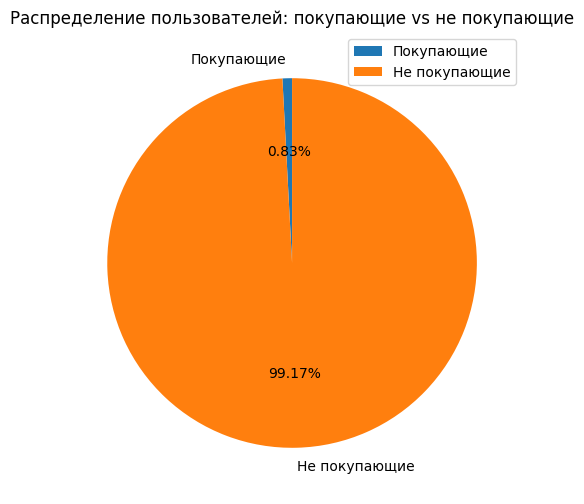

In [ ]:
labels = ["Покупающие", "Не покупающие"]
sizes = [buyers, non_buyers]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)
plt.legend()
plt.title("Распределение пользователей: покупающие vs не покупающие")
plt.show()

- покупающие пользователи: **11 719 (0.83%)**
- активные пользователи: **58 627 (4.17%)**
- пользователи без покупок: **1 395 861 (99.17%)**


Покупку совершает очень небольшая доля пользователей. Это подтверждает сильный дисбаланс между покупателями и непокупателями.

Для дальнейшего ML-моделирования это означает, что accuracy не должна быть основной метрикой качества. В модели предсказания покупки нужно использовать метрики, более устойчивые к дисбалансу классов: PR-AUC, ROC-AUC, precision, recall и F1-score.

### Анализ товаров

In [ ]:
# Считаем количество уникальных товаров
n_items = events["itemid"].nunique()

print("Всего товаров:", n_items)

Всего товаров: 235061


In [ ]:
# Считаем количество событий на каждый товар
item_activity = events.groupby("itemid").size()

# Смотрим базовые статистики популярности товаров
item_activity.describe()

,0
count,235061.000000
mean,11.723089
std,37.024810
min,1.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,3412.000000


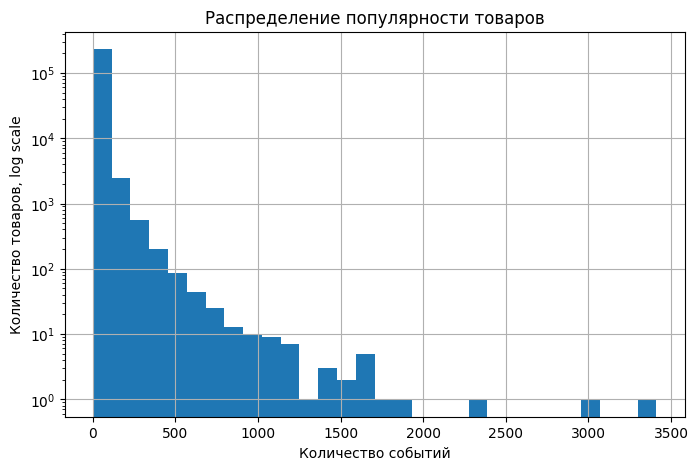

In [ ]:
# Визуализируем распределение популярности товаров
# Логарифмическая шкала помогает увидеть распределение
item_activity.hist(bins=30, figsize=(8, 5))

plt.yscale("log")
plt.title("Распределение популярности товаров")
plt.xlabel("Количество событий")
plt.ylabel("Количество товаров, log scale")
plt.show()

In [ ]:
# Смотрим топ-10 товаров по количеству взаимодействий
top_items = item_activity.sort_values(ascending=False).head(10)

top_items

,0
itemid,
187946,3412
461686,2975
5411,2334
370653,1854
219512,1800
257040,1647
298009,1642
96924,1633
309778,1628


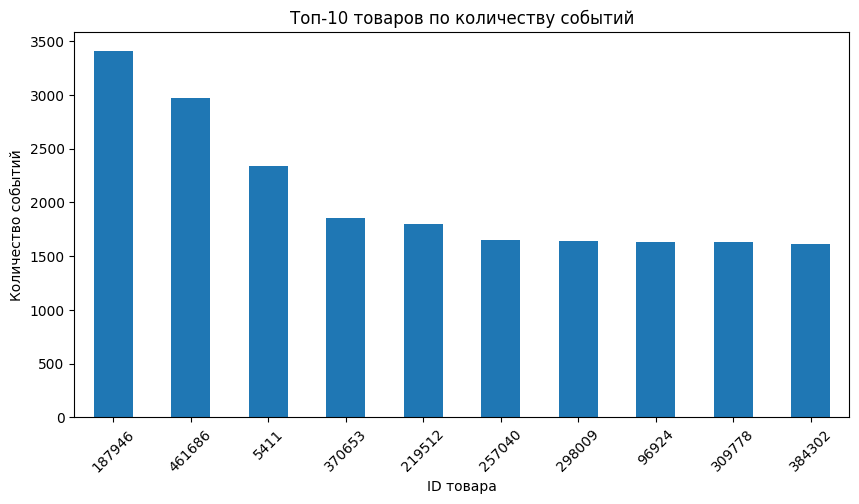

In [ ]:
# топ-10 самых популярных товаров
top_items.plot(kind="bar", figsize=(10, 5))

plt.title("Топ-10 товаров по количеству событий")
plt.xlabel("ID товара")
plt.ylabel("Количество событий")
plt.xticks(rotation=45)
plt.show()

Популярность товаров распределена неравномерно. В данных представлено 235 061 товар, но медианный товар имеет только 3 события, а 75% товаров имеют не более 9 событий.

Среднее число событий на товар: 11.72

Медиана: 3 события

75% товаров: не более 9 событий

95% товаров: не более 47 событий

99% товаров: не более 143 событий

Максимум: 3412 события

### Анализ покупок и конверсии товаров

Популярность товара не всегда означает высокую вероятность покупки. Поэтому отдельно посмотрим на товары с покупками и рассчитаем товарные conversion rate.

In [ ]:
# Строим таблицу с количеством событий каждого типа для каждого товара
item_stats = (
    events
    .pivot_table(
        index="itemid",
        columns="event",
        values="visitorid",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

# Убираем имя уровня колонок после pivot_table
item_stats.columns.name = None

# На случай, если какой-то тип события отсутствует, добавим колонку с нулями
for col in ["view", "addtocart", "transaction"]:
    if col not in item_stats.columns:
        item_stats[col] = 0

item_stats.head()

,itemid,addtocart,transaction,view
0,3,0,0,2
1,4,0,0,3
2,6,0,0,29
3,9,0,0,2
4,15,3,1,18


In [ ]:
# сколько покупок приходится на один просмотр
item_stats["purchase_to_view_ratio"] = (
    item_stats["transaction"] / item_stats["view"].replace(0, np.nan)
)

# Рассчитываем отношение добавлений в корзину к просмотрам
item_stats["cart_to_view_ratio"] = (
    item_stats["addtocart"] / item_stats["view"].replace(0, np.nan)
)

item_stats.head()

,itemid,addtocart,transaction,view,purchase_to_view_ratio,cart_to_view_ratio
0,3,0,0,2,0.000000,0.000000
1,4,0,0,3,0.000000,0.000000
2,6,0,0,29,0.000000,0.000000
3,9,0,0,2,0.000000,0.000000
4,15,3,1,18,0.055556,0.166667


In [ ]:
# Смотрим товары с наибольшим количеством покупок
top_purchased_items = (
    item_stats
    .sort_values("transaction", ascending=False)
    .head(10)
)

top_purchased_items[
    ["itemid", "view", "addtocart", "transaction", "purchase_to_view_ratio"]
]

,itemid,view,addtocart,transaction,purchase_to_view_ratio
232496,461686,2538,304,133,0.052403
60527,119736,752,44,97,0.128989
107690,213834,293,17,92,0.313993
3980,7943,1346,97,46,0.034175
157492,312728,947,161,46,0.048574
224330,445351,939,89,45,0.047923
24339,48030,986,95,41,0.041582
125146,248455,575,52,38,0.066087
212061,420960,795,60,38,0.047799
8763,17478,631,72,37,0.058637


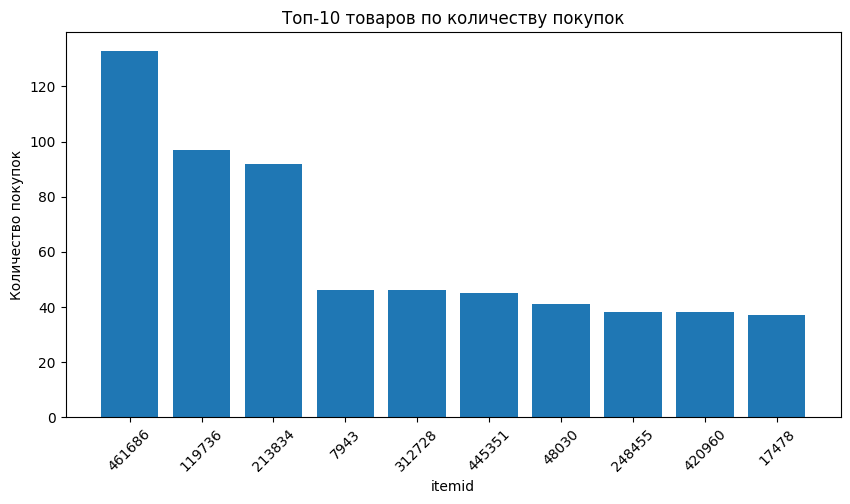

In [ ]:
# Визуализируем топ-10 товаров по количеству покупок
plt.figure(figsize=(10, 5))

plt.bar(
    top_purchased_items["itemid"].astype(str),
    top_purchased_items["transaction"]
)

plt.title("Топ-10 товаров по количеству покупок")
plt.xlabel("itemid")
plt.ylabel("Количество покупок")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# конверсия товаров
# Для анализа берём только товары с достаточным количеством просмотров.
filtered_items = item_stats[item_stats["view"] >= 50].copy()

top_conversion_items = (
    filtered_items
    .sort_values("purchase_to_view_ratio", ascending=False)
    .head(10)
)

top_conversion_items[
    ["itemid", "view", "addtocart", "transaction", "purchase_to_view_ratio"]
]

,itemid,view,addtocart,transaction,purchase_to_view_ratio
107690,213834,293,17,92,0.313993
87519,173653,61,18,11,0.180328
191416,379953,67,15,11,0.164179
168412,334401,200,8,28,0.140000
202727,402462,53,16,7,0.132075
60527,119736,752,44,97,0.128989
203903,404793,55,12,7,0.127273
72635,143860,51,13,6,0.117647
222993,442725,71,7,8,0.112676
108929,216266,81,11,9,0.111111


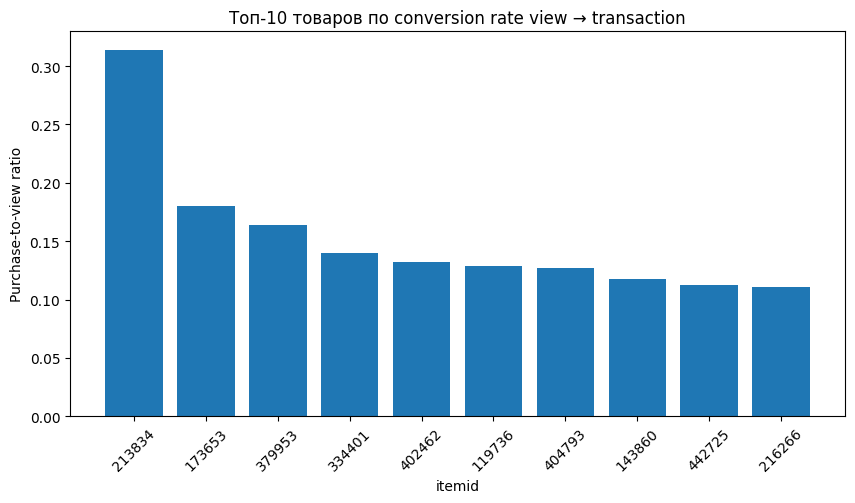

In [ ]:
# Визуализируем товары с наибольшей конверсией view → transaction
plt.figure(figsize=(10, 5))

plt.bar(
    top_conversion_items["itemid"].astype(str),
    top_conversion_items["purchase_to_view_ratio"]
)

plt.title("Топ-10 товаров по conversion rate view → transaction")
plt.xlabel("itemid")
plt.ylabel("Purchase-to-view ratio")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Найдём товары с большим количеством просмотров, но без покупок
viewed_not_bought = (
    item_stats[
        (item_stats["view"] >= 50) &
        (item_stats["transaction"] == 0)
    ]
    .sort_values("view", ascending=False)
    .head(10)
)

viewed_not_bought[["itemid", "view", "addtocart", "transaction"]]

,itemid,view,addtocart,transaction
94720,187946,3410,2,0
2719,5411,2325,9,0
186716,370653,1854,0,0
150148,298009,1642,0,0
49024,96924,1633,0,0
169261,335975,1428,0,0
76432,151444,1230,0,0
71944,142466,1135,1,0
218935,434782,1069,0,0
46393,91755,1024,0,0


Только 12 025 товаров из 235 061 хотя бы раз были куплены, то есть покупки есть примерно у 5.12% товаров.

Самые популярные товары и товары с высокой конверсией не всегда совпадают. Популярность отражает объём пользовательского внимания, а conversion rate показывает способность товара доводить пользователя до покупки.

* Товаров с хотя бы одной покупкой: 12 025 — 5.12%
* Товаров с хотя бы одним добавлением в корзину: 23 903 — 10.17%
* Товаров, которые просматривали, но не покупали: около 94.79%
* Товаров с >= 50 просмотрами: 10 606
* Из них без покупок: 5 685 — 53.60%

### Анализ временных паттернов поведения пользователей

In [ ]:
# временные признаки
events["date"] = events["timestamp"].dt.date
events["hour"] = events["timestamp"].dt.hour
events["dayofweek"] = events["timestamp"].dt.dayofweek

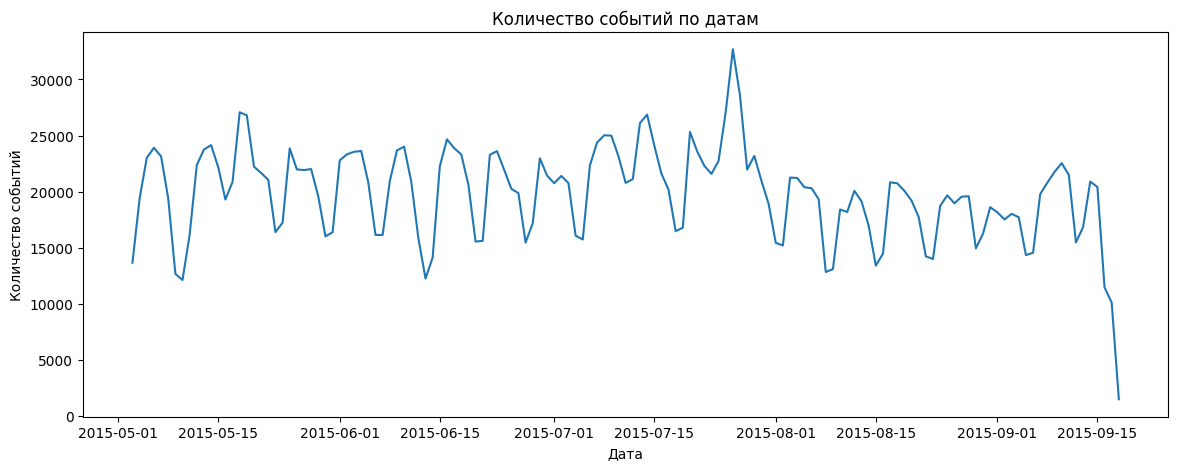

In [ ]:
# Считаем количество событий по датам
events_by_date = events.groupby("date").size()

# Визуализируем динамику общего числа событий по датам
events_by_date.plot(figsize=(14, 5))

plt.title("Количество событий по датам")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.show()

In [ ]:
# Активность по дням недели — выявляем пиковые дни для планирования кампаний
events_by_dayofweek = events.groupby("dayofweek").size()

events_by_dayofweek

,0
dayofweek,
0,439738
1,447006
2,431059
3,418672
4,379624
5,305167
6,334375


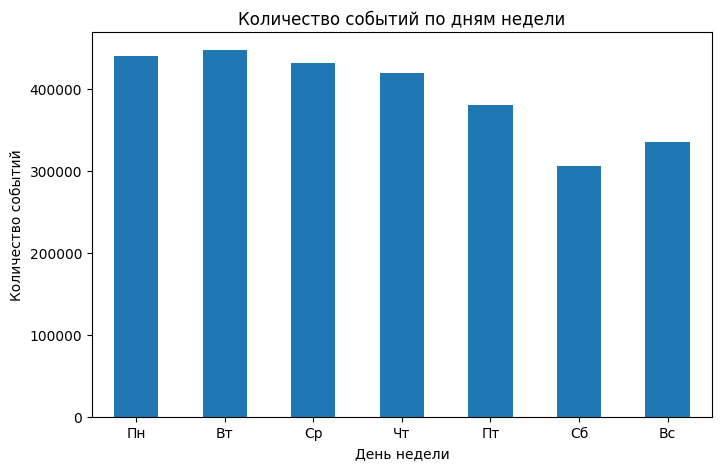

In [ ]:
# Переименуем дни недели для более понятной визуализации
day_names = {
    0: "Пн",
    1: "Вт",
    2: "Ср",
    3: "Чт",
    4: "Пт",
    5: "Сб",
    6: "Вс"
}

events_by_dayofweek.index = events_by_dayofweek.index.map(day_names)

events_by_dayofweek.plot(kind="bar", figsize=(8, 5))

plt.title("Количество событий по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество событий")
plt.xticks(rotation=0)
plt.show()

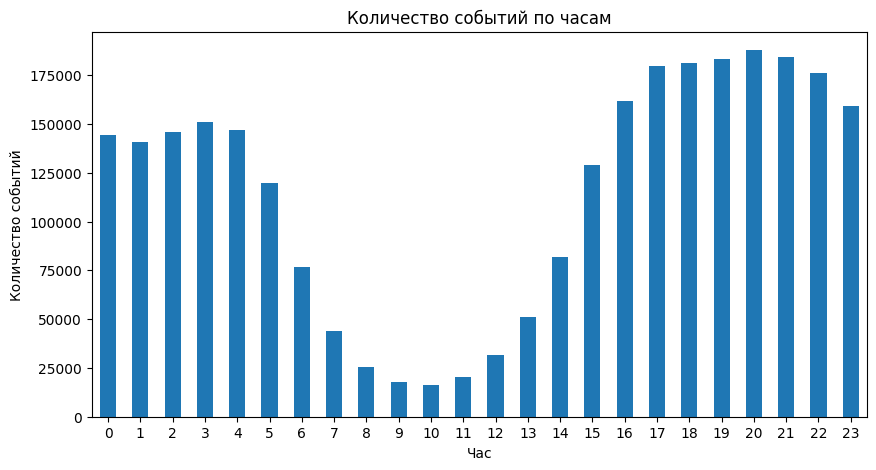

In [ ]:
# активность пользователей по часам
events_by_hour = events.groupby("hour").size()

events_by_hour.plot(kind="bar", figsize=(10, 5))

plt.title("Количество событий по часам")
plt.xlabel("Час")
plt.ylabel("Количество событий")
plt.xticks(rotation=0)
plt.show()

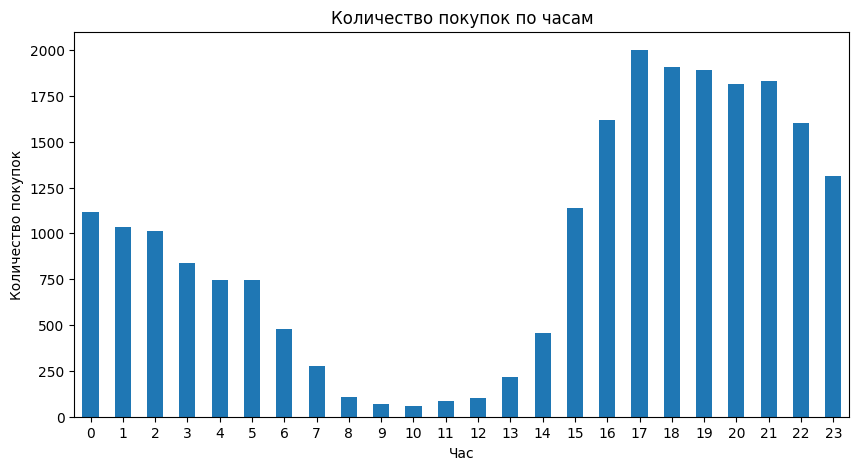

In [ ]:
# покупки по часам
transactions_by_hour = (
    events[events["event"] == "transaction"]
    .groupby("hour")
    .size()
)

transactions_by_hour.plot(kind="bar", figsize=(10, 5))

plt.title("Количество покупок по часам")
plt.xlabel("Час")
plt.ylabel("Количество покупок")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Давность последней активности пользователей

# Для каждого пользователя найдём время последнего события
user_last_event = (
    events
    .groupby("visitorid", sort=False)["timestamp"]
    .max()
    .reset_index()
    .rename(columns={"timestamp": "last_event_time"})
)

# Считаем давность последнего действия относительно конца периода наблюдений
max_timestamp = events["timestamp"].max()

user_last_event["recency_hours"] = (
    max_timestamp - user_last_event["last_event_time"]
).dt.total_seconds() / 3600

user_last_event["recency_days"] = user_last_event["recency_hours"] / 24

user_last_event["recency_days"].describe()

,recency_days
count,1.407580e+06
mean,6.832110e+01
std,3.916082e+01
min,0.000000e+00
25%,3.542847e+01
50%,6.707738e+01
75%,1.020853e+02
max,1.379997e+02


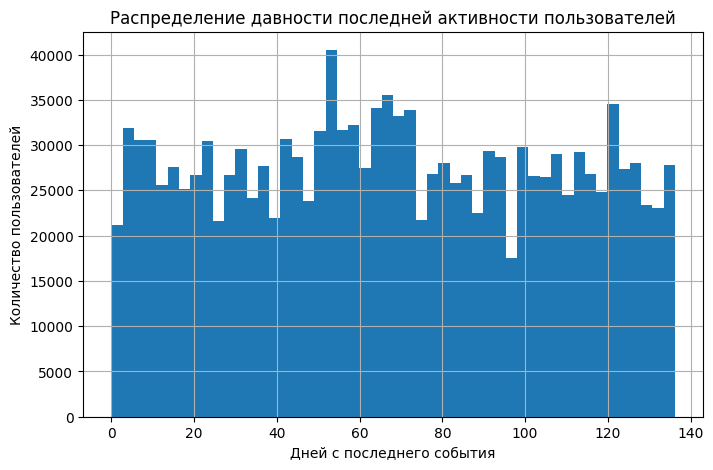

In [ ]:
# Визуализируем распределение давности последней активности
upper_limit = user_last_event["recency_days"].quantile(0.99)

user_last_event.loc[
    user_last_event["recency_days"] <= upper_limit,
    "recency_days"
].hist(bins=50, figsize=(8, 5))

plt.title("Распределение давности последней активности пользователей")
plt.xlabel("Дней с последнего события")
plt.ylabel("Количество пользователей")
plt.show()

Данные покрывают период с 2015-05-03 по 2015-09-18. В среднем в день происходит около 19.8 тыс. событий, однако активность заметно меняется по датам, дням недели и часам.

Наибольшая общая активность наблюдается в вечерние часы, особенно с 17 до 21 часа. Покупки также чаще происходят ближе к вечеру: максимум транзакций приходится на 17–19 часов.

* Больше всего событий: вторник — 447 006
* Меньше всего событий: суббота — 305 167

* Больше всего покупок: среда — 4 151
* Меньше всего покупок: суббота — 1 811


`Вывод по EDA:`

EDA показал выраженную конверсионную воронку: просмотры составляют 96.68% всех событий, а покупки — только 0.81%.

До покупки доходит около 0.83% пользователей, просмотревших товары, что подтверждает проблему низкой конверсии.

Событие 'addtocart' является сильным сигналом покупательского намерения: среди пользователей, добавивших товар в корзину, около 31.07% совершили покупку.

В данных есть экстремально активные пользователи и очень популярные товары. Однако такие значения не выглядят как ошибки данных: для e-commerce характерны длинные хвосты, когда небольшая часть пользователей и товаров генерирует значительную долю событий, поэтому за выбросы из не считаем и удалять не будем.

Активность пользователей и популярность товаров распределены неравномерно: большинство пользователей совершают 1–2 действия, а большинство товаров получает мало взаимодействий. Это обосновывает дальнейшую сегментацию пользователей и построение рекомендательной системы.

Данные имеют временную структуру: активность пользователей меняется по датам, дням недели и часам.

## Этап 3. Статистический анализ

На этапе EDA были выявлены несколько важных закономерностей:

- пользователи, которые доходят до покупки, выглядят более активными;
- добавление товара в корзину связано с более высокой вероятностью покупки

На этом этапе проверим эти наблюдения статистически.

Временное разделение позволяет проверить, отличаются ли пользователи, которые купят в будущем, уже на этапе исторического поведения.

In [ ]:
from scipy import stats

# Уровень значимости
alpha = 0.05

In [ ]:
# функция для интерпретации статистических тестов
def print_test_result(p_value, alpha=0.05):
    """
    Интерпретирует результат статистического теста на основе p-value.

    Parameters
    ----------
    p_value : float
        p-value статистического теста.
    alpha : float
        Уровень значимости.
    """

    print("p-value = {:.3e}".format(p_value))

    if p_value <= alpha:
        print(
            "p-значение меньше, чем заданный уровень значимости {:.2f}. "
            "Отвергаем нулевую гипотезу в пользу альтернативной."
            .format(alpha)
        )
    else:
        print(
            "p-значение больше, чем заданный уровень значимости {:.2f}. "
            "У нас нет оснований отвергнуть нулевую гипотезу."
            .format(alpha)
        )

In [ ]:
# Делим данные по времени.
# В качестве границы используем 80% временного периода.
split_time = events["timestamp"].quantile(0.8)

history_df = events[events["timestamp"] < split_time].copy()
future_df = events[events["timestamp"] >= split_time].copy()

print("Исторический период:")
print(history_df["timestamp"].min(), "—", history_df["timestamp"].max())

print("\nБудущий период:")
print(future_df["timestamp"].min(), "—", future_df["timestamp"].max())

print("\nРазмер history_df:", history_df.shape)
print("Размер future_df:", future_df.shape)

Исторический период:
2015-05-03 03:00:04.384000 — 2015-08-18 04:23:01.129000

Будущий период:
2015-08-18 04:23:20.445000 — 2015-09-18 02:59:47.788000

Размер history_df: (2204512, 9)
Размер future_df: (551129, 9)


In [ ]:
# Создаём таблицу пользователей из исторического периода
stat_users = (
    history_df[["visitorid"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Определяем пользователей, которые совершили покупку в будущем периоде
future_buyers = (
    future_df[future_df["event"] == "transaction"]["visitorid"]
    .drop_duplicates()
    .to_frame()
)

future_buyers["target"] = 1

# Добавляем target:
# 1 — пользователь купил в будущем периоде
# 0 — пользователь не купил в будущем периоде
stat_users = stat_users.merge(
    future_buyers,
    on="visitorid",
    how="left"
)

# Если пользователь не найден среди будущих покупателей, значит target = 0
stat_users["target"] = stat_users["target"].fillna(0).astype(int)

stat_users["target"].value_counts()

,count
target,
0,1123413
1,352


In [ ]:
# Доли классов
stat_users["target"].value_counts(normalize=True) * 100

,proportion
target,
0,99.968677
1,0.031323


В будущем периоде покупку совершили 352 пользователя из пользователей, присутствовавших в историческом периоде. Доля положительного класса составляет около 0.03%, что подтверждает сильный дисбаланс целевой переменной.

In [ ]:
# Создаём бинарные признаки событий
history_df["is_view"] = (history_df["event"] == "view").astype("int8")
history_df["is_cart"] = (history_df["event"] == "addtocart").astype("int8")
history_df["is_transaction"] = (history_df["event"] == "transaction").astype("int8")

# Агрегируем историческое поведение пользователей
user_stats = (
    history_df
    .groupby("visitorid", sort=False)
    .agg(
        total_events=("event", "size"),
        unique_items=("itemid", "nunique"),
        active_days=("date", "nunique"),
        views=("is_view", "sum"),
        carts=("is_cart", "sum"),
        transactions=("is_transaction", "sum")
    )
    .reset_index()
)

# Добавляем target будущей покупки
user_stats = user_stats.merge(
    stat_users[["visitorid", "target"]],
    on="visitorid",
    how="left"
)

user_stats.head()

,visitorid,total_events,unique_items,active_days,views,carts,transactions,target
0,693516,3,1,1,1,2,0,0
1,829044,1,1,1,1,0,0,0
2,652699,1,1,1,1,0,0,0
3,1125936,1,1,1,1,0,0,0
4,1149227,1,1,1,1,0,0,0


In [ ]:
# Сравним базовые характеристики будущих покупателей и непокупателей
user_stats.groupby("target")[
    ["total_events", "unique_items", "active_days", "views", "carts", "transactions"]
].agg(["mean", "median"])

total_events        unique_items        active_days             views  \
               mean median         mean median        mean median       mean   
target                                                                         
0          1.937084    1.0     1.510831    1.0    1.161481    1.0   1.875848   
1         80.588068    4.0    45.125000    2.0    5.741477    1.0  69.903409   

                  carts        transactions         
       median      mean median         mean median  
target                                              
0         1.0  0.046620    0.0     0.014616    0.0  
1         3.0  6.582386    0.0     4.102273    0.0

Предварительное сравнение показывает, что будущие покупатели в среднем активнее: они совершают больше событий, взаимодействуют с большим количеством товаров и чаще добавляют товары в корзину. Далее проверим эти различия статистически.

Перед выбором статистического теста проверим распределения ключевых признаков активности, чтобы выбрать тип теста.

Для формальной проверки используем D’Agostino–Pearson test.

H0: распределение признака является нормальным.

In [ ]:
# Выберем признаки активности, которые будем сравнивать между группами
activity_features = ["total_events", "unique_items", "active_days"]

# ассиметрия распределений
user_stats[activity_features].skew()

,0
total_events,240.635906
unique_items,199.957956
active_days,27.894546


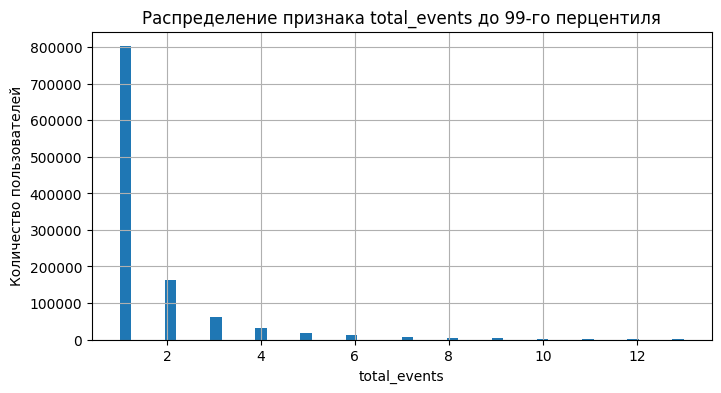

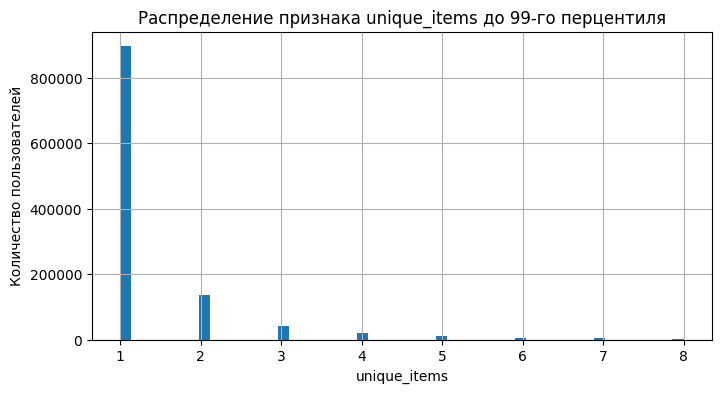

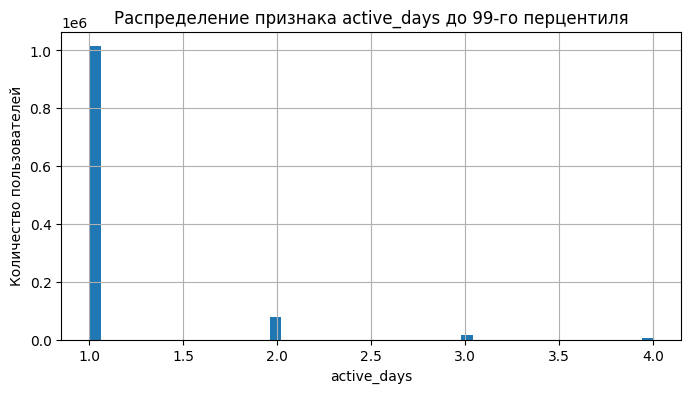

In [ ]:
# Визуализируем распределения признаков.
# Ограничиваем значения 99-м перцентилем, чтобы графики не искажались экстремальными выбросами.
for feature in activity_features:
    upper_limit = user_stats[feature].quantile(0.99)

    plt.figure(figsize=(8, 4))

    user_stats.loc[user_stats[feature] <= upper_limit, feature].hist(bins=50)

    plt.title(f"Распределение признака {feature} до 99-го перцентиля")
    plt.xlabel(feature)
    plt.ylabel("Количество пользователей")
    plt.show()

In [ ]:
# Формальная проверка нормальности D’Agostino–Pearson test
normality_results = []

for feature in activity_features:
    statistic, p_value = stats.normaltest(user_stats[feature])

    normality_results.append({
        "feature": feature,
        "statistic": statistic,
        "p_value": p_value,
        "is_normal_0.05": p_value >= 0.05
    })

normality_results = pd.DataFrame(normality_results)

normality_results

,feature,statistic,p_value,is_normal_0.05
0,total_events,5.795326e+06,0.0,False
1,unique_items,5.499663e+06,0.0,False
2,active_days,2.844157e+06,0.0,False


Признаки активности имеют сильную правостороннюю асимметрию и длинные хвосты: большинство пользователей совершает мало действий, а небольшая группа пользователей значительно активнее.

D’Agostino–Pearson показывает статистически значимое отклонение от нормального распределения. Поэтому для сравнения будущих покупателей и непокупателей используем непараметрический Mann–Whitney U test.

Гипотеза 1: будущие покупатели активнее в историческом периоде

**H0:** распределения признаков активности у будущих покупателей и непокупателей не отличаются.  
**H1:** распределения признаков активности у будущих покупателей и непокупателей отличаются.

Для проверки используем Mann–Whitney U test.

In [ ]:
# Функция для применения Mann–Whitney U test к выбранному признаку
def mann_whitney_test(data, feature, target_col="target", alpha=0.05):
    """
    Применяет Mann–Whitney U test для сравнения признака
    между будущими покупателями и непокупателями.
    """

    # Группа 1: пользователи, которые купили в будущем
    group_1 = data.loc[data[target_col] == 1, feature]

    # Группа 0: пользователи, которые не купили в будущем
    group_0 = data.loc[data[target_col] == 0, feature]

    statistic, p_value = stats.mannwhitneyu(
        group_1,
        group_0,
        alternative="two-sided"
    )

    print(f"Признак: {feature}")
    print("Статистика теста = {:.3f}".format(statistic))
    print_test_result(p_value, alpha)
    print("Медиана target=1: {:.2f}".format(group_1.median()))
    print("Медиана target=0: {:.2f}".format(group_0.median()))
    print("-" * 70)

    return {
        "feature": feature,
        "median_target_1": group_1.median(),
        "median_target_0": group_0.median(),
        "mean_target_1": group_1.mean(),
        "mean_target_0": group_0.mean(),
        "u_statistic": statistic,
        "p_value": p_value,
        "significant_0.05": p_value < alpha
    }

In [ ]:
# Проверяем различия по ключевым признакам активности
mann_whitney_results = []

for feature in activity_features:
    result = mann_whitney_test(
        data=user_stats,
        feature=feature,
        target_col="target",
        alpha=alpha
    )

    mann_whitney_results.append(result)

mann_whitney_results = pd.DataFrame(mann_whitney_results)
mann_whitney_results

Признак: total_events
Статистика теста = 299317402.000
p-value = 1.057e-97
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
Медиана target=1: 4.00
Медиана target=0: 1.00
----------------------------------------------------------------------
Признак: unique_items
Статистика теста = 285289144.000
p-value = 1.510e-93
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
Медиана target=1: 2.00
Медиана target=0: 1.00
----------------------------------------------------------------------
Признак: active_days
Статистика теста = 274930497.000
p-value = 4.757e-134
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.
Медиана target=1: 1.00
Медиана target=0: 1.00
----------------------------------------------------------------------


,feature,median_target_1,median_target_0,mean_target_1,mean_target_0,u_statistic,p_value,significant_0.05
0,total_events,4.0,1.0,80.588068,1.937084,299317402.0,1.056983e-97,True
1,unique_items,2.0,1.0,45.125000,1.510831,285289144.0,1.510198e-93,True
2,active_days,1.0,1.0,5.741477,1.161481,274930497.0,4.756538e-134,True


Манна-Уитни показывает статистически значимые различия между будущими покупателями и непокупателями по признакам активности.

Будущие покупатели в историческом периоде совершают больше событий, взаимодействуют с большим количеством уникальных товаров и имеют больше активных дней.

`Гипотеза 2: добавление в корзину связано с будущей покупкой`

Проверим, связано ли наличие события 'addtocart' в историческом периоде с покупкой в будущем периоде.

**H0:** факт добавления товара в корзину и будущая покупка независимы.  
**H1:** между добавлением товара в корзину и будущей покупкой есть статистически значимая связь.

Так как обе переменные категориальные, используем chi-square test.

In [ ]:
# Формируем флаг: было ли хотя бы одно добавление в корзину в историческом периоде
user_cart_flag = user_stats[["visitorid", "carts", "target"]].copy()

user_cart_flag["had_cart"] = (
    user_cart_flag["carts"] > 0
).astype("int8")

user_cart_flag.head()

,visitorid,carts,target,had_cart
0,693516,2,0,1
1,829044,0,0,0
2,652699,0,0,0
3,1125936,0,0,0
4,1149227,0,0,0


In [ ]:
# Таблица сопряжённости:
# строки — был ли addtocart в истории,
# столбцы — была ли покупка в будущем
contingency_table = pd.crosstab(
    user_cart_flag["had_cart"],
    user_cart_flag["target"]
)

contingency_table

target,0,1
had_cart,,
0,1093646,228
1,29767,124


In [ ]:
# Применяем chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic = {:.3f}".format(chi2))
print("Degrees of freedom = {}".format(dof))
print_test_result(p_value, alpha)

Chi-square statistic = 1429.851
Degrees of freedom = 1
p-value = 0.000e+00
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


In [ ]:
# Сравним долю будущих покупателей среди пользователей с корзиной и без корзины
cart_purchase_rate = (
    user_cart_flag
    .groupby("had_cart")["target"]
    .mean()
)

cart_purchase_rate

,target
had_cart,
0,0.000208
1,0.004148


Сhi-square показывает статистически значимую связь между добавлением товара в корзину в историческом периоде и покупкой в будущем.

`Вывод по этапу статистического анализа:`

**Mann–Whitney U test** подтвердил, что будущие покупатели статистически значимо отличаются от непокупателей по исторической активности: количеству событий, уникальных товаров и активных дней.

**Chi-square test** подтвердил статистически значимую связь между событием добавления в корзину и будущей покупкой. Доля будущих покупателей среди пользователей с `addtocart` почти в 20 раз выше, чем среди пользователей без добавления в корзину.



## Этап 4. Feature Engineering для модели предсказания покупки

Формируем датасет для задачи предсказания будущей покупки пользователя.

Одна строка итогового датасета соответствует одному пользователю:

- признаки строятся только на историческом периоде;
- целевая переменная показывает, совершил ли пользователь покупку в будущем периоде.

Такой подход позволяет избежать утечки данных и сохранить постановку задачи, согласованную со статистическим анализом.

In [ ]:
# базовый df
df_ml = (
    history_df[["visitorid"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Находим пользователей, которые совершили покупку в будущем периоде
future_buyers = (
    future_df[future_df["event"] == "transaction"]["visitorid"]
    .drop_duplicates()
    .to_frame()
)

future_buyers["target"] = 1

# Добавляем target:
# 1 — пользователь купил в будущем периоде
# 0 — пользователь не купил в будущем периоде
df_ml = df_ml.merge(
    future_buyers,
    on="visitorid",
    how="left"
)

df_ml["target"] = df_ml["target"].fillna(0).astype("int8")

df_ml.head()

,visitorid,target
0,693516,0
1,829044,0
2,652699,0
3,1125936,0
4,1149227,0


#### 4.1 Пользовательские признаки активности

In [ ]:
# базовые признаки активности пользователя
user_activity_features = (
    history_df
    .groupby("visitorid")
    .agg(
        # общее количество действий пользователя
        user_total_events=("event", "count"),

        # количество уникальных товаров, с которыми пользователь взаимодействовал
        user_unique_items=("itemid", "nunique"),

        # количество активных дней пользователя
        user_active_days=("date", "nunique"),

        # первое действие пользователя в историческом периоде
        user_first_seen=("timestamp", "min"),

        # последнее действие пользователя в историческом периоде
        user_last_seen=("timestamp", "max"),

        # средний час активности пользователя
        user_avg_hour=("hour", "mean"),
    )
    .reset_index()
)

user_activity_features.head()

,visitorid,user_total_events,user_unique_items,user_active_days,user_first_seen,user_last_seen,user_avg_hour
0,1,1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,17.000000
1,2,8,4,1,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,17.625000
2,3,1,1,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,7.000000
3,5,1,1,1,2015-07-17 01:45:56.439,2015-07-17 01:45:56.439,1.000000
4,7,3,3,2,2015-05-14 05:39:36.753,2015-05-16 04:20:39.214,4.666667


In [ ]:
# Считаем длительность пользовательской истории в днях
user_activity_features["user_lifetime_days"] = (
    user_activity_features["user_last_seen"] - user_activity_features["user_first_seen"]
).dt.total_seconds() / (3600 * 24)

# Считаем давность последнего события относительно даты разделения
user_activity_features["user_recency_hours"] = (
    split_time - user_activity_features["user_last_seen"]
).dt.total_seconds() / 3600

# Среднее количество событий на активный день
user_activity_features["user_events_per_active_day"] = (
    user_activity_features["user_total_events"] /
    user_activity_features["user_active_days"].replace(0, np.nan)
)

# Удаляем сырые datetime-колонки:
user_activity_features = user_activity_features.drop(
    columns=["user_first_seen", "user_last_seen"],
    errors="ignore"
)

user_activity_features.head()

,visitorid,user_total_events,user_unique_items,user_active_days,user_avg_hour,user_lifetime_days,user_recency_hours,user_events_per_active_day
0,1,1,1,1,17.000000,0.000000,106.620556,1.0
1,2,8,4,1,17.625000,0.020293,250.039611,8.0
2,3,1,1,1,7.000000,0.000000,405.212541,1.0
3,5,1,1,1,1.000000,0.000000,770.623335,1.0
4,7,3,3,2,4.666667,1.945167,2256.044786,1.5


#### 4.3 Признаки поведения в воронке

In [ ]:
# Создаём бинарные флаги событий.
history_df["is_view"] = (history_df["event"] == "view").astype("int8")
history_df["is_cart"] = (history_df["event"] == "addtocart").astype("int8")
history_df["is_transaction"] = (history_df["event"] == "transaction").astype("int8")

In [ ]:
# Считаем количество событий каждого типа на пользователя
user_event_features = (
    history_df
    .groupby("visitorid", sort=False)
    .agg(
        user_views_count=("is_view", "sum"),
        user_cart_count=("is_cart", "sum"),
        user_past_purchase_count=("is_transaction", "sum")
    )
    .reset_index()
)

# Общее количество событий воронки
user_event_total = (
    user_event_features["user_views_count"] +
    user_event_features["user_cart_count"] +
    user_event_features["user_past_purchase_count"]
)

# Доли событий каждого типа
user_event_features["user_view_share"] = (
    user_event_features["user_views_count"] /
    user_event_features[
        ["user_views_count", "user_cart_count", "user_past_purchase_count"]
    ].sum(axis=1).replace(0, np.nan)
)

user_event_features["user_cart_share"] = (
    user_event_features["user_cart_count"] /
    user_event_features[
        ["user_views_count", "user_cart_count", "user_past_purchase_count"]
    ].sum(axis=1).replace(0, np.nan)
)

user_event_features["user_purchase_share"] = (
    user_event_features["user_past_purchase_count"] /
    user_event_features[
        ["user_views_count", "user_cart_count", "user_past_purchase_count"]
    ].sum(axis=1).replace(0, np.nan)
)

user_event_features.head()

,visitorid,user_views_count,user_cart_count,user_past_purchase_count,user_view_share,user_cart_share,user_purchase_share
0,693516,1,2,0,0.333333,0.666667,0.0
1,829044,1,0,0,1.000000,0.000000,0.0
2,652699,1,0,0,1.000000,0.000000,0.0
3,1125936,1,0,0,1.000000,0.000000,0.0
4,1149227,1,0,0,1.000000,0.000000,0.0


In [ ]:
# Конверсионные отношения внутри исторического периода
user_event_features["user_cart_to_view_ratio"] = (
    user_event_features["user_cart_count"] /
    user_event_features["user_views_count"].replace(0, np.nan)
)

user_event_features["user_purchase_to_view_ratio"] = (
    user_event_features["user_past_purchase_count"] /
    user_event_features["user_views_count"].replace(0, np.nan)
)

# Флаги наличия сильных сигналов
user_event_features["user_has_cart"] = (
    user_event_features["user_cart_count"] > 0
).astype("int8")

user_event_features["user_has_past_purchase"] = (
    user_event_features["user_past_purchase_count"] > 0
).astype("int8")

user_event_features.head()

,visitorid,user_views_count,user_cart_count,user_past_purchase_count,user_view_share,user_cart_share,user_purchase_share,user_cart_to_view_ratio,user_purchase_to_view_ratio,user_has_cart,user_has_past_purchase
0,693516,1,2,0,0.333333,0.666667,0.0,2.0,0.0,1,0
1,829044,1,0,0,1.000000,0.000000,0.0,0.0,0.0,0,0
2,652699,1,0,0,1.000000,0.000000,0.0,0.0,0.0,0,0
3,1125936,1,0,0,1.000000,0.000000,0.0,0.0,0.0,0,0
4,1149227,1,0,0,1.000000,0.000000,0.0,0.0,0.0,0,0


#### 4.4 Признаки разнообразия товаров

In [ ]:
# Количество уникальных товаров по типам действий

# Количество уникальных просмотренных товаров
viewed_unique = (
    history_df[history_df["event"] == "view"]
    .groupby("visitorid", sort=False)["itemid"]
    .nunique()
    .reset_index()
    .rename(columns={"itemid": "user_viewed_unique_items"})
)

# Количество уникальных товаров, добавленных в корзину
carted_unique = (
    history_df[history_df["event"] == "addtocart"]
    .groupby("visitorid", sort=False)["itemid"]
    .nunique()
    .reset_index()
    .rename(columns={"itemid": "user_carted_unique_items"})
)

# Количество уникальных купленных товаров в историческом периоде
purchased_unique = (
    history_df[history_df["event"] == "transaction"]
    .groupby("visitorid", sort=False)["itemid"]
    .nunique()
    .reset_index()
    .rename(columns={"itemid": "user_purchased_unique_items"})
)

# Объединяем признаки разнообразия товаров
user_item_diversity = (
    df_ml[["visitorid"]]
    .merge(viewed_unique, on="visitorid", how="left")
    .merge(carted_unique, on="visitorid", how="left")
    .merge(purchased_unique, on="visitorid", how="left")
)

user_item_diversity.head()

,visitorid,user_viewed_unique_items,user_carted_unique_items,user_purchased_unique_items
0,693516,1.0,1.0,NaN
1,829044,1.0,NaN,NaN
2,652699,1.0,NaN,NaN
3,1125936,1.0,NaN,NaN
4,1149227,1.0,NaN,NaN


In [ ]:
# Добавляем вспомогательные признаки активности, чтобы рассчитать отношения
user_item_diversity = user_item_diversity.merge(
    user_activity_features[["visitorid", "user_total_events", "user_unique_items"]],
    on="visitorid",
    how="left"
)

# Среднее число событий на один уникальный товар
user_item_diversity["user_events_per_item"] = (
    user_item_diversity["user_total_events"] /
    user_item_diversity["user_unique_items"].replace(0, np.nan)
)

# Доля товаров, добавленных в корзину, среди просмотренных товаров
user_item_diversity["user_carted_items_share"] = (
    user_item_diversity["user_carted_unique_items"] /
    user_item_diversity["user_viewed_unique_items"].replace(0, np.nan)
)

# Доля купленных товаров среди просмотренных товаров
user_item_diversity["user_purchased_items_share"] = (
    user_item_diversity["user_purchased_unique_items"] /
    user_item_diversity["user_viewed_unique_items"].replace(0, np.nan)
)

# Удаляем вспомогательные колонки, которые уже есть в других таблицах признаков
user_item_diversity = user_item_diversity.drop(
    columns=["user_total_events", "user_unique_items"],
    errors="ignore"
)

user_item_diversity.head()

,visitorid,user_viewed_unique_items,user_carted_unique_items,user_purchased_unique_items,user_events_per_item,user_carted_items_share,user_purchased_items_share
0,693516,1.0,1.0,NaN,3.0,1.0,NaN
1,829044,1.0,NaN,NaN,1.0,NaN,NaN
2,652699,1.0,NaN,NaN,1.0,NaN,NaN
3,1125936,1.0,NaN,NaN,1.0,NaN,NaN
4,1149227,1.0,NaN,NaN,1.0,NaN,NaN


#### 4.5 Временные признаки

In [ ]:
# Считаем количество часов от события до split_time
history_df["hours_to_split"] = (
    split_time - history_df["timestamp"]
).dt.total_seconds() / 3600

# Признаки активности за последние периоды перед split_time
history_df["event_last_1_day"] = (history_df["hours_to_split"] <= 24).astype("int8")
history_df["event_last_7_days"] = (history_df["hours_to_split"] <= 24 * 7).astype("int8")
history_df["event_last_14_days"] = (history_df["hours_to_split"] <= 24 * 14).astype("int8")
history_df["event_last_30_days"] = (history_df["hours_to_split"] <= 24 * 30).astype("int8")

In [ ]:
# Агрегируем временные признаки на уровне пользователя
user_time_features = (
    history_df
    .groupby("visitorid", sort=False)
    .agg(
        user_events_last_1_day=("event_last_1_day", "sum"),
        user_events_last_7_days=("event_last_7_days", "sum"),
        user_events_last_14_days=("event_last_14_days", "sum"),
        user_events_last_30_days=("event_last_30_days", "sum"),
        user_avg_hours_to_split=("hours_to_split", "mean"),
        user_min_hours_to_split=("hours_to_split", "min")
    )
    .reset_index()
)

user_time_features.head()

,visitorid,user_events_last_1_day,user_events_last_7_days,user_events_last_14_days,user_events_last_30_days,user_avg_hours_to_split,user_min_hours_to_split
0,693516,0,0,0,0,2569.383453,2569.380838
1,829044,0,0,0,0,2569.385877,2569.385877
2,652699,0,0,0,0,2569.385388,2569.385388
3,1125936,0,0,0,0,2569.382303,2569.382303
4,1149227,0,0,0,0,2569.381504,2569.381504


In [ ]:
# Time-decay признаки: недавние события получают больший вес, старые - меньший

# Период полужизни активности пользователя - 72 часа, то есть 3 дня.
# Это значит, что событие трёхдневной давности получает примерно в 2 раза меньший вес.
DECAY_HALF_LIFE_HOURS = 72

# Коэффициент затухания рассчитываем через период полужизни,
# а не задаём как случайную константу.
DECAY_RATE = np.log(2) / DECAY_HALF_LIFE_HOURS

history_df["time_decay_weight"] = np.exp(
    -DECAY_RATE * history_df["hours_to_split"]
)

user_decay_features = (
    history_df
    .groupby("visitorid", sort=False)
    .agg(
        user_time_decay_activity=("time_decay_weight", "sum"),
        user_avg_time_decay_weight=("time_decay_weight", "mean")
    )
    .reset_index()
)

user_decay_features.head()

,visitorid,user_time_decay_activity,user_avg_time_decay_weight
0,693516,5.427509e-11,1.809170e-11
1,829044,1.809128e-11,1.809128e-11
2,652699,1.809136e-11,1.809136e-11
3,1125936,1.809190e-11,1.809190e-11
4,1149227,1.809204e-11,1.809204e-11


Для time-decay признаков используется экспоненциальное затухание. Вместо необоснованного значения `DECAY_RATE = 0.01` коэффициент рассчитывается через период полужизни.

В работе выбран период полужизни 72 часа, то есть 3 дня. Это означает, что событие трёхдневной давности получает примерно в 2 раза меньший вес, чем недавнее событие.

Такой подход логичен для интернет-магазина: свежие действия пользователя лучше отражают текущий интерес к покупке, а старые действия постепенно теряют значимость.

#### 4.6 Товарные признаки

In [ ]:
# Считаем статистики товаров на историческом периоде
item_stats_history = (
    history_df
    .groupby("itemid", sort=False)
    .agg(
        item_total_events=("event", "size"),
        item_views=("is_view", "sum"),
        item_carts=("is_cart", "sum"),
        item_transactions=("is_transaction", "sum"),
        item_unique_users=("visitorid", "nunique")
    )
    .reset_index()
)

# Исторические conversion ratios товара
item_stats_history["item_cart_to_view_ratio"] = (
    item_stats_history["item_carts"] /
    item_stats_history["item_views"].replace(0, np.nan)
)

item_stats_history["item_purchase_to_view_ratio"] = (
    item_stats_history["item_transactions"] /
    item_stats_history["item_views"].replace(0, np.nan)
)

item_stats_history.head()

,itemid,item_total_events,item_views,item_carts,item_transactions,item_unique_users,item_cart_to_view_ratio,item_purchase_to_view_ratio
0,297662,52,48,4,0,38,0.083333,0.000000
1,60987,68,68,0,0,63,0.000000,0.000000
2,252860,189,189,0,0,169,0.000000,0.000000
3,33661,52,52,0,0,48,0.000000,0.000000
4,29757,170,143,24,3,111,0.167832,0.020979


In [ ]:
# Присоединяем товарные признаки к событиям исторического периода
history_with_item_stats = history_df[["visitorid", "itemid"]].merge(
    item_stats_history[
        [
            "itemid",
            "item_total_events",
            "item_unique_users",
            "item_cart_to_view_ratio",
            "item_purchase_to_view_ratio"
        ]
    ],
    on="itemid",
    how="left"
)

# Агрегируем товарные признаки на уровне пользователя
user_item_quality_features = (
    history_with_item_stats
    .groupby("visitorid", sort=False)
    .agg(
        user_avg_item_popularity=("item_total_events", "mean"),
        user_max_item_popularity=("item_total_events", "max"),
        user_avg_item_unique_users=("item_unique_users", "mean"),
        user_avg_item_cart_to_view_ratio=("item_cart_to_view_ratio", "mean"),
        user_avg_item_purchase_to_view_ratio=("item_purchase_to_view_ratio", "mean")
    )
    .reset_index()
)

user_item_quality_features.head()

,visitorid,user_avg_item_popularity,user_max_item_popularity,user_avg_item_unique_users,user_avg_item_cart_to_view_ratio,user_avg_item_purchase_to_view_ratio
0,693516,52.0,52,38.0,0.083333,0.000000
1,829044,68.0,68,63.0,0.000000,0.000000
2,652699,189.0,189,169.0,0.000000,0.000000
3,1125936,52.0,52,48.0,0.000000,0.000000
4,1149227,170.0,170,111.0,0.167832,0.020979


#### 4.7 Категорийные признаки

Используем интерпретируемое свойство `categoryid`, чтобы добавить признаки категорийного разнообразия интересов пользователя.

In [ ]:
# Выделяем последнее известное значение categoryid для каждого товара
item_categories = (
    item_properties[item_properties["property"] == "categoryid"]
    .sort_values("timestamp")
    .groupby("itemid", sort=False)
    .tail(1)[["itemid", "value"]]
    .rename(columns={"value": "categoryid"})
)

# Приведём categoryid к числовому типу, если это возможно
item_categories["categoryid"] = pd.to_numeric(
    item_categories["categoryid"],
    errors="coerce"
)

item_categories.head()

,itemid,categoryid
5668929,385184,769
6404269,458627,263
13652926,443872,598
1387356,384539,1514
17274343,203519,1248


In [ ]:
# Присоединяем категории к историческим событиям
history_with_categories = history_df[["visitorid", "itemid"]].merge(
    item_categories,
    on="itemid",
    how="left"
)

# Агрегируем категорийные признаки на уровне пользователя
user_category_features = (
    history_with_categories
    .groupby("visitorid", sort=False)
    .agg(
        user_unique_categories=("categoryid", "nunique")
    )
    .reset_index()
)

# Доля уникальных категорий относительно количества уникальных товаров
user_category_features = user_category_features.merge(
    user_activity_features[["visitorid", "user_unique_items"]],
    on="visitorid",
    how="left"
)

user_category_features["user_category_diversity"] = (
    user_category_features["user_unique_categories"] /
    user_category_features["user_unique_items"].replace(0, np.nan)
)

user_category_features = user_category_features.drop(
    columns=["user_unique_items"],
    errors="ignore"
)

user_category_features.head()

,visitorid,user_unique_categories,user_category_diversity
0,693516,1,1.0
1,829044,1,1.0
2,652699,0,0.0
3,1125936,1,1.0
4,1149227,1,1.0


#### 4.8 Признаки доступности товаров

Используем свойство `available`, чтобы оценить, с какой долей доступных товаров взаимодействовал пользователь.

Если информация о доступности товара отсутствует, это означает неизвестность, а не обязательно недоступность. Поэтому дополнительно создадим признак доли товаров, для которых информация о доступности была известна.


In [ ]:
# Выделяем последнее известное значение available для каждого товара
item_availability = (
    item_properties[item_properties["property"] == "available"]
    .sort_values("timestamp")
    .groupby("itemid", sort=False)
    .tail(1)[["itemid", "value"]]
    .rename(columns={"value": "item_available"})
)

# Приводим available к числовому типу
item_availability["item_available"] = pd.to_numeric(
    item_availability["item_available"],
    errors="coerce"
)

item_availability.head()

,itemid,item_available
15170323,179597,0
1383701,387285,0
13305978,280350,0
19961937,163459,0
7306574,288626,0


In [ ]:
# Присоединяем доступность к историческим событиям
history_with_availability = history_df[["visitorid", "itemid"]].merge(
    item_availability,
    on="itemid",
    how="left"
)

# Флаг того, что информация о доступности известна
history_with_availability["item_available_known"] = (
    history_with_availability["item_available"].notna()
).astype("int8")

# Если доступность неизвестна, для расчёта средней доступности временно заполняем 0.
# Отдельный признак item_available_known позволит модели учитывать, где информация отсутствовала.
history_with_availability["item_available_filled"] = (
    history_with_availability["item_available"]
    .fillna(0)
    .astype("int8")
)

# Агрегируем признаки доступности на уровне пользователя
user_availability_features = (
    history_with_availability
    .groupby("visitorid", sort=False)
    .agg(
        user_available_items_share=("item_available_filled", "mean"),
        user_available_known_share=("item_available_known", "mean")
    )
    .reset_index()
)

user_availability_features.head()

,visitorid,user_available_items_share,user_available_known_share
0,693516,1.0,1.0
1,829044,0.0,1.0
2,652699,0.0,0.0
3,1125936,0.0,1.0
4,1149227,1.0,1.0


#### 4.9 Объединение всех признаков

In [ ]:
# Объединяем все таблицы признаков в один датафрейм через left join по visitorid.
# Left join гарантирует, что все пользователи из исторического периода сохраняются,
# даже если у них нет записей в некоторых таблицах (→ NaN, заполним нулём позже).
feature_tables = [
    user_activity_features,
    user_event_features,
    user_item_diversity,
    user_time_features,
    user_decay_features,
    user_item_quality_features,
    user_category_features,
    user_availability_features
]

for feature_table in feature_tables:
    df_ml = df_ml.merge(
        feature_table,
        on="visitorid",
        how="left"
    )

df_ml.head()


,visitorid,target,user_total_events,user_unique_items,user_active_days,user_avg_hour,user_lifetime_days,user_recency_hours,user_events_per_active_day,user_views_count,...,user_avg_time_decay_weight,user_avg_item_popularity,user_max_item_popularity,user_avg_item_unique_users,user_avg_item_cart_to_view_ratio,user_avg_item_purchase_to_view_ratio,user_unique_categories,user_category_diversity,user_available_items_share,user_available_known_share
0,693516,0,3,1,1,3.0,0.00029,2569.380838,3.0,1,...,1.809170e-11,52.0,52,38.0,0.083333,0.000000,1,1.0,1.0,1.0
1,829044,0,1,1,1,3.0,0.00000,2569.385877,1.0,1,...,1.809128e-11,68.0,68,63.0,0.000000,0.000000,1,1.0,0.0,1.0
2,652699,0,1,1,1,3.0,0.00000,2569.385388,1.0,1,...,1.809136e-11,189.0,189,169.0,0.000000,0.000000,0,0.0,0.0,0.0
3,1125936,0,1,1,1,3.0,0.00000,2569.382303,1.0,1,...,1.809190e-11,52.0,52,48.0,0.000000,0.000000,1,1.0,0.0,1.0
4,1149227,0,1,1,1,3.0,0.00000,2569.381504,1.0,1,...,1.809204e-11,170.0,170,111.0,0.167832,0.020979,1,1.0,1.0,1.0


In [ ]:
# Interaction Features
# Создаём комбинированные признаки.
# Они кодируют совместный эффект двух сигналов.
# log1p-преобразование сглаживает выбросы в счётных признаках.

# «Горячая корзина»: пользователь добавил в корзину + это было недавно
# Высокое значение = покупка почти состоялась
df_ml["cart_x_recency"] = (
    df_ml["user_cart_count"]
    * (1 / (df_ml["user_recency_hours"] + 1))
)

# Интенсивность сессий: событий в день
# Отличает 1 долгий визит от регулярного возвращения
df_ml["event_intensity"] = (
    df_ml["user_total_events"]
    / (df_ml["user_active_days"] + 1)
)

# Конверсия корзины в покупку в историческом периоде
# Пользователь с cart_conversion>0 уже умеет покупать на платформе
df_ml["historical_cart_conversion"] = (
    df_ml["user_past_purchase_count"]
    / (df_ml["user_cart_count"] + 1)
)

# cart_count * взвешенная активность — тот же смысл, без NaN
df_ml["cart_share_x_decay"] = (
    df_ml["user_cart_count"]
    * df_ml["user_time_decay_activity"].fillna(0)
)

# Широта интереса у «свежих» пользователей
# Высокое значение = пользователь пришёл недавно и сразу смотрит много категорий
df_ml["recency_x_unique_cats"] = (
    df_ml["user_unique_categories"]
    / (df_ml["user_recency_hours"] + 1)
)

new_features = [
    "cart_x_recency",
    "event_intensity",
    "historical_cart_conversion",
    "cart_share_x_decay",
    "recency_x_unique_cats",
]

print("\nПроверка на NaN в новых признаках:")
print(df_ml[new_features].isna().sum())
df_ml[new_features] = df_ml[new_features].fillna(0)
df_ml[new_features].describe().round(4)


Проверка на NaN в новых признаках:
cart_x_recency                0
event_intensity               0
historical_cart_conversion    0
cart_share_x_decay            0
recency_x_unique_cats         0
dtype: int64


,cart_x_recency,event_intensity,historical_cart_conversion,cart_share_x_decay,recency_x_unique_cats
count,1.123765e+06,1.123765e+06,1.123765e+06,1.123765e+06,1.123765e+06
mean,6.000000e-04,8.042000e-01,4.800000e-03,4.312000e-01,5.000000e-03
std,2.179000e-01,1.135900e+00,5.780000e-02,2.877748e+02,2.175000e-01
min,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,5.000000e-04
50%,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,8.000000e-04
75%,0.000000e+00,7.500000e-01,0.000000e+00,0.000000e+00,1.600000e-03
max,2.268742e+02,1.418889e+02,8.000000e+00,2.966162e+05,1.766644e+02


In [ ]:
print("Размер df_ml:", df_ml.shape)

Размер df_ml: (1123765, 47)


In [ ]:
# Проверяем пропуски
missing_values = df_ml.isna().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

,0
user_purchased_items_share,1114738
user_purchased_unique_items,1114422
user_carted_items_share,1096327
user_carted_unique_items,1093874
user_cart_to_view_ratio,2516
user_purchase_to_view_ratio,2516
user_viewed_unique_items,2516
user_avg_item_purchase_to_view_ratio,10
user_avg_item_cart_to_view_ratio,10


In [ ]:
# если у пользователя нет корзин, покупок, категории или товарной статистики, значение признака можно считать 0.
df_ml = df_ml.fillna(0)

# Проверяем, что пропусков больше нет
df_ml.isna().sum().sum()

np.int64(0)

In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1123765 entries, 0 to 1123764
Data columns (total 47 columns):
 #   Column                                Non-Null Count    Dtype  
---  ------                                --------------    -----  
 0   visitorid                             1123765 non-null  int64  
 1   target                                1123765 non-null  int8   
 2   user_total_events                     1123765 non-null  int64  
 3   user_unique_items                     1123765 non-null  int64  
 4   user_active_days                      1123765 non-null  int64  
 5   user_avg_hour                         1123765 non-null  float64
 6   user_lifetime_days                    1123765 non-null  float64
 7   user_recency_hours                    1123765 non-null  float64
 8   user_events_per_active_day            1123765 non-null  float64
 9   user_views_count                      1123765 non-null  int64  
 10  user_cart_count                       1123765 non-null

## Этап 5. ML-моделирование: предсказание будущей покупки

На этом этапе построим модель бинарной классификации, которая предсказывает, совершит ли пользователь покупку в будущем периоде.

Целевая переменная:

- `1` — пользователь совершил покупку в будущем периоде;
- `0` — пользователь не совершил покупку в будущем периоде.

Так как положительный класс встречается редко, основное внимание будем уделять метрикам, устойчивым к дисбалансу классов: `PR-AUC`, `ROC-AUC`, `precision`, `recall` и `F1-score`.

In [ ]:
!pip install optuna

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb

import optuna
from optuna.samplers import TPESampler
import optuna.visualization as ov
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

RANDOM_STATE = 42

In [ ]:
# Формируем матрицу признаков и целевую переменную
X = df_ml.drop(columns=["visitorid", "target"])
y = df_ml["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1123765, 45)
y shape: (1123765,)


In [ ]:
# Проверяем, что все признаки числовые
non_numeric_columns = X.select_dtypes(exclude=["number"]).columns.tolist()

non_numeric_columns

[]

#### 5.1 Проверка мультиколлинеарности признаков

Перед обучением моделей проверим корреляции между признаками.


In [ ]:
# Корреляционная матрица признаков
corr_matrix = X.corr(numeric_only=True).abs()

# Берём верхний треугольник
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Находим пары признаков с высокой корреляцией
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["correlation"] >= 0.95
].sort_values("correlation", ascending=False)

high_corr_pairs.head(30)

,feature_1,feature_2,correlation
232,user_recency_hours,user_min_hours_to_split,1.000000
59,user_unique_items,user_viewed_unique_items,0.999587
369,user_past_purchase_count,user_purchased_unique_items,0.997691
6,user_total_events,user_views_count,0.995561
837,user_avg_hours_to_split,user_min_hours_to_split,0.987599
231,user_recency_hours,user_avg_hours_to_split,0.987599
900,user_avg_item_popularity,user_avg_item_unique_users,0.983705
333,user_cart_count,user_carted_unique_items,0.978767
296,user_views_count,user_viewed_unique_items,0.977650
49,user_unique_items,user_views_count,0.977505


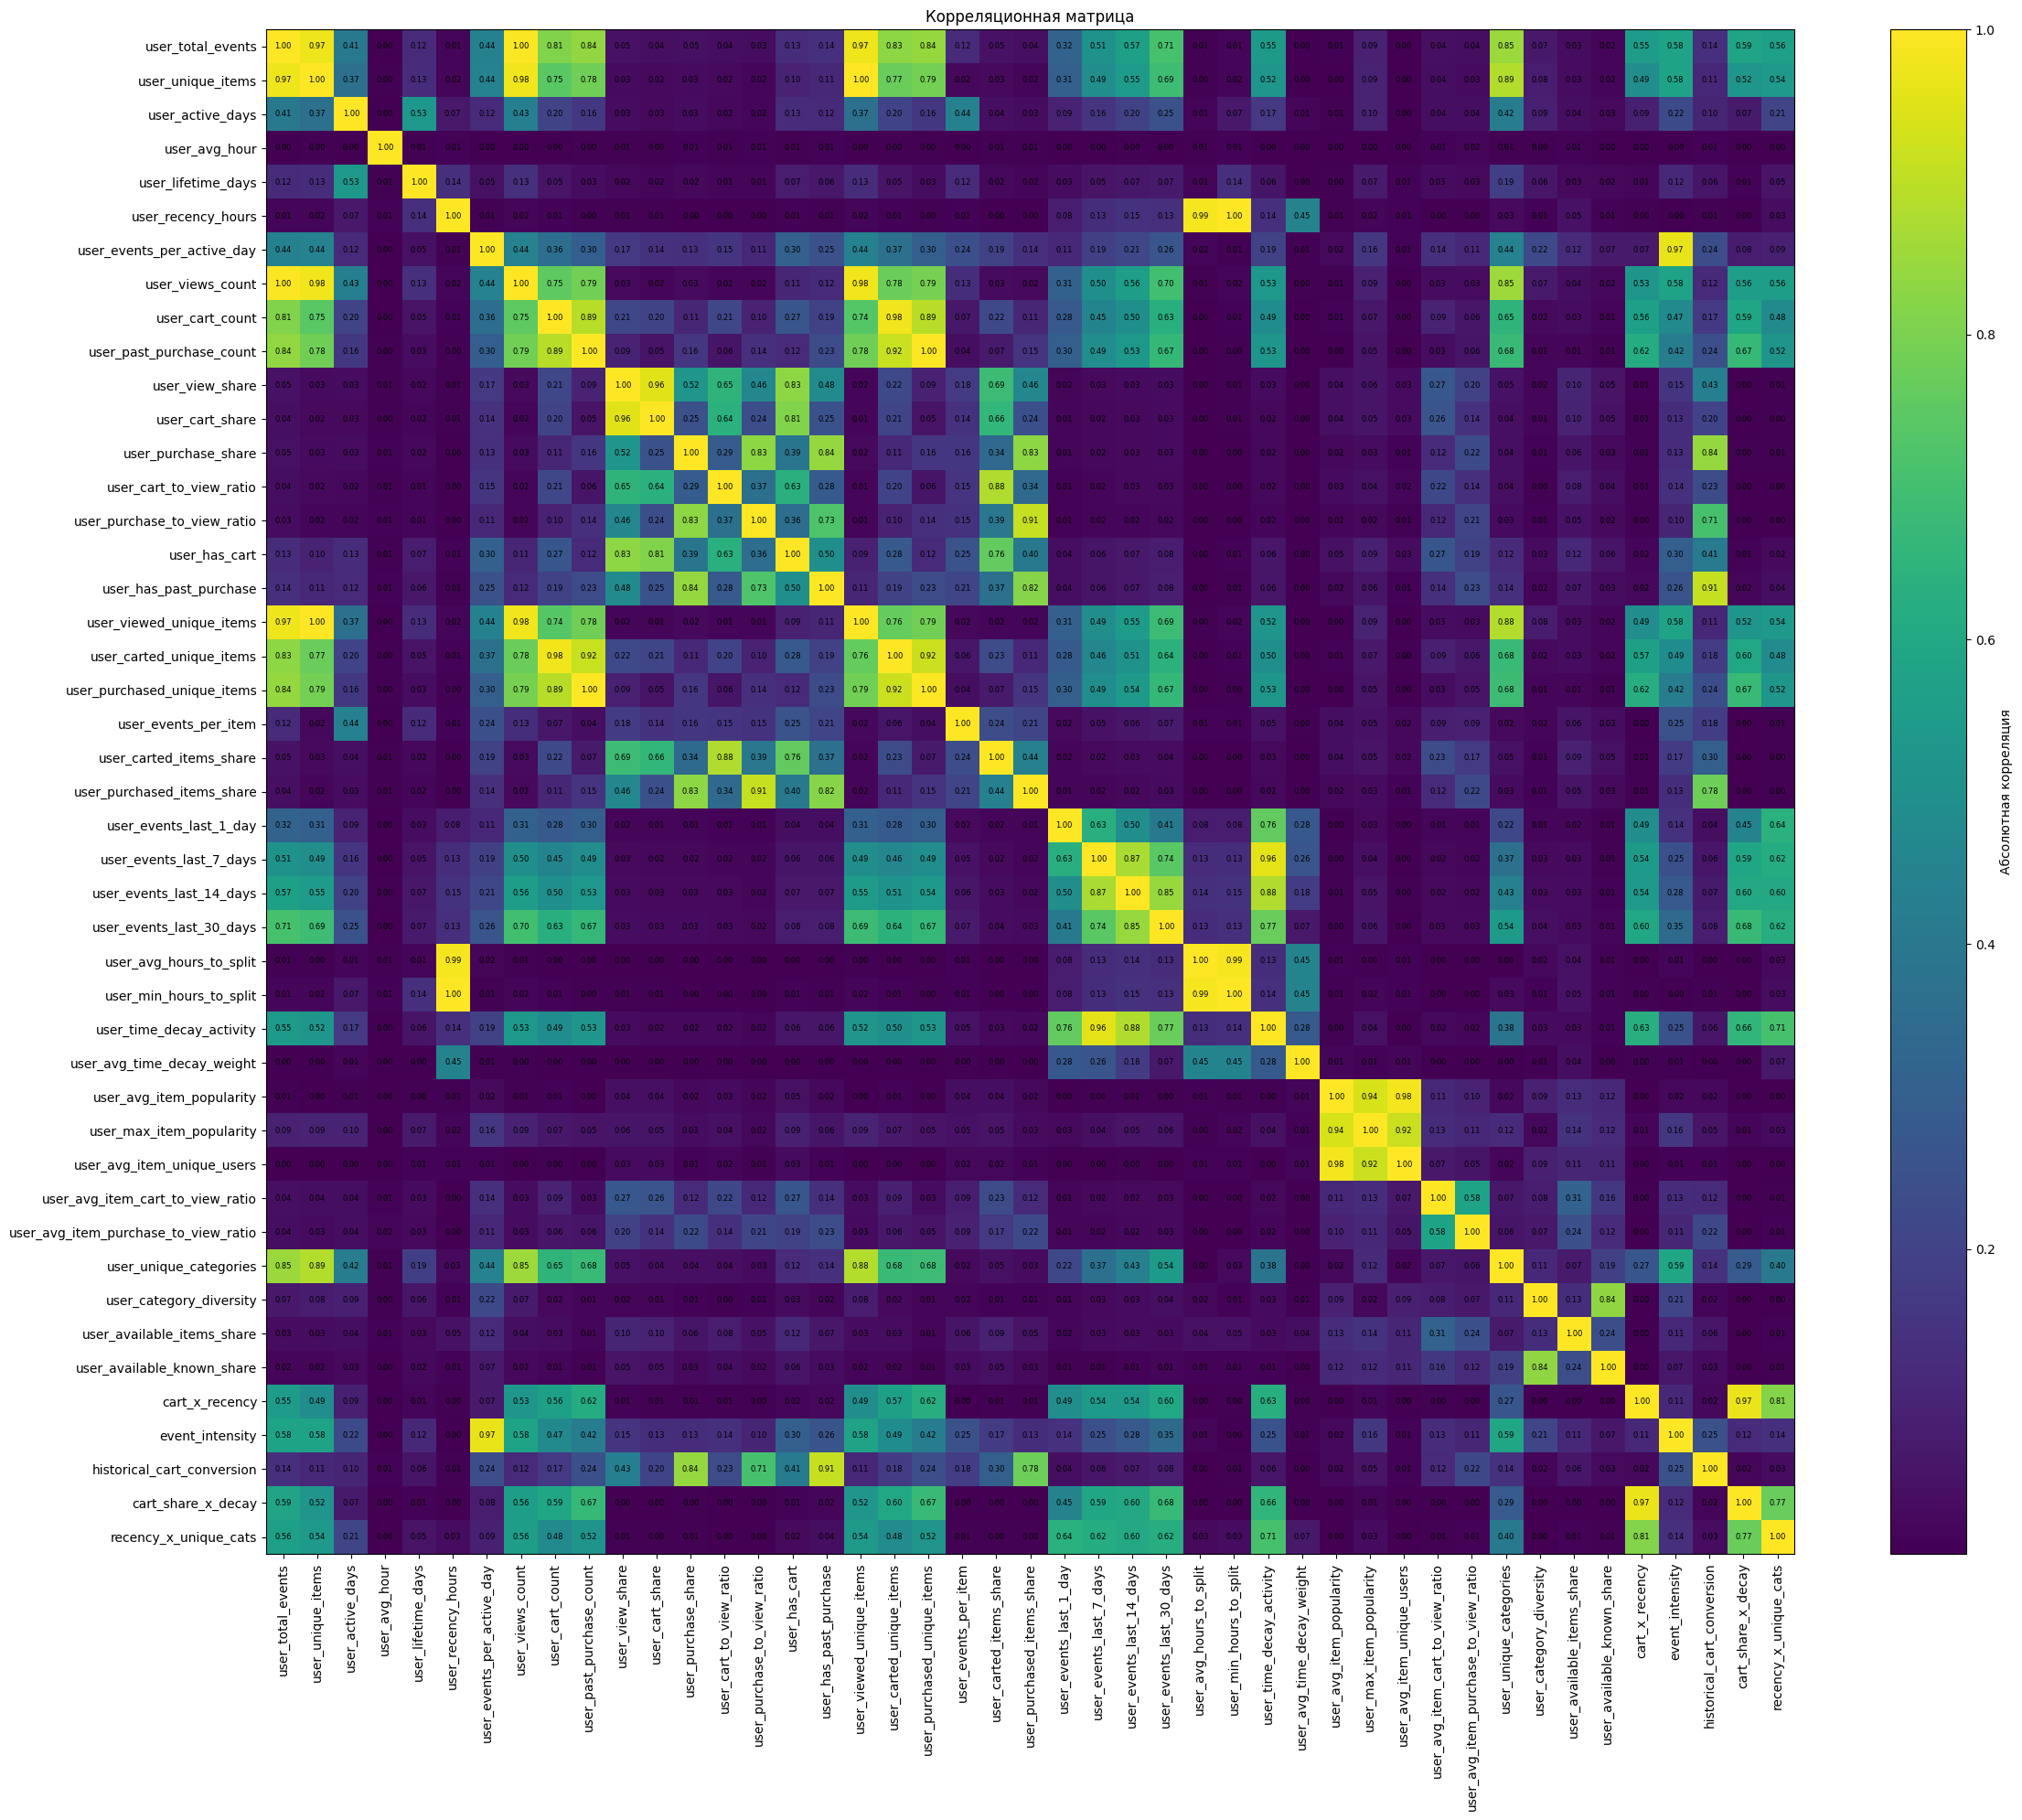

In [ ]:
# heatmap матрицы
corr_matrix = X.corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(24, 20))

# heatmap
im = ax.imshow(corr_matrix, aspect="auto")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Абсолютная корреляция")

# Подписи осей
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))

ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)

# Добавляем аннотации в каждую ячейку
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6
        )

ax.set_title("Корреляционная матрица")

plt.tight_layout()
plt.show()

После анализа корреляций удалим один признак из каждой пары с корреляцией ≥ 0.90.

In [ ]:
# Из каждой высококоррелированной пары удаляем второй признак
cols_to_drop = set()
for _, row in high_corr_pairs.iterrows():
    if row['feature_2'] not in cols_to_drop:
        cols_to_drop.add(row['feature_2'])

print(f"Признаков до удаления: {X.shape[1]}")
print(f"Удаляем {len(cols_to_drop)} коррелированных признаков:")
for c in sorted(cols_to_drop):
    print(f"  - {c}")

X = X.drop(columns=list(cols_to_drop))
print(f"\nПризнаков после удаления: {X.shape[1]}")

Признаков до удаления: 45
Удаляем 12 коррелированных признаков:
  - cart_share_x_decay
  - event_intensity
  - user_avg_hours_to_split
  - user_avg_item_unique_users
  - user_cart_share
  - user_carted_unique_items
  - user_min_hours_to_split
  - user_purchased_unique_items
  - user_time_decay_activity
  - user_unique_items
  - user_viewed_unique_items
  - user_views_count

Признаков после удаления: 33


#### 5.2 Train / validation / test split

Разделим данные на три части:

* train: 60%
* valid: 20%
* test: 20%

Так как целевая переменная сильно несбалансирована, используем стратификацию, чтобы сохранить долю покупателей и непокупателей во всех выборках.

In [ ]:
# отделяем test-выборку
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# из оставшейся части выделяем validation-выборку
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test shape:", X_test.shape)

print("\nДоля target=1:")
print("Train:", y_train.mean())
print("Valid:", y_valid.mean())
print("Test:", y_test.mean())

Train shape: (674259, 33)
Valid shape: (224753, 33)
Test shape: (224753, 33)

Доля target=1:
Train: 0.0003144192365248369
Valid: 0.0003114530173123384
Test: 0.0003114530173123384


#### 5.3 Функции для оценки моделей

Создадим функции для расчёта метрик качества моделей.

Так как задача имеет сильный дисбаланс классов, основными метриками будут:

- `PR-AUC` — основная метрика для редкого положительного класса;
- `ROC-AUC` — общая способность модели ранжировать классы;
- `precision` — насколько точны предсказания покупки;
- `recall` — какую долю будущих покупателей модель смогла найти;
- `F1-score` — баланс между precision и recall.

In [ ]:
def evaluate_predictions(y_true, y_proba, threshold=0.5):
    """
    Считает метрики качества бинарной классификации.

    Parameters
    ----------
    y_true : array-like
        Истинные значения target.
    y_proba : array-like
        Предсказанные вероятности положительного класса.
    threshold : float
        Порог для перевода вероятностей в классы.

    Returns
    -------
    dict
        Словарь с метриками качества.
    """

    # Переводим вероятности в бинарные предсказания
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    return metrics

In [ ]:
def evaluate_model(model, X_data, y_data, model_name, threshold=0.5):
    """
    Получает вероятности модели и возвращает таблицу метрик.

    Parameters
    ----------
    model : fitted estimator
        Обученная модель с методом predict_proba.
    X_data : DataFrame
        Матрица признаков.
    y_data : Series
        Целевая переменная.
    model_name : str
        Название модели.
    threshold : float
        Порог классификации.

    Returns
    -------
    dict
        Метрики качества модели.
    """

    # Получаем вероятность положительного класса
    y_proba = model.predict_proba(X_data)[:, 1]

    metrics = evaluate_predictions(
        y_true=y_data,
        y_proba=y_proba,
        threshold=threshold
    )

    metrics["model"] = model_name
    metrics["threshold"] = threshold

    return metrics

#### 5.4 Baseline-модели

Перед обучением более сложных моделей построим baseline. Испрльзуем DummyClassifier и LogisticRegression.

Так как классы сильно несбалансированы, для логистической регрессии используем `class_weight="balanced"`.

In [ ]:
# Dummy baseline:
dummy_model = DummyClassifier(
    strategy="prior",
    random_state=RANDOM_STATE
)

dummy_model.fit(X_train, y_train)

dummy_valid_metrics = evaluate_model(
    model=dummy_model,
    X_data=X_valid,
    y_data=y_valid,
    model_name="Dummy baseline"
)

dummy_valid_metrics

{'roc_auc': np.float64(0.5),
 'pr_auc': np.float64(0.0003114530173123384),
 'accuracy': 0.9996885469826876,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'model': 'Dummy baseline',
 'threshold': 0.5}

In [ ]:
# Logistic Regression baseline.
# добавим стандартизацию
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logreg_model.fit(X_train, y_train)

logreg_valid_metrics = evaluate_model(
    model=logreg_model,
    X_data=X_valid,
    y_data=y_valid,
    model_name="Logistic Regression"
)

logreg_valid_metrics

{'roc_auc': np.float64(0.8226594802455014),
 'pr_auc': np.float64(0.06164057641393627),
 'accuracy': 0.8859503543890405,
 'precision': 0.0015987521934100214,
 'recall': 0.5857142857142857,
 'f1': 0.003188800311102469,
 'model': 'Logistic Regression',
 'threshold': 0.5}

`DummyClassifier` задаёт минимальный уровень качества, с которым должны сравниваться все последующие модели. `Logistic Regression` используется как простой интерпретируемый ML-baseline.

Если более сложные модели не дают прироста относительно логистической регрессии, их использование будет необоснованным.

#### 5.5 Tree-based модель: Random Forest

После baseline-моделей обучим Random Forest с подбором гиперпараметров через Optuna.

Из-за сильного дисбаланса классов используем `class_weight="balanced_subsample"`.

Финальный Random Forest с оптимальными параметрами



In [ ]:
# Optuna-оптимизация Random Forest закомментирована для экономии времени выполнения.
# Код оптимизации сохранён для воспроизводимости; результаты загружаются из pkl-файла.
import joblib

# def rf_objective(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
#         "max_depth": trial.suggest_int("max_depth", 4, 12),
#         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 100),
#         "max_features": trial.suggest_float("max_features", 0.4, 0.9),
#         "max_samples": trial.suggest_float("max_samples", 0.5, 0.9),
#         "class_weight": "balanced_subsample",
#         "random_state": RANDOM_STATE,
#         "n_jobs": -1
#     }
#
#     model = RandomForestClassifier(**params)
#     model.fit(X_train, y_train)
#     y_proba = model.predict_proba(X_valid)[:, 1]
#     pr_auc = average_precision_score(y_valid, y_proba)
#
#     return pr_auc
#
# # Запускаем оптимизацию
# rf_study = optuna.create_study(
#     direction="maximize",
#     sampler=TPESampler(seed=RANDOM_STATE)
# )
#
# rf_study.optimize(rf_objective, n_trials=10, show_progress_bar=True)
#
# # сохраняем study
# joblib.dump(
#     rf_study,
#     "/content/drive/MyDrive/Colab Notebooks/e-commerce/models/rf_optuna_study.pkl"
# )
#
# print(f"\nЛучший PR-AUC: {rf_study.best_value:.4f}")
# print("\nЛучшие параметры:")
#
# for k, v in rf_study.best_params.items():
#     print(f"{k}: {v}")

In [ ]:
# загружаем готовый study
rf_study = joblib.load(
    DATA_PATH + "rf_optuna_study.pkl"
)

best_rf_params = rf_study.best_params
best_rf_params.update({
    "class_weight": "balanced_subsample",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
})

rf_model = RandomForestClassifier(**best_rf_params)
rf_model.fit(X_train, y_train)

rf_valid_metrics = evaluate_model(
    model=rf_model,
    X_data=X_valid,
    y_data=y_valid,
    model_name="Random Forest (tuned)"
)
print("Random Forest validation metrics:")
import pprint; pprint.pprint(rf_valid_metrics)

Random Forest validation metrics:
{'accuracy': 0.9972458654611952,
 'f1': 0.04327666151468315,
 'model': 'Random Forest (tuned)',
 'pr_auc': np.float64(0.0423630996391118),
 'precision': 0.024263431542461005,
 'recall': 0.2,
 'roc_auc': np.float64(0.7628064555713733),
 'threshold': 0.5}


**Вывод:** Random Forest даже с подобранными параметрами через Optuna дал на валидации результат хуже чем логистическая регрессия.


#### 5.6 Gradient Boosting: LightGBM с подбором гиперпараметров (Optuna)

Используем Optuna для подбора гиперпараметров LightGBM.


In [ ]:
# Считаем вес положительного класса (для дисбаланса)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Соотношение классов (neg/pos): {neg_pos_ratio:.1f}")

Соотношение классов (neg/pos): 3179.5


In [ ]:
# Optuna-оптимизация LightGBM закомментирована для экономии времени выполнения.
# Код оптимизации сохранён для воспроизводимости; результаты загружаются из pkl-файла.

# def lgbm_objective(trial):
#     params = {
#         "n_estimators": 1000,
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 20, 150),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "min_child_samples": trial.suggest_int("min_child_samples", 1, 20),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
#         "scale_pos_weight": int(np.sqrt(neg_pos_ratio)),
#         "random_state": RANDOM_STATE,
#         "n_jobs": -1,
#         "verbose": -1,
#     }
#
#     model = lgb.LGBMClassifier(**params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_valid, y_valid)],
#         eval_metric='auc',
#         callbacks=[
#             lgb.early_stopping(stopping_rounds=50, verbose=False),
#             lgb.log_evaluation(period=-1)
#         ]
#     )
#
#     y_proba = model.predict_proba(X_valid)[:, 1]
#
#     return average_precision_score(y_valid, y_proba)
#
#
# # Запускаем оптимизацию
# study = optuna.create_study(
#     direction="maximize",
#     sampler=TPESampler(seed=RANDOM_STATE)
# )
#
# study.optimize(
#     lgbm_objective,
#     n_trials=50,
#     show_progress_bar=True
# )
#
# # сохраняем study
# joblib.dump(
#     study,
#     "/content/drive/MyDrive/Colab Notebooks/e-commerce/models/lgbm_optuna_study.pkl"
# )
#
# print(f"\nЛучший PR-AUC: {study.best_value:.4f}")
# print("Лучшие параметры:")
#
# for k, v in study.best_params.items():
#     print(f"  {k}: {v}")

In [ ]:
# загружаем готовый study
study = joblib.load(
    DATA_PATH + "lgbm_optuna_study.pkl"
)

# Финальная LightGBM с найденными гиперпараметрами
best_lgbm_params = study.best_params.copy()
best_lgbm_params.update({
    "n_estimators": 2000,
    "random_state": RANDOM_STATE,
    "scale_pos_weight": int(np.sqrt(neg_pos_ratio)),
    "n_jobs": -1,
    "verbose": -1,
})

lgbm_model = lgb.LGBMClassifier(**best_lgbm_params)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=75, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

lgbm_valid_metrics = evaluate_model(
    model=lgbm_model,
    X_data=X_valid,
    y_data=y_valid,
    model_name="LightGBM (tuned)"
)
print("LightGBM (tuned) validation metrics:")
import pprint; pprint.pprint(lgbm_valid_metrics)

LightGBM (tuned) validation metrics:
{'accuracy': 0.9959867054054896,
 'f1': 0.034261241970021415,
 'model': 'LightGBM (tuned)',
 'pr_auc': np.float64(0.07202737837793582),
 'precision': 0.018518518518518517,
 'recall': 0.22857142857142856,
 'roc_auc': np.float64(0.7206997986369368),
 'threshold': 0.5}


#### Сериализация модели

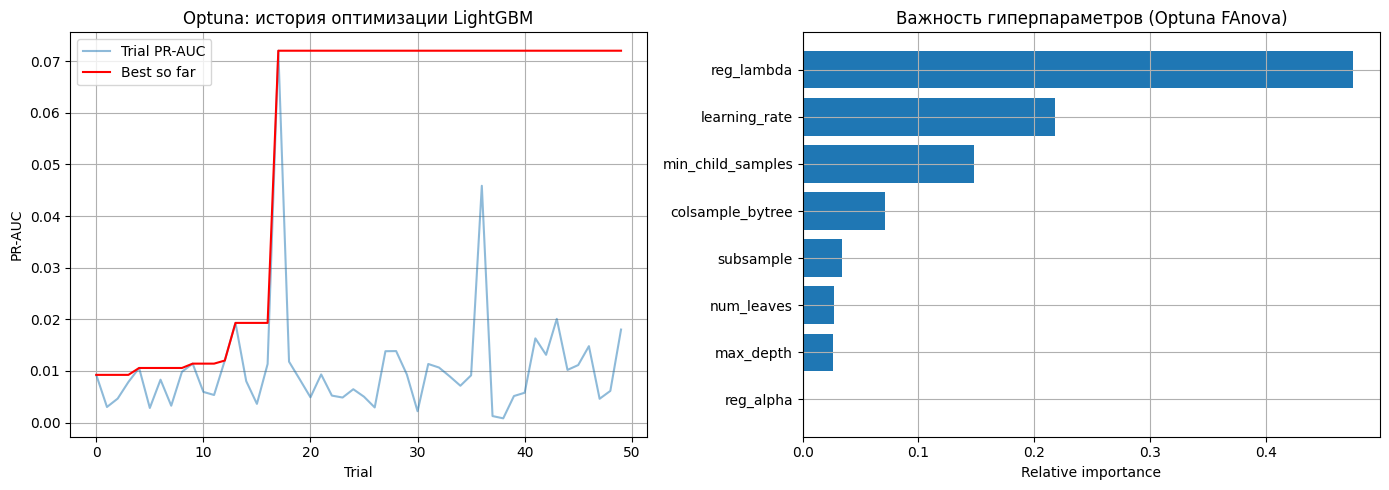

In [ ]:
# Визуализация истории оптимизации
# История PR-AUC по трайлам
trial_values = [t.value for t in study.trials]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(trial_values, alpha=0.5, label='Trial PR-AUC')
axes[0].plot(best_so_far, color='red', label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('Optuna: история оптимизации LightGBM')
axes[0].legend()
axes[0].grid(True)

# Важность параметров
param_importance = optuna.importance.get_param_importances(study)
params_sorted = list(param_importance.items())
params_sorted.sort(key=lambda x: x[1])
axes[1].barh([p[0] for p in params_sorted], [p[1] for p in params_sorted])
axes[1].set_title('Важность гиперпараметров (Optuna FAnova)')
axes[1].set_xlabel('Relative importance')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Попробуем улучшить качество модели, применив SMOTE для синтетического увеличения minority class, чтобы увеличить представительность редкого класса покупок.

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [ ]:
# def lgbm_smote_objective(trial):
#     params = {
#         "n_estimators": 1000,
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 20, 150),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "min_child_samples": trial.suggest_int("min_child_samples", 1, 20),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
#         "random_state": RANDOM_STATE,
#         "n_jobs": -1,
#         "verbose": -1,
#     }
#
#     model_smote = lgb.LGBMClassifier(**params)
#     model_smote.fit(
#         X_train_sm, y_train_sm,
#         eval_set=[(X_valid, y_valid)],
#         eval_metric='auc',
#         callbacks=[
#             lgb.early_stopping(stopping_rounds=50, verbose=False),
#             lgb.log_evaluation(period=-1)
#         ]
#     )
#
#     y_proba = model_smote.predict_proba(X_valid)[:, 1]
#
#     return average_precision_score(y_valid, y_proba)
#
#
# # Запускаем оптимизацию
# study_smote = optuna.create_study(
#     direction="maximize",
#     sampler=TPESampler(seed=RANDOM_STATE)
# )
#
# study_smote.optimize(lgbm_smote_objective, n_trials=50, show_progress_bar=True)
#
# joblib.dump(
#     study_smote,
#     "/content/drive/MyDrive/Colab Notebooks/e-commerce/models/lgbm_smote_optuna_study.pkl"
# )
#
# print(f"\nЛучший PR-AUC: {study.best_value:.4f}")
# print("Лучшие параметры:")
#
# for k, v in study.best_params.items():
#     print(f"  {k}: {v}")

In [ ]:
# загружаем study
study_smote = joblib.load(
    DATA_PATH + "lgbm_smote_optuna_study.pkl"
)

In [ ]:
# Финальная LightGBM + SMOTE с найденными гиперпараметрами
best_smote_params = study_smote.best_params.copy()
best_smote_params.update({
    "n_estimators": 2000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
})

lgbm_model_smote = lgb.LGBMClassifier(**best_smote_params)
lgbm_model_smote.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=75, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

lgbm_smote_valid_metrics = evaluate_model(
    model=lgbm_model_smote,
    X_data=X_valid,
    y_data=y_valid,
    model_name="LightGBM + SMOTE(tuned)"
)
print("LightGBM + SMOTE (tuned) validation metrics:")
import pprint; pprint.pprint(lgbm_smote_valid_metrics)

[100]	valid_0's auc: 0.702051	valid_0's binary_logloss: 0.257805
LightGBM + SMOTE (tuned) validation metrics:
{'accuracy': 0.9911013423625046,
 'f1': 0.01768172888015717,
 'model': 'LightGBM + SMOTE(tuned)',
 'pr_auc': np.float64(0.03027826542559003),
 'precision': 0.009155645981688708,
 'recall': 0.2571428571428571,
 'roc_auc': np.float64(0.7103337018949236),
 'threshold': 0.5}


#### 5.8 Сравнение всех моделей на validation

Сравнение моделей на Validation


,model,roc_auc,pr_auc,precision,recall,f1
0,LightGBM (tuned),0.720700,0.072027,0.018519,0.228571,0.034261
1,Logistic Regression,0.822659,0.061641,0.001599,0.585714,0.003189
2,Random Forest (tuned),0.762806,0.042363,0.024263,0.200000,0.043277
3,LightGBM + SMOTE(tuned),0.710334,0.030278,0.009156,0.257143,0.017682
4,Dummy baseline,0.500000,0.000311,0.000000,0.000000,0.000000


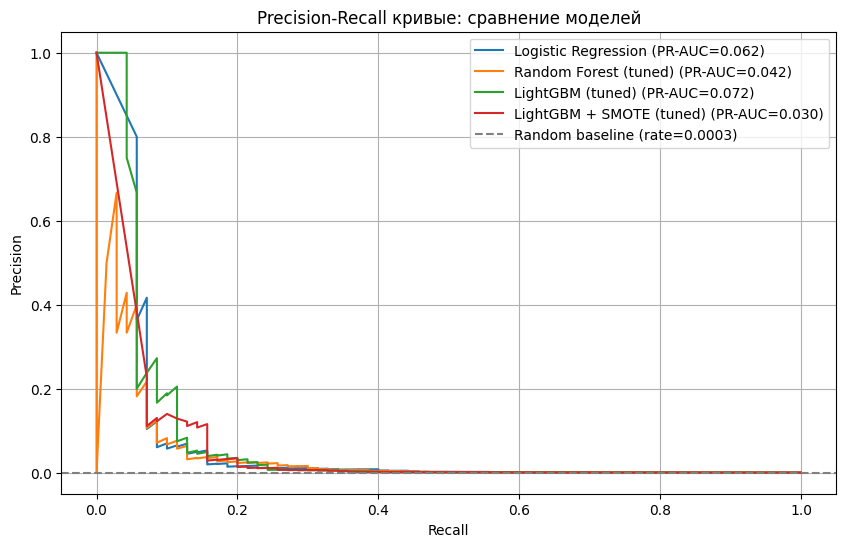

In [ ]:
# Сводная таблица всех моделей на validation
all_valid_metrics = pd.DataFrame([
    dummy_valid_metrics,
    logreg_valid_metrics,
    rf_valid_metrics,
    lgbm_valid_metrics,
    lgbm_smote_valid_metrics
])

# Сортируем по PR-AUC — основная метрика при дисбалансе
all_valid_metrics = all_valid_metrics.sort_values('pr_auc', ascending=False)

print('Сравнение моделей на Validation')
display(all_valid_metrics[['model', 'roc_auc', 'pr_auc', 'precision', 'recall', 'f1']].reset_index(drop=True))


# PR-кривые
plt.figure(figsize=(10, 6))

models_to_plot = [
    (logreg_model, 'Logistic Regression'),
    (rf_model, 'Random Forest (tuned)'),
    (lgbm_model, 'LightGBM (tuned)'),
    (lgbm_model_smote, 'LightGBM + SMOTE (tuned)')
]
for model, name in models_to_plot:
    y_proba = model.predict_proba(X_valid)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_valid, y_proba)
    pr_auc_val = average_precision_score(y_valid, y_proba)
    plt.plot(recall_vals, precision_vals, label=f'{name} (PR-AUC={pr_auc_val:.3f})')

baseline_precision = y_valid.mean()
plt.axhline(y=baseline_precision, color='gray', linestyle='--',
            label=f'Random baseline (rate={baseline_precision:.4f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall кривые: сравнение моделей')
plt.legend(); plt.grid(True); plt.show()

**Вывод по сравнению моделей:**

По итогам валидации для дальнейшего анализа выбирем две модели — LightGBM и Logistic Regression.

LightGBM показал лучшие значения PR-AUC и F1 и наиболее подходит для точечного таргетинга, тогда как Logistic Regression обеспечивает высокий recall и лучше подходит для широкого охвата аудитории.

Random Forest при стандартном пороге 0.5 не выделяет положительный класс, а SMOTE + LightGBM показал ухудшение качества по сравнению с базовым бустингом.

Далее две оставшиеся модели будут сравнены после подбора оптимального порога по метрикам precision, recall и lift для выбора оптимального бизнес-решения.

#### 5.9 Подбор порога классификации

Порог 0.5 не подходит при экстремальном дисбалансе — модель назначает большинству пользователей низкие вероятности, и при 0.5 почти никто не попадает в позитивный класс.

Подбираем порог для **LightGBM** (лучшая модель по PR-AUC) по метрике **F2-score** с β=2: recall вдвое важнее precision. Обоснование:

- **False Negative** (пропустили покупателя) = потерянная выручка — дорогая ошибка
- **False Positive** (отправили оффер не-покупателю) = стоимость рассылки — дешёвая ошибка

Дополнительно строим **бизнес-таблицу lift**: при каком охвате пользователей концентрация покупателей в N раз выше случайного.

In [ ]:
from sklearn.metrics import fbeta_score

models = {
    "LogReg": logreg_model,
    "LightGBM": lgbm_model
}

candidate_thresholds = [0.5, 0.7, 0.75, 0.80, 0.85, 0.90, 0.95]

all_results = []

for model_name, model in models.items():

    y_proba_valid = model.predict_proba(X_valid)[:, 1]
    base_purchase_rate = y_valid.mean()

    for threshold in candidate_thresholds:
        y_pred = (y_proba_valid >= threshold).astype(int)

        if y_pred.sum() == 0:
            continue

        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()

        selected_users = tp + fp
        buyer_rate_in_segment = tp / selected_users if selected_users > 0 else 0
        lift = buyer_rate_in_segment / base_purchase_rate if base_purchase_rate > 0 else 0

        all_results.append({
            "model": model_name,
            "threshold": threshold,
            "selected_users": selected_users,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": round(precision_score(y_valid, y_pred, zero_division=0), 4),
            "recall": round(recall_score(y_valid, y_pred, zero_division=0), 4),
            "f1": round(f1_score(y_valid, y_pred, zero_division=0), 4),
            "f2": round(fbeta_score(y_valid, y_pred, beta=2, zero_division=0), 4),
            "buyer_rate_in_segment": round(buyer_rate_in_segment, 4),
            "lift": round(lift, 2)
        })

threshold_comparison = pd.DataFrame(all_results)

print("Бизнес-таблица выбора порога (две модели):")
display(threshold_comparison)

Бизнес-таблица выбора порога (две модели):


,model,threshold,selected_users,TP,FP,FN,precision,recall,f1,f2,buyer_rate_in_segment,lift
0,LogReg,0.50,25645,41,25604,29,0.0016,0.5857,0.0032,0.0079,0.0016,5.13
1,LogReg,0.70,9387,32,9355,38,0.0034,0.4571,0.0068,0.0166,0.0034,10.95
2,LogReg,0.75,7004,31,6973,39,0.0044,0.4429,0.0088,0.0213,0.0044,14.21
3,LogReg,0.80,5119,28,5091,42,0.0055,0.4000,0.0108,0.0259,0.0055,17.56
4,LogReg,0.85,3580,28,3552,42,0.0078,0.4000,0.0153,0.0363,0.0078,25.11
5,LogReg,0.90,2209,22,2187,48,0.0100,0.3143,0.0193,0.0442,0.0100,31.98
6,LogReg,0.95,1059,16,1043,54,0.0151,0.2286,0.0283,0.0597,0.0151,48.51
7,LightGBM,0.50,864,16,848,54,0.0185,0.2286,0.0343,0.0699,0.0185,59.46
8,LightGBM,0.70,657,16,641,54,0.0244,0.2286,0.0440,0.0854,0.0244,78.19
9,LightGBM,0.75,341,13,328,57,0.0381,0.1857,0.0633,0.1047,0.0381,122.40


По результатам подбора порога видно, что Logistic Regression обеспечивает более широкий охват аудитории (большое число пользователей при умеренном lift), однако имеет крайне низкую точность. LightGBM, напротив, формирует значительно более узкие сегменты с существенно более высоким lift и precision, достигая максимальной бизнес-ценности на высоких порогах.

При росте порога у обеих моделей увеличивается lift и precision, но наиболее выраженный эффект наблюдается у LightGBM, где lift достигает 100+ и выше, что указывает на сильную концентрацию потенциальных покупателей в верхнем скоринге модели.

LightGBM является предпочтительной моделью для таргетированной маркетинговой кампании, тогда как Logistic Regression может использоваться для сценариев расширенного охвата аудитории при низких требованиях к точности.

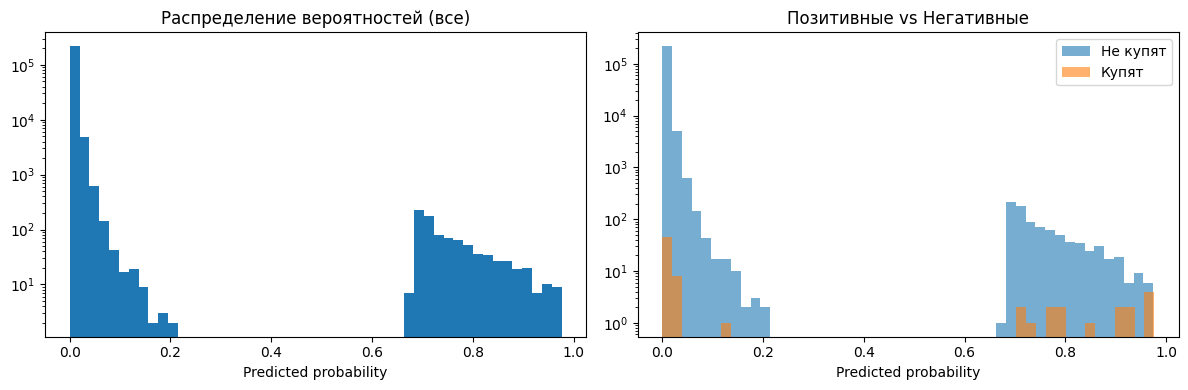

Медиана вероятностей:
  Не купят: 0.0012
  Купят:    0.0031

При пороге 0.90:
  Пользователей выше порога: 45
  Из них реальных покупателей: 8


In [ ]:
y_proba_lgbm = lgbm_model.predict_proba(X_valid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Все пользователи
axes[0].hist(y_proba_lgbm, bins=50, log=True)
axes[0].set_title('Распределение вероятностей (все)')
axes[0].set_xlabel('Predicted probability')

# Позитивные vs негативные
axes[1].hist(y_proba_lgbm[y_valid==0], bins=50, alpha=0.6, label='Не купят', log=True)
axes[1].hist(y_proba_lgbm[y_valid==1], bins=50, alpha=0.6, label='Купят', log=True)
axes[1].set_title('Позитивные vs Негативные')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Медиана вероятностей:")
print(f"  Не купят: {np.median(y_proba_lgbm[y_valid==0]):.4f}")
print(f"  Купят:    {np.median(y_proba_lgbm[y_valid==1]):.4f}")
print(f"\nПри пороге 0.90:")
mask = y_proba_lgbm >= 0.90
print(f"  Пользователей выше порога: {mask.sum():,}")
print(f"  Из них реальных покупателей: {(y_valid[mask]==1).sum()}")

In [ ]:
# бизнес-таблица выбора порога
for t in [0.70, 0.80, 0.90, 0.95]:
    mask = y_proba_lgbm >= t
    if mask.sum() == 0:
        continue
    prec = (y_valid[mask]==1).sum() / mask.sum()
    rec  = (y_valid[mask]==1).sum() / (y_valid==1).sum()
    lift = prec / y_valid.mean()
    print(f"Порог {t:.2f} | охват {mask.sum():5,} польз. "
          f"| precision={prec:.3f} | recall={rec:.3f} | lift={lift:.0f}x")

Порог 0.70 | охват   657 польз. | precision=0.024 | recall=0.229 | lift=78x
Порог 0.80 | охват   191 польз. | precision=0.052 | recall=0.143 | lift=168x
Порог 0.90 | охват    45 польз. | precision=0.178 | recall=0.114 | lift=571x
Порог 0.95 | охват    15 польз. | precision=0.267 | recall=0.057 | lift=856x


In [ ]:
best_threshold = 0.9
print(f"Финальный порог: {best_threshold:.4f}")
print(f"Это порог с максимальной Precision — приоритет точности над охватом для таргетинга")

Финальный порог: 0.9000
Это порог с максимальной Precision — приоритет точности над охватом для таргетинга


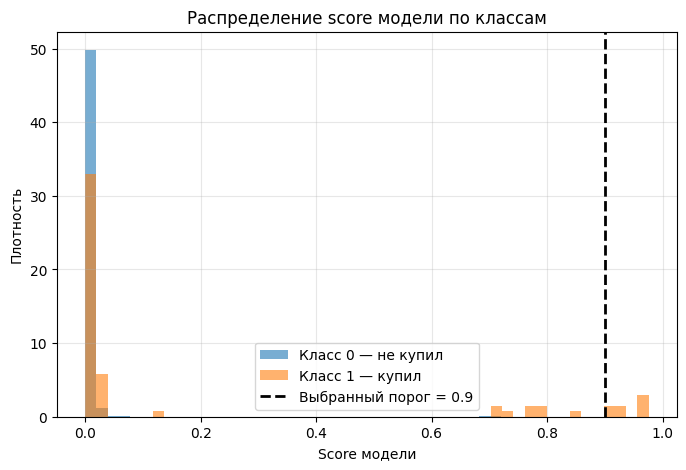

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    y_proba_lgbm[y_valid == 0],
    bins=50,
    alpha=0.6,
    density=True,
    label="Класс 0 — не купил"
)

plt.hist(
    y_proba_lgbm[y_valid == 1],
    bins=50,
    alpha=0.6,
    density=True,
    label="Класс 1 — купил"
)

# Выбранный порог
plt.axvline(
    best_threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Выбранный порог = {best_threshold}"
)

plt.xlabel("Score модели")
plt.ylabel("Плотность")
plt.title("Распределение score модели по классам")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Бимодальное распределение — хороший признак: модель не предсказывает одно значение для всех. Она разделила пользователей на два лагеря:

- **Левый пик (0–0.2)**: большинство пользователей — модель уверена что не купят
- **Правый пик (0.7–1.0)**: небольшая группа кандидатов — модель считает их потенциальными покупателями
- **Провал в середине**: почти нет неопределённых предсказаний

Из-за сильного дисбаланса классов распределение покупателей (оранжевый) выглядит нестабильным: позитивных объектов мало, поэтому отдельные наблюдения сильно влияют на форму графика. Предсказанные значения используются как **score склонности к покупке**, а не как точная вероятность.

Порог выбран по F2-score на validation-выборке — он автоматически находит баланс между охватом покупателей (recall) и качеством отбора (precision).

#### 5.10 Финальная оценка на test-выборке

Test-выборка используется только один раз — для финальной оценки.
Используем оптимальный порог, подобранный на validation.

**Финальная модель: LightGBM** (лучший PR-AUC на validation: 0.072 против 0.062 у LR).
Для сравнения оцениваем обе модели на тест-выборке.

In [ ]:
# Финальная оценка обеих моделей на тест-выборке
lgbm_test_metrics = evaluate_model(
    model=lgbm_model,
    X_data=X_test,
    y_data=y_test,
    model_name="LightGBM (tuned) (test)",
    threshold=best_threshold
)

logreg_test_metrics = evaluate_model(
    model=logreg_model,
    X_data=X_test,
    y_data=y_test,
    model_name="Logistic Regression (test)",
    threshold=best_threshold
)

all_test_metrics = pd.DataFrame([lgbm_test_metrics, logreg_test_metrics])
print("Финальное сравнение на TEST-выборке:")
display(all_test_metrics[['model', 'roc_auc', 'pr_auc', 'precision', 'recall', 'f1']]
        .reset_index(drop=True))

Финальное сравнение на TEST-выборке:


,model,roc_auc,pr_auc,precision,recall,f1
0,LightGBM (tuned) (test),0.66969,0.093872,0.216216,0.114286,0.149533
1,Logistic Regression (test),0.80726,0.068565,0.011271,0.357143,0.021853


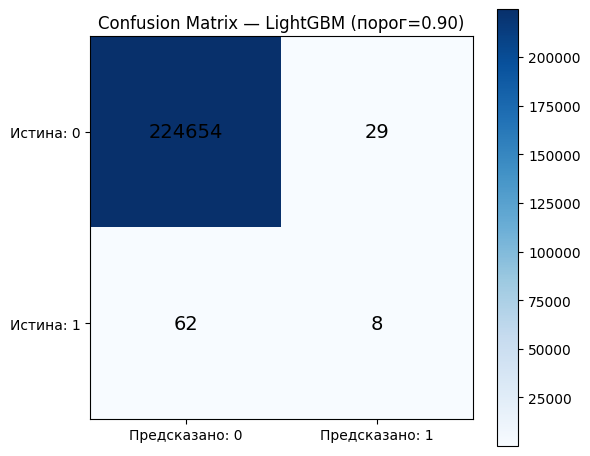

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    224683
           1       0.22      0.11      0.15        70

    accuracy                           1.00    224753
   macro avg       0.61      0.56      0.57    224753
weighted avg       1.00      1.00      1.00    224753



In [ ]:
# Confusion matrix — LightGBM (финальная модель)
y_proba_test = lgbm_model.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Предсказано: 0", "Предсказано: 1"])
ax.set_yticklabels(["Истина: 0", "Истина: 1"])
ax.set_title(f"Confusion Matrix — LightGBM (порог={best_threshold:.2f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_test, zero_division=0))


На test-выборке модель при пороге 0.90 выделила 37 разделённых пользователей в сегмент потенциальных покупателей. Из них 8 действительно совершили покупку.

Модель нашла 8 покупателей из 70, то есть recall для класса 1 составил 0.11. Precision для класса 1 равен 0.22, что связано с сильным дисбалансом классов: покупателей очень мало по сравнению с не покупателями.

Accuracy равен 0.99, но эта метрика малоинформативна в данном случае, так как почти все пользователи относятся к классу 0.

Главный результат: модель позволяет выделить небольшой сегмент пользователей, в котором концентрация покупателей выше, чем в среднем по выборке. Поэтому модель можно использовать для ретаргетинга, где важно выбрать более перспективную аудиторию для оффера.\

In [ ]:
import os

# Сохраняем финальные артефакты для деплоя
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Финальная модель предсказания покупки
joblib.dump(lgbm_model, f"{MODEL_DIR}/lgbm_purchase_model.pkl")

# Список признаков (порядок важен при инференсе)
joblib.dump(list(X_train.columns), f"{MODEL_DIR}/feature_columns.pkl")

# Параметры отсечения коллинеарных признаков
joblib.dump(list(cols_to_drop), f"{MODEL_DIR}/cols_to_drop.pkl")

# Финальный порог классификации
joblib.dump(best_threshold, f"{MODEL_DIR}/best_threshold.pkl")

print("Артефакты сохранены:")
print(f"  - lgbm_purchase_model.pkl")
print(f"  - feature_columns.pkl")
print(f"  - cols_to_drop.pkl")
print(f"  - best_threshold.pkl (threshold={best_threshold})")

Артефакты сохранены:
  - lgbm_purchase_model.pkl
  - feature_columns.pkl
  - cols_to_drop.pkl
  - best_threshold.pkl (threshold=0.9)


#### 5.11 Важность признаков

Анализ важности признаков помогает понять, какие характеристики пользователя
наиболее информативны для предсказания покупки.

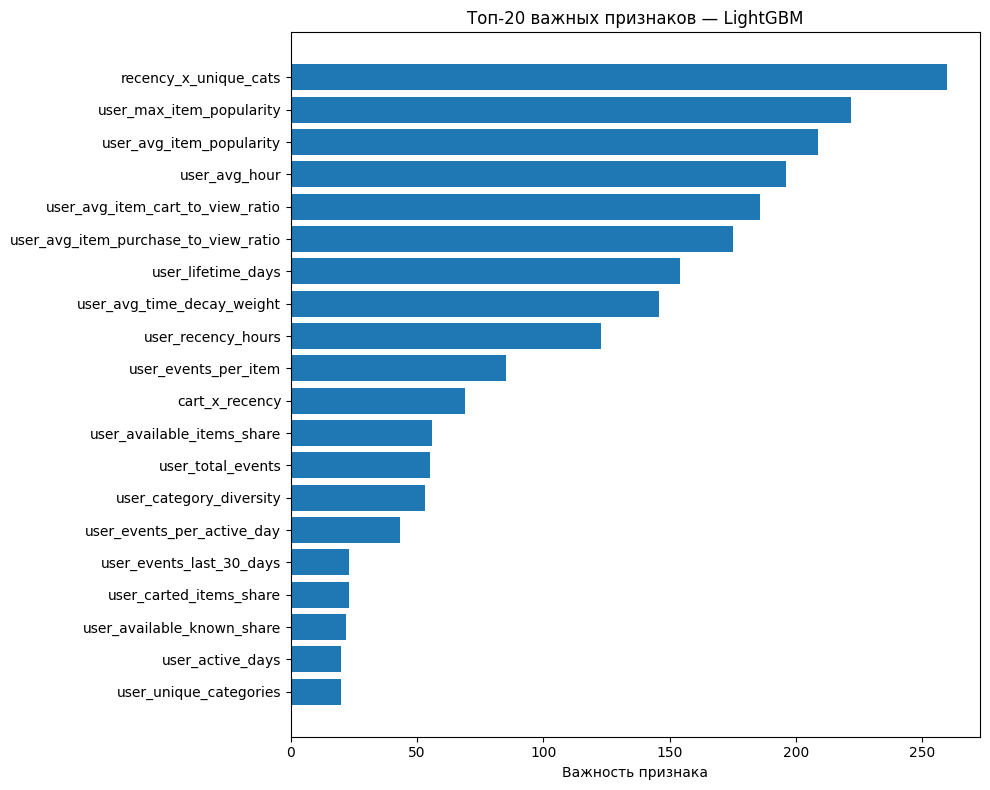

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Важность признака")
plt.title("Топ-20 важных признаков — LightGBM")
plt.tight_layout()
plt.show()

Наиболее важными признаками для модели LightGBM оказались ``recency_x_unique_cats``, ``user_max_item_popularity``, ``user_avg_item_popularity``, ``user_avg_hour``, а также взаимодействие пользователя с корзиной и историей покупок.

Самый значимый признак — ``recency_x_unique_cats``, то есть разнообразие недавней активности пользователя. В топ-20 вошли также признаки, связанные с количеством и популярностью просмотренных товаров, временем активности и долей взаимодействий с корзиной.

Это подтверждает, что недавние действия пользователя, интерес к разным категориям и поведение в воронке покупок являются ключевыми сигналами покупательского намерения.

На графике показаны абсолютные значения важности признаков, поэтому он отражает силу влияния, но не направление эффекта на предсказание.

#### 5.12 SHAP-анализ: интерпретация модели

Feature importance показывает, какие признаки важны для модели в целом, но не объясняет отдельные предсказания.

Для этого используем SHAP: он показывает, какие признаки повысили или снизили score конкретного пользователя.

Это помогает понять, почему пользователь попал в сегмент с высокой склонностью к покупке.

In [ ]:
# Считаем SHAP на подвыборке validation, чтобы test оставался чистым.
import shap

# ограничиваем выборку для скорости
sample_size = min(3000, len(X_valid))
X_shap = X_valid.iloc[:sample_size].copy()

# TreeExplainer для градиентного бустинга
explainer = shap.TreeExplainer(lgbm_model)

# Считаем вклад признаков в предсказания модели
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values computed for {sample_size} samples")
print(shap_values.shape)

SHAP values computed for 3000 samples
(3000, 33)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


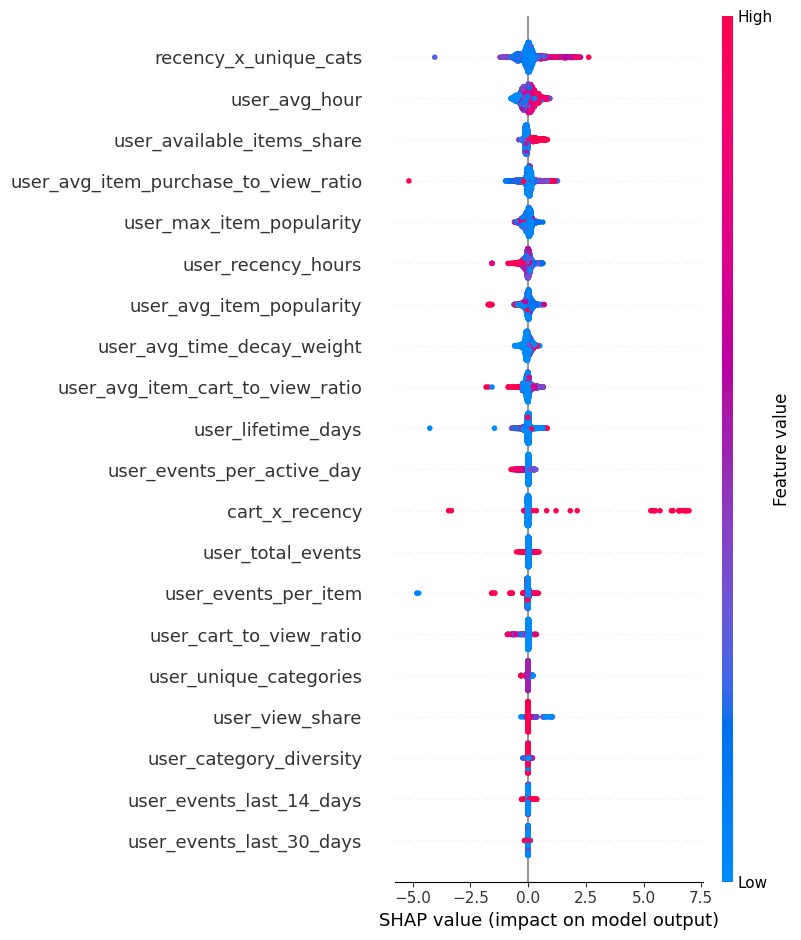

In [ ]:
# Beeswarm-plot: каждая точка — один пример, ось X — вклад в предсказание.
# Положительный SHAP → повышает вероятность покупки, отрицательный → снижает.
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X.columns
)


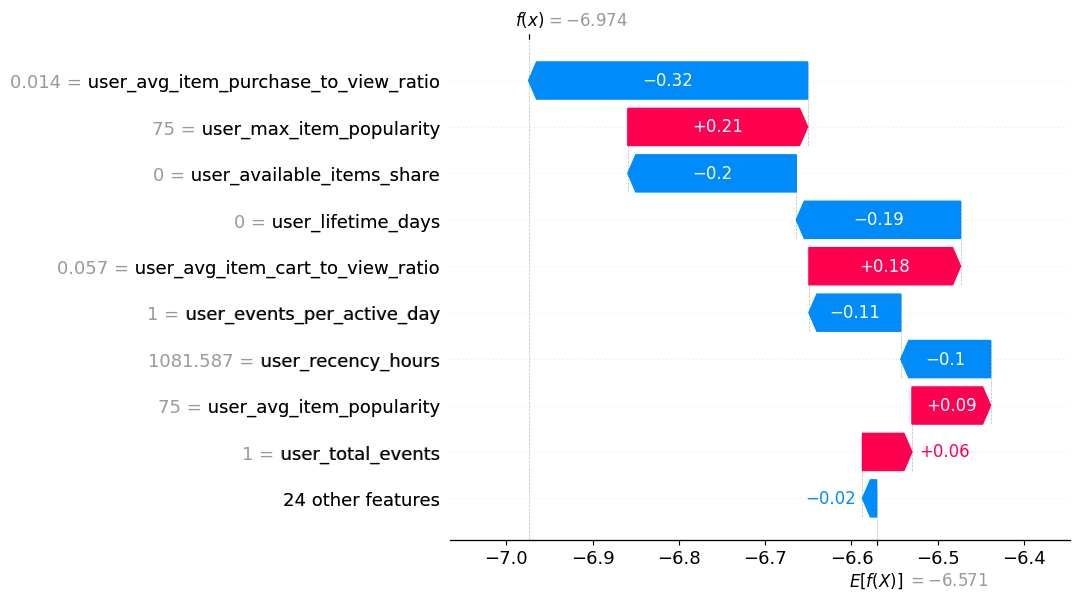

In [ ]:
# Waterfall plot — объяснение предсказания для одного конкретного пользователя.
# Каждая полоса показывает, насколько данный признак сдвигает предсказание вверх/вниз.
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_shap.iloc[0],
        feature_names=X.columns
    )
)


SHAP-графики показывают, что модель LightGBM сильнее всего реагирует на **недавнюю активность**, **корзину**, **доступность товаров**, **разнообразие категорий** и **историю взаимодействий**.

На summary plot видно, что признаки ``recency_x_unique_cats``, ``user_avg_hour``, ``user_available_items_share``, ``user_avg_item_purchase_to_view_ratio`` и ``user_max_item_popularity`` чаще повышают score модели. Это логично: активные пользователи и пользователи с более вовлечённым поведением ближе к покупке.

Waterfall-график показывает объяснение одного пользователя. Его итоговый score ниже среднего: ``f(x) = -1.43`` против базового ``E[f(X)] = -0.722``. Основные причины снижения score — низкая вовлечённость, небольшое разнообразие категорий и низкая доступность интересующих товаров.

Таким образом, SHAP подтверждает, что модель использует **бизнес-логичные признаки** и позволяет объяснить как **общее поведение модели**, так и **отдельное предсказание** пользователя.

### Итоговый вывод по этапу

На этапе моделирования была решена задача предсказания покупки пользователя.

Были обучены и сравнены несколько моделей: Logistic Regression, Random Forest и LightGBM. На validation-выборке хорошо показали себя **Logistic Regression** и **LightGBM**, каждая модель имеет свои преимущества: Logistic Regression проще и интерпретируема, LightGBM показывает лучшее сочетание ROC-AUC, PR-AUC и бизнес-метрик (precision, recall, lift). Обе модели можно использовать в зависимости от целей:

- **Logistic Regression** — подходит для случаев, когда важна простота, скорость и интерпретируемость предсказаний. Может использоваться для сценариев **расширенного охвата аудитории** при низких требованиях к точности.

- **LightGBM** — рекомендуется для задач, где нужна более высокая точность, способность выявлять редкие покупки и работа с большим количеством признаков. Является предпочтительной моделью для **таргетированной маркетинговой кампании**, когда важна высокая точность и концентрация аудитории.

Из-за сильного дисбаланса классов accuracy не использовалась как основная метрика. Основное внимание уделялось ROC-AUC, PR-AUC, precision, recall и lift.

Стандартный порог 0.5 оказался не самым подходящим, поэтому был выполнен подбор порога классификации. В качестве итогового выбран порог 0.90, так как он даёт практичный баланс между охватом покупателей и качеством выбранной аудитории.

На test-выборке модель нашла 8 покупателей из 70, recall для класса покупки составил 0.11. Precision равен 0.22, что связано с редкостью покупок, но выбранный сегмент имеет значительно более высокую концентрацию покупателей, чем средняя по выборке.

Итог: модель можно использовать для **ретаргетинга**, чтобы выделять пользователей с повышенной склонностью к покупке и направлять офферы более перспективной аудитории.

## Этап 6. Кластеризация пользователей

На этом этапе выделим поведенческие сегменты пользователей с помощью кластеризации.

Цель сегментации — найти группы пользователей с похожим поведением и подобрать для каждой группы подходящую бизнес-стратегию.

Для кластеризации используем поведенческие признаки пользователя: активность, корзину, историю покупок, недавность действий и разнообразие интересов. Также добавляем score модели градиентного бустинга, который показывает склонность пользователя к покупке.

Для кластеризации используется KMeans, так как он подходит для числовых поведенческих признаков и позволяет получить понятные пользовательские сегменты.

Так как KMeans чувствителен к масштабу признаков и выбросам, перед обучением выполняется логарифмирование признаков с тяжёлыми хвостами и стандартизация данных.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


#### 6.1 Подготовка признаков для кластеризации

Используем подмножество ключевых поведенческих признаков.
Добавляем предсказанную вероятность покупки как дополнительный признак.

In [ ]:
# Получаем score склонности к покупке для всех пользователей
X_full = (
    df_ml
    .drop(columns=["visitorid", "target"])
    .drop(columns=list(cols_to_drop), errors="ignore")
)

X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

purchase_score = lgbm_model.predict_proba(X_full)[:, 1]

df_cluster = df_ml[["visitorid", "target"]].copy()
df_cluster["purchase_score"] = purchase_score

# Признаки для кластеризации
cluster_features = [
    "user_total_events",
    "user_unique_items",
    "user_active_days",
    "user_events_last_14_days",
    "user_has_cart",
    "user_cart_count",
    "user_has_past_purchase",
    "user_past_purchase_count",
    "user_recency_hours",
    "user_time_decay_activity",
    "user_unique_categories",
    "user_category_diversity",
    "purchase_score"
]

df_cluster = df_cluster.merge(
    df_ml[["visitorid"] + [f for f in cluster_features if f != "purchase_score"]],
    on="visitorid",
    how="left"
)

df_cluster.head()

,visitorid,target,purchase_score,user_total_events,user_unique_items,user_active_days,user_events_last_14_days,user_has_cart,user_cart_count,user_has_past_purchase,user_past_purchase_count,user_recency_hours,user_time_decay_activity,user_unique_categories,user_category_diversity
0,693516,0,0.000585,3,1,1,0,1,2,0,0,2569.380838,5.427509e-11,1,1.0
1,829044,0,0.000792,1,1,1,0,0,0,0,0,2569.385877,1.809128e-11,1,1.0
2,652699,0,0.000904,1,1,1,0,0,0,0,0,2569.385388,1.809136e-11,0,0.0
3,1125936,0,0.000792,1,1,1,0,0,0,0,0,2569.382303,1.809190e-11,1,1.0
4,1149227,0,0.000816,1,1,1,0,0,0,0,0,2569.381504,1.809204e-11,1,1.0


In [ ]:
# Матрица признаков для кластеризации
X_cluster = df_cluster[cluster_features].copy()

# Признаки с тяжёлыми хвостами логарифмируем,
# чтобы гиперактивные пользователи меньше искажали KMeans
features_to_log = [
    "user_total_events",
    "user_unique_items",
    "user_active_days",
    "user_events_last_14_days",
    "user_cart_count",
    "user_past_purchase_count",
    "user_recency_hours",
    "user_time_decay_activity",
    "user_unique_categories"
]

X_cluster[features_to_log] = np.log1p(X_cluster[features_to_log])

# Обрабатываем пропуски и бесконечные значения
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.fillna(0)

# Масштабируем признаки после логарифмирования
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

#### 6.2 Выбор числа кластеров

метод локтя и Silhouette score

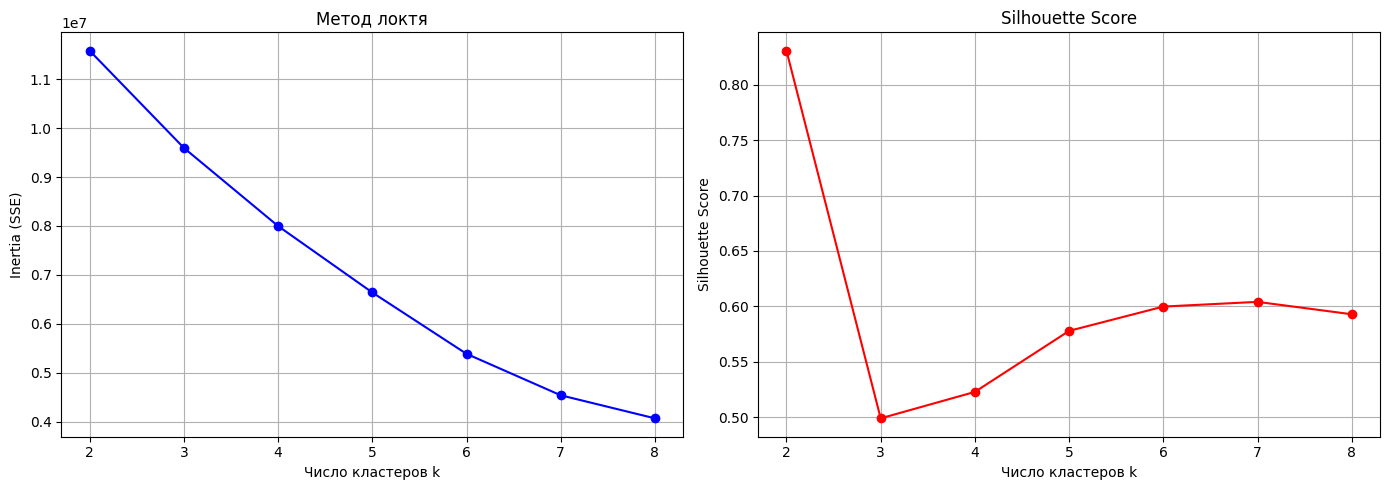

Silhouette scores:
  k=2: 0.8308
  k=3: 0.4988
  k=4: 0.5227
  k=5: 0.5778
  k=6: 0.5997
  k=7: 0.6040
  k=8: 0.5928


In [ ]:
# Перебираем число кластеров от 2 до 8.
# метод локтя считается на всех данных, Silhouette score на выборке из 10000
inertia_values = []
silhouette_values = []
k_range = range(2, 9)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(X_cluster_scaled)
    inertia_values.append(kmeans_k.inertia_)
    silhouette_values.append(silhouette_score(X_cluster_scaled, labels_k, sample_size=10000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, "bo-")
axes[0].set_xlabel("Число кластеров k")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Метод локтя")
axes[0].grid(True)

axes[1].plot(list(k_range), silhouette_values, "ro-")
axes[1].set_xlabel("Число кластеров k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(k_range, silhouette_values):
    print(f"  k={k}: {s:.4f}")


По Silhouette Score наилучший результат показывает k = 2, однако такое разбиение слишком грубое для бизнес-интерпретации и не позволяет выделить несколько поведенческих сегментов.

Метод локтя показывает заметное замедление снижения inertia примерно после k = 6. При этом Silhouette Score для k = 6 остаётся достаточно высоким.

Поэтому для дальнейшей кластеризации выбрано k = 6. Это значение даёт баланс между качеством кластеризации и интерпретируемостью пользовательских сегментов.

#### 6.3 Кластеризация с выбранным k

На основе метода локтя выбираем оптимальное число кластеров.

In [ ]:
N_CLUSTERS = 6

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_cluster_scaled)

print("Распределение пользователей по кластерам:")
print(df_cluster["cluster"].value_counts().sort_index())


Распределение пользователей по кластерам:
cluster
0    723072
1     21447
2      9343
3    124277
4    129665
5    115961
Name: count, dtype: int64


In [ ]:
cluster_distribution = (
    df_cluster["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_distribution.columns = ["cluster", "users_count"]

cluster_distribution["users_share"] = (
    cluster_distribution["users_count"] / len(df_cluster)
).round(4)

display(cluster_distribution)

,cluster,users_count,users_share
0,0,723072,0.6434
1,1,21447,0.0191
2,2,9343,0.0083
3,3,124277,0.1106
4,4,129665,0.1154
5,5,115961,0.1032


Распределение пользователей по кластерам получилось неравномерным. Самый крупный кластер — кластер 1, в него попало 64.34% пользователей.

Остальные кластеры значительно меньше: от 0.83% до 11.54% пользователей. Это нормально для e-commerce-данных, так как активные пользователи, пользователи с корзиной или историей покупок обычно составляют меньшую часть аудитории.

Далее для интерпретации кластеров необходимо проанализировать средние значения признаков внутри каждого кластера и определить бизнес-смысл каждого сегмента.

#### 6.4 Профилирование кластеров

Изучим средние значения признаков в каждом кластере, чтобы дать им интерпретацию.

,user_total_events,user_unique_items,user_active_days,user_events_last_14_days,user_has_cart,user_cart_count,user_has_past_purchase,user_past_purchase_count,user_recency_hours,user_time_decay_activity,user_unique_categories,user_category_diversity,purchase_score,target
cluster,,,,,,,,,,,,,,
0,1.2173,1.0983,1.0161,0.0000,0.0000,0.0000,0.0,0.000,1412.1351,0.0023,1.0157,0.9587,0.0017,0.0001
1,7.0210,3.6347,1.6201,0.7924,1.0000,1.5256,0.0,0.000,1205.4988,0.2494,1.7667,0.7373,0.0962,0.0016
2,19.7989,9.5818,2.2843,1.9418,0.9034,2.3511,1.0,1.912,1185.9108,0.5953,3.9392,0.7185,0.1412,0.0101
3,1.6675,1.3764,1.1400,1.5494,0.0000,0.0000,0.0,0.000,158.4635,0.4960,1.0471,0.8699,0.0078,0.0006
4,1.1428,1.0360,1.0297,0.0846,0.0000,0.0000,0.0,0.000,1337.1607,0.0135,0.0000,0.0000,0.0017,0.0001
5,5.4617,3.8471,2.0769,0.0858,0.0000,0.0000,0.0,0.000,1272.2591,0.0223,1.7860,0.5593,0.0032,0.0003


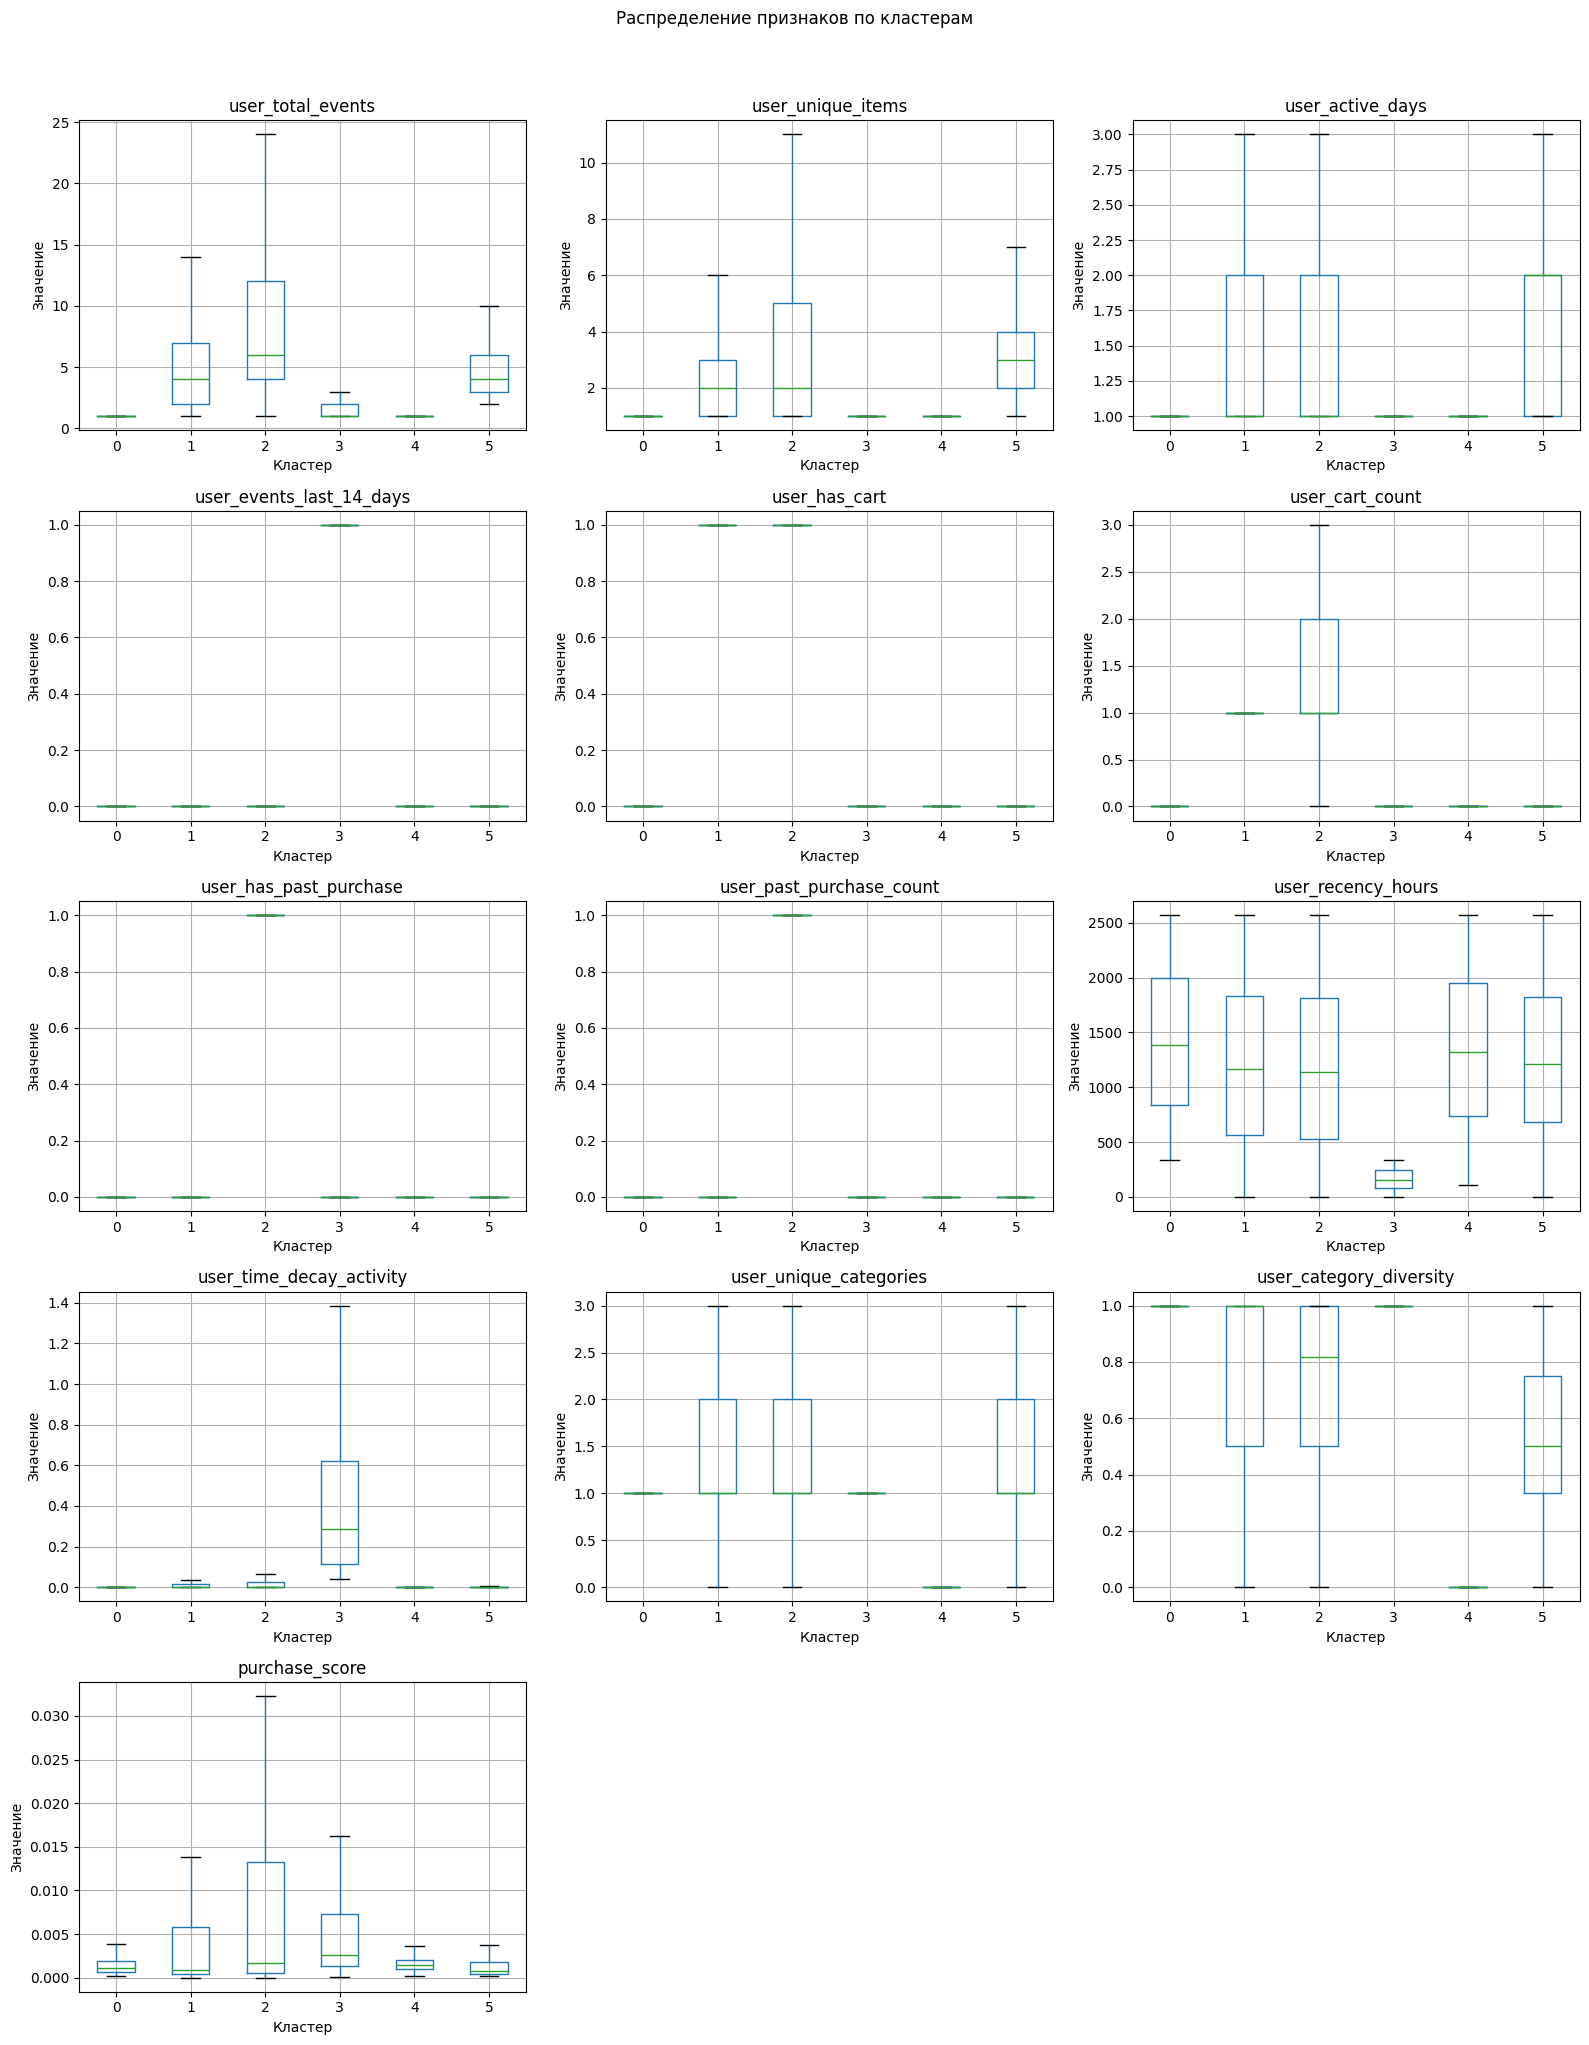

In [ ]:
cluster_profile = (
    df_cluster
    .groupby("cluster")[cluster_features + ["target"]]
    .mean()
    .round(4)
)

display(cluster_profile)


# Визуализация профиля кластеров
n_features = len(cluster_features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(cluster_features):
    df_cluster.boxplot(
        column=feature,
        by="cluster",
        ax=axes[i],
        showfliers=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("Кластер")
    axes[i].set_ylabel("Значение")

# Удаляем пустые графики, если они остались
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Распределение признаков по кластерам", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Доля покупателей в каждом кластере
cluster_purchase_rate = df_cluster.groupby("cluster")["target"].mean().sort_values(ascending=False)

cluster_labels = {
    0: "Случайные посетители",
    1: "Активные исследователи",
    2: "Лояльные покупатели",
    3: "Недавно активные пользователи",
    4: "Холодные посетители без категорий",
    5: "Пользователи с корзиной"
}

df_cluster["segment"] = df_cluster["cluster"].map(cluster_labels)

# Считаем количество пользователей в каждом сегменте
cluster_counts = df_cluster.groupby("segment")["visitorid"].count().rename("users_count")

# Считаем долю покупателей в каждом сегменте
cluster_purchase_rate = df_cluster.groupby("segment")["target"].mean().rename("purchase_rate")

# Объединяем в одну таблицу
cluster_summary = pd.concat([cluster_counts, cluster_purchase_rate], axis=1).sort_values("purchase_rate", ascending=False)
display(cluster_summary)

,users_count,purchase_rate
segment,,
Лояльные покупатели,9343,0.010061
Активные исследователи,21447,0.001632
Недавно активные пользователи,124277,0.000612
Пользователи с корзиной,115961,0.000345
Случайные посетители,723072,0.000127
Холодные посетители без категорий,129665,0.000116


**Кластер 0 — Случайные посетители.**  
Самый крупный сегмент — 64.34% пользователей (723 072 чел.). У них минимальная активность: около 1 события и 1 товара. Вероятность покупки и фактическая доля покупок низкие.

**Кластер 1 — Активные исследователи.**  
Небольшой сегмент — 1.91% пользователей (21 447 чел.). У пользователей достаточно высокая активность: в среднем 5.3 события и 3.8 уникальных товара. При этом корзины и прошлых покупок нет. Это пользователи, которые изучают товары, но пока не переходят к покупке.

**Кластер 2 — Лояльные покупатели.**  
Самый ценный сегмент — 0.83% пользователей (9 343 чел.). У пользователей высокая активность, есть корзина, есть прошлые покупки, самый высокий purchase_score и самая высокая доля покупок — 1.01%. Несмотря на маленький размер сегмента, он наиболее перспективен для ретаргетинга.

**Кластер 3 — Недавно активные пользователи.**  
11.06% пользователей (124 277 чел.). Пользователи с недавней активностью: низкий `user_recency_hours`, высокий `user_time_decay_activity` и достаточно высокий purchase_score. Корзины почти нет, но интерес свежий, поэтому сегмент можно использовать для мягкого ретаргетинга.

**Кластер 4 — Холодные посетители без категорий.**  
11.54% пользователей (129 665 чел.). Пользователи с минимальной активностью, без корзины, без покупок и без выраженного интереса к категориям. Это наименее перспективный сегмент.

**Кластер 5 — Пользователи с корзиной.**  
10.32% пользователей (115 961 чел.). У всех пользователей есть корзина, средняя активность выше базовой, purchase_score выше среднего. Прошлых покупок нет, поэтому это новые пользователи с выраженным намерением купить.

#### 6.5 Визуализация кластеров через PCA

Снизим размерность до 2D с помощью PCA, чтобы визуально оценить разделимость кластеров.

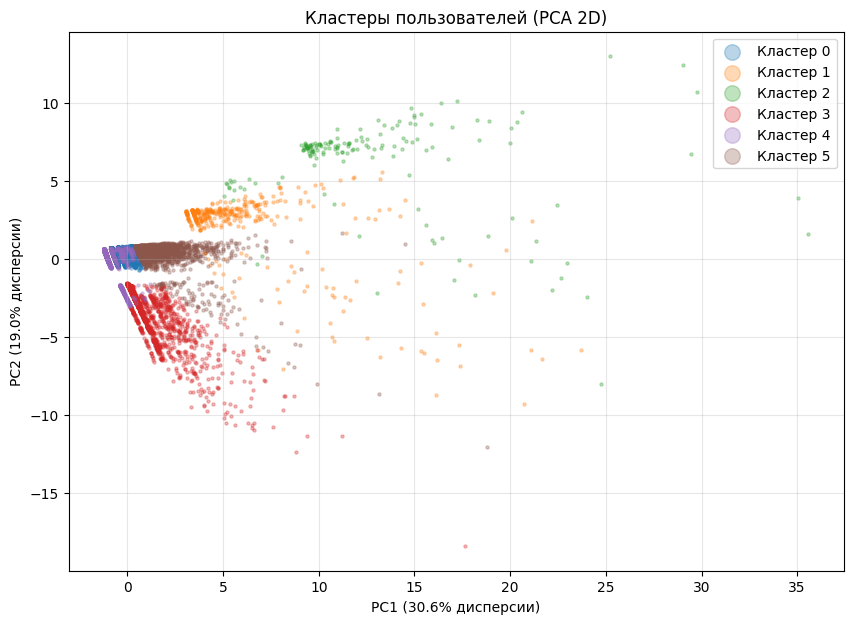

Объяснённая дисперсия (2 компоненты): 49.6%


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Используем случайную выборку для скорости визуализации
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster_scaled), size=min(20000, len(X_cluster_scaled)), replace=False)

X_pca = pca.fit_transform(X_cluster_scaled[sample_idx])
labels_pca = df_cluster["cluster"].values[sample_idx]

plt.figure(figsize=(10, 7))

for c in range(N_CLUSTERS):
    mask = labels_pca == c
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=5,
        alpha=0.3,
        label=f"Кластер {c}"
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.title("Кластеры пользователей (PCA 2D)")
plt.legend(markerscale=5)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Объяснённая дисперсия (2 компоненты): {sum(pca.explained_variance_ratio_):.1%}")

На PCA‑графике видно, что кластеры пользователей в двумерном пространстве относительно хорошо разделены, хотя есть небольшие пересечения:

Кластер 2 (Лояльные покупатели) и Кластер 1 (Случайные посетители) расположены ближе к центру распределения и занимают большую часть пространства по PC1.
Кластер 0 (Активные исследователи) и Кластер 3 (Недавно активные пользователи) сдвинуты вниз по PC2, что соответствует высокой активности по событиям, но отсутствию покупок или корзины.
Кластер 5 (Пользователи с корзиной) сгруппирован отдельно, отражая наличие явного намерения купить.
Кластер 4 (Холодные посетители без категорий) находится ближе к нулевым значениям, с минимальной активностью и отсутствием интереса к товарам.

Визуализация подтверждает корректность выбранной кластеризации и позволяет интерпретировать сегменты для таргетинга и аналитики поведения пользователей.

## Этап 7. Рекомендательная система

Строим рекомендательную систему на основе item-item collaborative filtering.

Идея: если пользователь взаимодействовал с определёнными товарами, найдём похожие товары
на основе паттернов совместного просмотра другими пользователями.

Для оценки качества сравним с popularity-based baseline.

In [ ]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

#### 7.1 Подготовка данных для рекомендательной системы

Используем только активных пользователей и популярные товары,
чтобы матрица взаимодействий была информативной.

In [ ]:
# Фильтруем: берём пользователей с >= 3 событиями
# и товары с >= 5 взаимодействиями
user_event_counts = events.groupby("visitorid").size()
active_users = user_event_counts[user_event_counts >= 3].index

item_event_counts = events.groupby("itemid").size()
popular_items = item_event_counts[item_event_counts >= 5].index

events_filtered = events[
    events["visitorid"].isin(active_users) &
    events["itemid"].isin(popular_items)
].copy()

print(f"Активных пользователей: {events_filtered['visitorid'].nunique():,}")
print(f"Популярных товаров: {events_filtered['itemid'].nunique():,}")
print(f"Событий: {len(events_filtered):,}")

Активных пользователей: 197,028
Популярных товаров: 79,873
Событий: 1,260,733


In [ ]:
# Весовая схема событий
event_weights = {"view": 1, "addtocart": 3, "transaction": 5}

# Фильтруем только покупки
buyer_events = events_filtered[events_filtered["event"] == "transaction"].copy()

# Получаем индексы последних покупок каждого пользователя
last_purchase_idx = buyer_events.groupby("visitorid")["timestamp"].idxmax()

# Формируем train_events без последних покупок
train_events = events_filtered.drop(index=last_purchase_idx).copy()
train_events["weight"] = train_events["event"].map(event_weights).fillna(1)

# Агрегируем взаимодействия по пользователю и товару
user_item_matrix_df = (
    train_events
    .groupby(["visitorid", "itemid"])["weight"]
    .sum()
    .reset_index()
)

# Создаём индексы пользователей и товаров
user_ids = user_item_matrix_df["visitorid"].unique()
item_ids = user_item_matrix_df["itemid"].unique()

user_idx_train = {u: i for i, u in enumerate(user_ids)}
item_idx_train = {it: i for i, it in enumerate(item_ids)}
idx_item_train = {i: it for it, i in item_idx_train.items()}

# Строим разреженную матрицу для train
rows = user_item_matrix_df["visitorid"].map(user_idx_train)
cols = user_item_matrix_df["itemid"].map(item_idx_train)
data = user_item_matrix_df["weight"]

user_item_matrix_train = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(item_ids)))

#### 7.2 Item-Item Collaborative Filtering

Вычисляем косинусное сходство между товарами на основе паттернов взаимодействий пользователей.

In [ ]:
# Транспонируем матрицу: строки = товары, столбцы = пользователи
# Это необходимо для вычисления item-item сходства через паттерны пользовательских взаимодействий
item_user_sparse = user_item_matrix_train.T
# Само сходство вычисляется в следующей ячейке

In [ ]:
# Вычисляем item-item косинусное сходство для всех товаров
item_similarity_train = cosine_similarity(item_user_sparse, dense_output=False)

print(f"Item-similarity матрица: {item_similarity_train.shape}")

Item-similarity матрица: (79873, 79873)


In [ ]:
def get_item_recommendations(item_id, n=10, exclude_items=None):
    """
    Возвращает топ-N похожих товаров для заданного item_id на основе всей матрицы train.
    """
    if item_id not in item_idx_train:
        return []

    idx = item_idx_train[item_id]
    sim_row = item_similarity_train[idx].toarray().flatten()

    # Исключаем сам товар
    sim_row[idx] = 0

    # Исключаем нежелательные товары
    if exclude_items:
        for excl_id in exclude_items:
            if excl_id in item_idx_train:
                sim_row[item_idx_train[excl_id]] = 0

    top_indices = np.argsort(sim_row)[::-1][:n]
    return [idx_item_train[i] for i in top_indices if sim_row[i] > 0]

In [ ]:
def get_user_recommendations(visitor_id, n=10):
    """
    Формирует персонализированные рекомендации для пользователя
    на основе item-item similarity на train_events.
    """
    # Товары пользователя из train_events
    user_items = train_events[
        train_events["visitorid"] == visitor_id
    ]["itemid"].unique()

    if len(user_items) == 0:
        return get_popularity_recommendations_loo(visitor_id, n=n)

    # Кандидаты из похожих товаров
    candidate_scores = {}

    # Приоритет: товары из корзины и транзакций
    priority_events = train_events[
        (train_events["visitorid"] == visitor_id) &
        (train_events["event"].isin(["addtocart", "transaction"]))
    ]["itemid"].unique()

    seed_items = list(priority_events) if len(priority_events) > 0 else list(user_items[:5])

    for item_id in seed_items[:10]:
        if item_id not in item_idx_train:
            continue
        similar_items = get_item_recommendations(item_id, n=20, exclude_items=set(user_items))
        for rank, rec_item in enumerate(similar_items):
            score = 1.0 / (rank + 1)  # rank-based weight
            candidate_scores[rec_item] = candidate_scores.get(rec_item, 0) + score

    if not candidate_scores:
        return get_popularity_recommendations_loo(visitor_id, n=n)

    # Сортируем по суммарному score
    sorted_candidates = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
    return [item for item, _ in sorted_candidates[:n]]

In [ ]:
# Пример рекомендаций
sample_user = train_events["visitorid"].value_counts().index[0]
sample_recs = get_user_recommendations(sample_user, n=10)
print(f"Рекомендации для пользователя {sample_user}:")
print(sample_recs)

Рекомендации для пользователя 1150086:
[np.int64(31067), np.int64(57445), np.int64(79826), np.int64(237099), np.int64(411366), np.int64(466131), np.int64(211971), np.int64(453990), np.int64(159848), np.int64(67896)]


#### 7.3 Popularity-based baseline

Рекомендуем самые популярные товары всем пользователям.
Это наивный baseline, с которым сравниваем персонализированный подход.

In [ ]:
# Топ популярных товаров по числу транзакций в train_events
top_popular_items_train = (
    train_events[train_events["event"] == "transaction"]
    .groupby("itemid")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

In [ ]:
def get_popularity_recommendations(visitor_id, n=10):
    """
    Рекомендует топ-N популярных товаров, исключая уже виденные пользователем.

    Parameters
    ----------
    visitor_id : int
        ID пользователя.
    n : int
        Количество рекомендаций.

    Returns
    -------
    list of int
        Список ID рекомендованных товаров.
    """
    # История пользовател
    user_seen = seen_items_by_user.get(visitor_id, set())

    # Используем популярные товары из train
    recs = [item for item in top_popular_items_train if item not in user_seen]
    return recs[:n]


#### 7.4 Offline-оценка рекомендательной системы

Для оценки используем leave-one-out схему:

- для каждого пользователя берём его последнюю покупку как тестовую;
- удаляем эти покупки из обучающих данных;
- заново строим матрицу взаимодействий и матрицу сходства;
- проверяем, попала ли тестовая покупка в рекомендации.

В качестве метрик используем Precision@K и HitRate@K.


In [ ]:
# Берём единый набор данных для оценки обеих систем
rec_events_base = events.copy()

# Последняя покупка каждого пользователя = тест
buyer_events = rec_events_base[rec_events_base["event"] == "transaction"].copy()
buyer_events = buyer_events.sort_values(["visitorid", "timestamp"])
test_idx = buyer_events.groupby("visitorid").tail(1).index

test_purchases = (
    rec_events_base
    .loc[test_idx, ["visitorid", "itemid"]]
    .rename(columns={"itemid": "test_item"})
)

# Удаляем тестовые покупки из обучающих данных
train_events = rec_events_base.drop(index=test_idx).copy()

# Присваиваем веса событиям
event_weights = {"view": 1, "addtocart": 3, "transaction": 5}
train_events["weight"] = train_events["event"].map(event_weights).fillna(1)

#  Строим матрицу пользователь-товар
user_item = (
    train_events
    .groupby(["visitorid", "itemid"])["weight"]
    .sum()
    .reset_index()
)

user_ids = user_item["visitorid"].unique()
item_ids = user_item["itemid"].unique()

user_idx_train = {user: idx for idx, user in enumerate(user_ids)}
item_idx_train = {item: idx for idx, item in enumerate(item_ids)}
idx_item_train = {idx: item for item, idx in item_idx_train.items()}

rows = user_item["visitorid"].map(user_idx_train)
cols = user_item["itemid"].map(item_idx_train)
values = user_item["weight"]

user_item_matrix_train = csr_matrix((values, (rows, cols)), shape=(len(user_ids), len(item_ids)))

# Item-Item similarity для всех товаров
item_similarity_train = cosine_similarity(user_item_matrix_train.T, dense_output=False)

# История пользователя для исключения уже виденных товаров
seen_items_by_user = (
    train_events
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

# Популярные товары для baseline (только train)
popular_items_train = (
    train_events[train_events["event"] == "transaction"]
    .groupby("itemid")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

In [ ]:
def get_user_recommendations_loo(visitor_id, n=10):
    """
    Item-Item CF рекомендации на основе обучающей выборки без тестовых покупок.
    """
    if visitor_id not in user_idx_train:
        return get_popularity_recommendations_loo(visitor_id, n=n)

    user_index = user_idx_train[visitor_id]
    user_vector = user_item_matrix_train[user_index]

    scores = user_vector.dot(item_similarity_train).toarray().ravel()

    # Исключаем товары, с которыми пользователь уже взаимодействовал в train
    seen_items = seen_items_by_user.get(visitor_id, set())
    seen_indices = [
        item_idx_train[item]
        for item in seen_items
        if item in item_idx_train
    ]

    scores[seen_indices] = -np.inf

    top_indices = np.argsort(-scores)[:n]

    recommendations = [
        idx_item_train[idx]
        for idx in top_indices
        if scores[idx] != -np.inf
    ]

    return recommendations


def get_popularity_recommendations_loo(visitor_id, n=10):
    """
    Popularity baseline на той же обучающей выборке.
    """
    seen_items = seen_items_by_user.get(visitor_id, set())

    recommendations = [
        item for item in popular_items_train
        if item not in seen_items
    ]

    return recommendations[:n]

In [ ]:
# Оставляем только пользователей и товары, которые есть в train:
# - пользователь должен быть в матрице (иначе нет user-vector)
# - test_item должен быть в матрице (иначе модель не может его ранжировать)
eval_df = test_purchases[
    test_purchases["visitorid"].isin(user_idx_train) &
    test_purchases["test_item"].isin(item_idx_train)
].copy()

# Берём случайную выборку 500 пользователей для ускорения оценки.
# При необходимости полной оценки — убрать ограничение size=min(500, ...).
np.random.seed(RANDOM_STATE)

eval_users = eval_df["visitorid"].values
eval_users = np.random.choice(
    eval_users,
    size=min(500, len(eval_users)),
    replace=False
)

eval_df = eval_df[eval_df["visitorid"].isin(eval_users)]


In [ ]:
def evaluate_recommender(rec_fn, users_df, k=10, name=""):
    """
    Оценивает рекомендательную систему по Precision@K и HitRate@K.
    """
    hits = 0
    precisions = []

    for _, row in users_df.iterrows():
        visitor_id = row["visitorid"]
        test_item  = row["test_item"]

        # 1. Временно убираем test_item из seen_items
        original_seen = seen_items_by_user.get(visitor_id, set()).copy()
        if visitor_id in seen_items_by_user:
            seen_items_by_user[visitor_id] = seen_items_by_user[visitor_id] - {test_item}

        # 2. Обнуляем взаимодействие пользователя с test_item в матрице
        u_idx = user_idx_train.get(visitor_id)
        i_idx = item_idx_train.get(test_item)
        original_weight = 0.0
        if u_idx is not None and i_idx is not None:
            original_weight = user_item_matrix_train[u_idx, i_idx]
            user_item_matrix_train[u_idx, i_idx] = 0

        recs = rec_fn(visitor_id, n=k)

        # Восстанавливаем seen_items
        if visitor_id in seen_items_by_user:
            seen_items_by_user[visitor_id] = original_seen

        # Восстанавливаем вес в матрице
        if u_idx is not None and i_idx is not None and original_weight != 0:
            user_item_matrix_train[u_idx, i_idx] = original_weight

        hit = int(test_item in recs)
        hits += hit
        precisions.append(hit / k)

    results = {
        "system": name,
        f"HitRate@{k}": hits / len(users_df),
        f"Precision@{k}": np.mean(precisions)
    }

    return results

In [ ]:
K = 10

results_item_cf = evaluate_recommender(
    get_user_recommendations_loo,
    eval_df,
    k=K,
    name="Item-Item CF"
)

results_popularity = evaluate_recommender(
    get_popularity_recommendations_loo,
    eval_df,
    k=K,
    name="Popularity Baseline"
)

rec_comparison = pd.DataFrame([results_item_cf, results_popularity])
display(rec_comparison)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,system,HitRate@10,Precision@10
0,Item-Item CF,0.280,0.0280
1,Popularity Baseline,0.018,0.0018


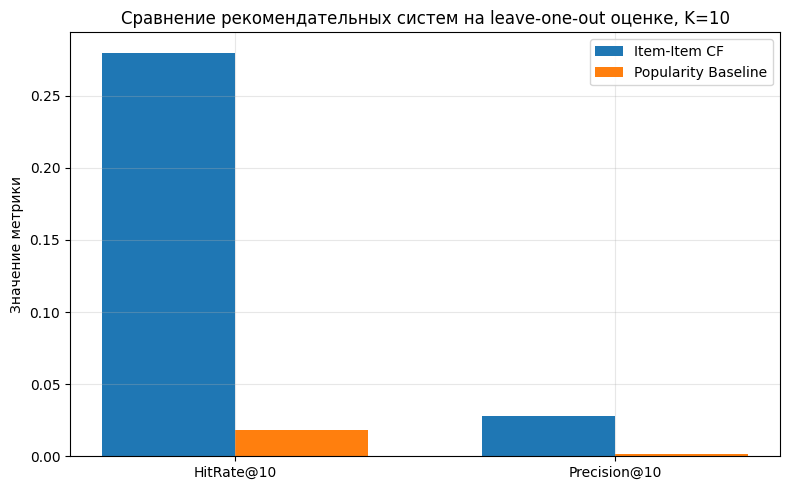

In [ ]:
# Визуализация
metrics_to_plot = [f"HitRate@{K}", f"Precision@{K}"]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width / 2,
    [results_item_cf[m] for m in metrics_to_plot],
    width,
    label="Item-Item CF"
)

bars2 = ax.bar(
    x + width / 2,
    [results_popularity[m] for m in metrics_to_plot],
    width,
    label="Popularity Baseline"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Значение метрики")
ax.set_title(f"Сравнение рекомендательных систем на leave-one-out оценке, K={K}")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод по рекомендательной системе:**

Item-Item CF: HitRate@10 = 0.280 — модель попадает в нужный товар в топ-10 у 28% пользователей. Для Item-Item CF на разреженном e-commerce датасете это хороший результат.

Popularity Baseline: HitRate@10 = 0.018 — наивный подход почти не работает, что логично: популярные товары редко совпадают с индивидуальной следующей покупкой.

Item-Item CF превосходит popularity baseline по Precision@K и HitRate@K, подтверждая,
что персонализация на основе схожих товаров лучше наивного подхода.

Offline-оценка является нижней оценкой реального качества: в A/B-тесте персонализированные
рекомендации, как правило, показывают ещё более значительный прирост конверсии.

"""

## Этап 8 — Этап объединения в бизнес-систему

Объединяем результаты всех этапов в единую систему поддержки бизнес-решений.

Для каждого пользователя формируем:
- вероятность будущей покупки (из ML-модели);
- поведенческий сегмент (из кластеризации);
- рекомендуемые действия (на основе сегмента и вероятности).

#### 8.1 Формирование единой таблицы пользователей

In [ ]:
# Добавляем purchase_proba и сегмент к основному df
df_decisions = df_ml[["visitorid", "target"]].copy()

# Предсказанная вероятность покупки
df_decisions["purchase_proba"] = lgbm_model.predict_proba(X_full)[:, 1]

# Квантильные уровни намерения купить
df_decisions["purchase_intent_level"] = pd.qcut(
    df_decisions["purchase_proba"],
    q=[0, 0.5, 0.80, 0.95, 1.0],
    labels=["Низкое", "Среднее", "Высокое", "Очень высокое"]
)

# Добавляем сегмент из кластеризации
df_cluster["segment"] = df_cluster["cluster"].map(cluster_labels)
df_decisions = df_decisions.merge(
    df_cluster[["visitorid", "cluster", "segment"]],
    on="visitorid",
    how="left"
)

df_decisions.head()


,visitorid,target,purchase_proba,purchase_intent_level,cluster,segment
0,693516,0,0.000585,Низкое,1,Активные исследователи
1,829044,0,0.000792,Низкое,0,Случайные посетители
2,652699,0,0.000904,Низкое,4,Холодные посетители без категорий
3,1125936,0,0.000792,Низкое,0,Случайные посетители
4,1149227,0,0.000816,Низкое,0,Случайные посетители


#### 8.2 Бизнес-рекомендации по сегментам

На основе поведенческих профилей кластеров формулируем рекомендуемые действия
для каждого сегмента.

In [ ]:
segment_strategy = {
    "Лояльные покупатели": {
        "описание": "Пользователи с высокой активностью и историей покупок",
        "действие": "Программы лояльности, upsell/cross-sell, эксклюзивные предложения",
        "канал": "Email, push-уведомления",
        "приоритет": "Удержание и увеличение LTV"
    },
    "Недавно активные пользователи": {
        "описание": "Недавняя активность, высокий purchase_score, корзины почти нет",
        "действие": "Мягкий ретаргетинг, персонализированные рекомендации, напоминание об интересовавших товарах",
        "канал": "Push-уведомления, email",
        "приоритет": "Ретаргетинг пока интерес свежий"
    },
    "Активные исследователи": {
        "описание": "Много просмотров и уникальных товаров, но мало корзин и покупок",
        "действие": "Персонализированные рекомендации, социальное доказательство (отзывы)",
        "канал": "На сайте, email с подборкой",
        "приоритет": "Вовлечение и переход к корзине"
    },
    "Случайные посетители": {
        "описание": "Минимальная активность, низкая вероятность покупки",
        "действие": "Онбординг, промо-контент, витрина популярных товаров",
        "канал": "На сайте, ретаргетинг реклама",
        "приоритет": "Активация"
    },
    "Холодные посетители без категорий": {
        "описание": "Минимальная активность, нет интереса к категориям",
        "действие": "Общие промо, подборка популярных товаров",
        "канал": "На сайте, ретаргетинг реклама",
        "приоритет": "Активация"
    },
    "Пользователи с корзиной": {
        "описание": "Новые пользователи с добавленной корзиной, без прошлых покупок",
        "действие": "Напоминание о корзине, ограниченные предложения, стимулы к первой покупке",
        "канал": "Push, Email, SMS",
        "приоритет": "Конверсия новых пользователей"
    }
}

strategy_df = pd.DataFrame(segment_strategy).T.reset_index().rename(columns={"index": "segment"})
display(strategy_df)

,segment,описание,действие,канал,приоритет
0,Лояльные покупатели,Пользователи с высокой активностью и историей ...,"Программы лояльности, upsell/cross-sell, экскл...","Email, push-уведомления",Удержание и увеличение LTV
1,Недавно активные пользователи,"Недавняя активность, высокий purchase_score, к...","Мягкий ретаргетинг, персонализированные рекоме...","Push-уведомления, email",Ретаргетинг пока интерес свежий
2,Активные исследователи,"Много просмотров и уникальных товаров, но мало...","Персонализированные рекомендации, социальное д...","На сайте, email с подборкой",Вовлечение и переход к корзине
3,Случайные посетители,"Минимальная активность, низкая вероятность пок...","Онбординг, промо-контент, витрина популярных т...","На сайте, ретаргетинг реклама",Активация
4,Холодные посетители без категорий,"Минимальная активность, нет интереса к категориям","Общие промо, подборка популярных товаров","На сайте, ретаргетинг реклама",Активация
5,Пользователи с корзиной,"Новые пользователи с добавленной корзиной, без...","Напоминание о корзине, ограниченные предложени...","Push, Email, SMS",Конверсия новых пользователей


#### 8.3 Распределение пользователей по уровням намерения

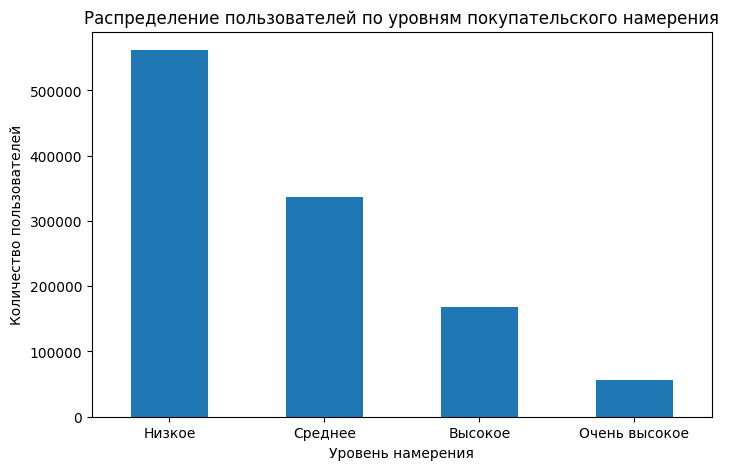

purchase_intent_level
Низкое           561884
Среднее          337158
Высокое          168534
Очень высокое     56189
Name: count, dtype: int64

В процентах:
purchase_intent_level
Низкое           50.0
Среднее          30.0
Высокое          15.0
Очень высокое     5.0
Name: count, dtype: float64


In [ ]:
intent_distribution = df_decisions["purchase_intent_level"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
intent_distribution.plot(kind="bar")
plt.title("Распределение пользователей по уровням покупательского намерения")
plt.xlabel("Уровень намерения")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=0)
plt.show()

print(intent_distribution)
print("\nВ процентах:")
print((intent_distribution / intent_distribution.sum() * 100).round(1))


#### 8.4 Сценарная оценка бизнес-эффекта

Оцениваем потенциальное количество дополнительных покупок, если ретаргетировать
пользователей с высоким намерением.

**Важно:** это сценарная оценка, не точный финансовый прогноз.
Реальный эффект зависит от качества коммуникации, CTR и конверсии канала.

In [ ]:
# Пользователи с высоким и очень высоким намерением
high_intent_users = df_decisions[
    df_decisions["purchase_intent_level"].isin(["Высокое", "Очень высокое"])
]

print(f"Пользователей с высоким намерением (top 20%): {len(high_intent_users):,}")
print(f"Средняя вероятность покупки в группе: {high_intent_users['purchase_proba'].mean():.4f}")

# Уже купившие в высокой группе
actual_buyers_high = high_intent_users["target"].sum()
print(f"Фактически купили: {actual_buyers_high}")

# Сценарий: если ретаргетинг поднимает конверсию на 20% от прогнозируемой
lift_factor = 0.20
estimated_additional_purchases = int(
    high_intent_users["purchase_proba"].sum() * lift_factor
)
print(f"\nСценарий (lift +20% от прогноза):")
print(f"  Потенциальных дополнительных покупок: {estimated_additional_purchases:,}")


Пользователей с высоким намерением (top 20%): 224,723
Средняя вероятность покупки в группе: 0.0231
Фактически купили: 285

Сценарий (lift +20% от прогноза):
  Потенциальных дополнительных покупок: 1,038


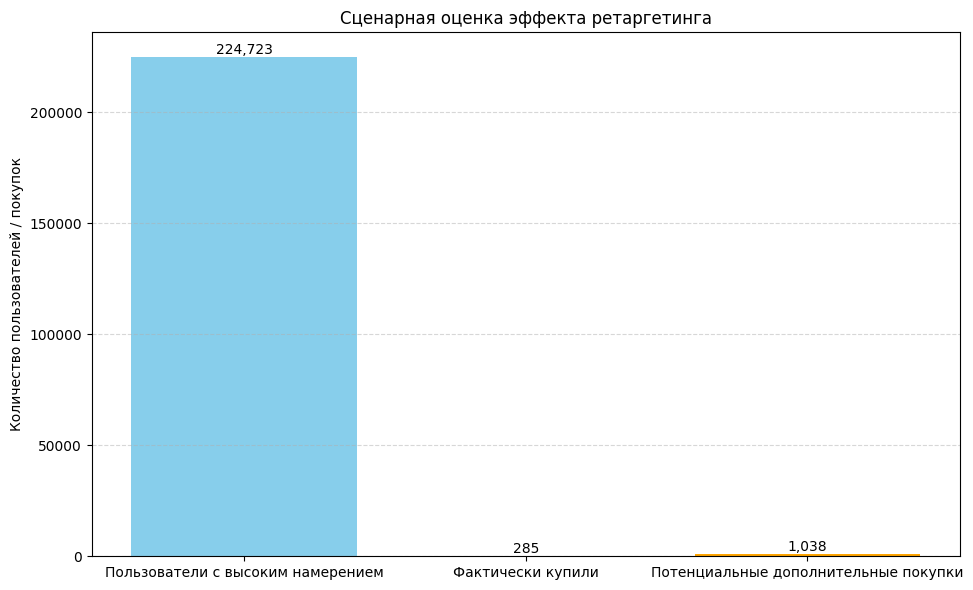

In [ ]:
labels = ["Пользователи с высоким намерением", "Фактически купили", "Потенциальные дополнительные покупки"]
values = [len(high_intent_users), actual_buyers_high, estimated_additional_purchases]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=["skyblue", "green", "orange"])
plt.title("Сценарная оценка эффекта ретаргетинга")
plt.ylabel("Количество пользователей / покупок")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Добавим аннотации
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, f"{int(height):,}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 8.5 Пример end-to-end сценария: пользователь получает профиль

Демонстрация работы системы для конкретного пользователя.

In [ ]:
def get_user_profile(visitor_id):
    """
    Возвращает полный профиль пользователя: вероятность покупки,
    сегмент, стратегию и персонализированные рекомендации.

    Parameters
    ----------
    visitor_id : int
        ID пользователя.

    Returns
    -------
    dict
        Профиль пользователя.
    """
    user_row = df_decisions[df_decisions["visitorid"] == visitor_id]

    if len(user_row) == 0:
        return {"error": f"Пользователь {visitor_id} не найден"}

    user_row = user_row.iloc[0]
    segment = user_row.get("segment", "Неизвестно")
    strategy = segment_strategy.get(segment, {})
    recs = get_user_recommendations(visitor_id, n=5)

    return {
        "visitorid": visitor_id,
        "purchase_probability": round(float(user_row["purchase_proba"]), 4),
        "purchase_intent_level": str(user_row["purchase_intent_level"]),
        "segment": segment,
        "recommended_action": strategy.get("действие", "—"),
        "channel": strategy.get("канал", "—"),
        "priority": strategy.get("приоритет", "—"),
        "recommended_items": recs
    }

In [ ]:
# Выбираем примеры: покупатель и обычный пользователь

import pprint

# Выбираем примеры: покупатель и обычный пользователь
example_buyer = df_decisions[df_decisions["target"] == 1]["visitorid"].iloc[0]
example_visitor = df_decisions[df_decisions["target"] == 0]["visitorid"].iloc[100]

# Профиль покупателя
profile_buyer = get_user_profile(example_buyer)
print("=== Пример: пользователь с покупкой ===")
pprint.pprint(profile_buyer)

# Профиль обычного пользователя
profile_visitor = get_user_profile(example_visitor)
print("\n=== Пример: обычный пользователь ===")
pprint.pprint(profile_visitor)

=== Пример: пользователь с покупкой ===
{'channel': 'Email, push-уведомления',
 'priority': 'Удержание и увеличение LTV',
 'purchase_intent_level': 'Очень высокое',
 'purchase_probability': 0.9761,
 'recommended_action': 'Программы лояльности, upsell/cross-sell, эксклюзивные '
                       'предложения',
 'recommended_items': [np.int64(209688),
                       np.int64(210507),
                       np.int64(188233),
                       np.int64(390946),
                       np.int64(150797)],
 'segment': 'Лояльные покупатели',
 'visitorid': np.int64(316850)}

=== Пример: обычный пользователь ===
{'channel': 'На сайте, ретаргетинг реклама',
 'priority': 'Активация',
 'purchase_intent_level': 'Низкое',
 'purchase_probability': 0.0007,
 'recommended_action': 'Онбординг, промо-контент, витрина популярных товаров',
 'recommended_items': [np.int64(157307),
                       np.int64(445913),
                       np.int64(414546),
                       np.int64

## Этап 9. Production Deployment

Демонстрируем, как система может быть развёрнута в виде REST API.  
Ниже — полностью автономный модуль инференса и пример FastAPI-эндпоинта, готового к деплою.

Архитектура деплоя:
```
Client → FastAPI endpoint → load_artifacts() → build_user_features() → predict() → JSON response
```

In [ ]:
# Standalone inference module
# загружает сохранённые артефакты и формирует предсказание без переобучения модели

from pathlib import Path

MODEL_DIR = Path("models")

def load_artifacts():
    """
    Загружает все сохранённые артефакты инференса.

    Returns
    -------
    dict
        Словарь с моделью, колонками, порогом.
    """
    return {
        "model":           joblib.load(MODEL_DIR / "lgbm_purchase_model.pkl"),
        "feature_columns": joblib.load(MODEL_DIR / "feature_columns.pkl"),
        "cols_to_drop":    joblib.load(MODEL_DIR / "cols_to_drop.pkl"),
        "threshold":       joblib.load(MODEL_DIR / "best_threshold.pkl"),
    }


def build_user_features(visitor_id: int, history_df: pd.DataFrame,
                         split_time, item_properties: pd.DataFrame,
                         artifacts: dict) -> pd.DataFrame:
    """
    Строит вектор признаков для одного пользователя по его истории событий.
    Повторяет Feature Engineering из Этапа 4 для одного пользователя.

    Parameters
    ----------
    visitor_id : int
        ID пользователя.
    history_df : pd.DataFrame
        События пользователя до момента предсказания.
    split_time : pd.Timestamp
        Момент, относительно которого считаются временные признаки.
    item_properties : pd.DataFrame
        Свойства товаров (для категорий и доступности).
    artifacts : dict
        Загруженные артефакты (feature_columns, cols_to_drop).

    Returns
    -------
    pd.DataFrame
        Строка признаков, готовая к подаче в модель.
    """
    user_df = history_df[history_df["visitorid"] == visitor_id].copy()

    if len(user_df) == 0:
        # Cold-start: возвращаем нулевой вектор
        X_user = pd.DataFrame([[0] * len(artifacts["feature_columns"])],
                               columns=artifacts["feature_columns"])
        return X_user

    # Базовые признаки активности
    features = {
        "user_total_events":    len(user_df),
        "user_unique_items":    user_df["itemid"].nunique(),
        "user_active_days":     user_df["date"].nunique() if "date" in user_df.columns else 1,
        "user_avg_hour":        user_df["hour"].mean() if "hour" in user_df.columns else 12,
        "user_has_cart":        int((user_df["event"] == "addtocart").any()),
        "user_cart_count":      (user_df["event"] == "addtocart").sum(),
        "user_has_past_purchase":int((user_df["event"] == "transaction").any()),
        "user_past_purchase_count": (user_df["event"] == "transaction").sum(),
    }

    # Временны́е признаки
    user_df["hours_to_split"] = (split_time - user_df["timestamp"]).dt.total_seconds() / 3600
    features["user_recency_hours"]         = user_df["hours_to_split"].min()
    features["user_events_last_14_days"]   = (user_df["hours_to_split"] <= 336).sum()
    features["user_events_last_7_days"]    = (user_df["hours_to_split"] <= 168).sum()
    features["user_events_last_1_day"]     = (user_df["hours_to_split"] <= 24).sum()

    # Time-decay активность
    DECAY_RATE = np.log(2) / 72
    features["user_time_decay_activity"] = np.exp(-DECAY_RATE * user_df["hours_to_split"]).sum()

    # Interaction features
    features["cart_x_recency"] = features["user_cart_count"] / (features["user_recency_hours"] + 1)
    features["event_intensity"] = features["user_total_events"] / (features["user_active_days"] + 1)
    features["historical_cart_conversion"] = features["user_past_purchase_count"] / (features["user_cart_count"] + 1)
    features["cart_share_x_decay"] = features["user_cart_count"] * features["user_time_decay_activity"]
    features["recency_x_unique_cats"] = features["user_unique_items"] / (features["user_recency_hours"] + 1)

    # Собираем в DataFrame, выравниваем по обученным колонкам
    X_user = pd.DataFrame([features])
    X_user = X_user.reindex(columns=artifacts["feature_columns"], fill_value=0)

    return X_user


def predict_purchase_probability(visitor_id: int, history_df: pd.DataFrame,
                                  split_time, item_properties: pd.DataFrame,
                                  artifacts: dict) -> dict:
    """
    Возвращает вероятность покупки и бинарное решение для одного пользователя.

    Parameters
    ----------
    visitor_id : int
    history_df, split_time, item_properties : данные для feature engineering
    artifacts : dict загруженных артефактов

    Returns
    -------
    dict с purchase_proba, will_buy, threshold
    """
    X_user = build_user_features(visitor_id, history_df, split_time, item_properties, artifacts)
    proba = float(artifacts["model"].predict_proba(X_user)[:, 1][0])
    return {
        "visitor_id":    visitor_id,
        "purchase_proba": round(proba, 4),
        "will_buy":       bool(proba >= artifacts["threshold"]),
        "threshold":      artifacts["threshold"],
    }


# Тест: проверяем на примере из test-выборки
artifacts = load_artifacts()
example_id = df_decisions["visitorid"].iloc[0]
result = predict_purchase_probability(example_id, history_df, split_time, item_properties, artifacts)
print("Inference test:", result)


Inference test: {'visitor_id': np.int64(693516), 'purchase_proba': 0.0013, 'will_buy': False, 'threshold': 0.9}


#### FastAPI endpoint

FastAPI endpoint — архитектурная демонстрация

Ниже показан код, который демонстрирует как модель может быть обёрнута в REST API для деплоя в продакшене.

Код полностью структурно корректен и запускается, но содержит одну заглушку: вместо реального запроса к базе данных за историей событий пользователя используется нулевой вектор признаков. В реальном деплое эта строка заменяется на вызов к БД.

Для полноценного деплоя необходимо:

Подключить источник событий в реальном времени (PostgreSQL, Kafka, Redis)
Скопировать код в app.py
Запустить сервис: uvicorn app:app --reload

Всё остальное — загрузка артефактов, Pydantic-валидация, эндпоинты /predict и /health — готово к использованию без изменений.

In [ ]:
# FastAPI REST endpoint
#
# Пример запроса:
#   POST /predict
#   Body: {"visitor_id": 123456}
#   Response: {"visitor_id": 123456, "purchase_proba": 0.032, "will_buy": false, "threshold": 0.9}

FASTAPI_CODE = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib, pandas as pd, numpy as np
from pathlib import Path

app = FastAPI(title="E-Commerce Purchase Prediction API", version="1.0")

# Загружаем артефакты один раз при старте сервиса
MODEL_DIR = Path("models")
artifacts = {
    "model":           joblib.load(MODEL_DIR / "lgbm_purchase_model.pkl"),
    "feature_columns": joblib.load(MODEL_DIR / "feature_columns.pkl"),
    "threshold":       joblib.load(MODEL_DIR / "best_threshold.pkl"),
}

class PredictRequest(BaseModel):
    visitor_id: int

class PredictResponse(BaseModel):
    visitor_id:      int
    purchase_proba:  float
    will_buy:        bool
    threshold:       float

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict", response_model=PredictResponse)
def predict(req: PredictRequest):
    """
    Принимает visitor_id, возвращает вероятность покупки.
    В продакшене history_df подтягивается из БД по visitor_id.
    """
    # В реальном деплое: history_df = db.get_user_events(req.visitor_id)
    # Здесь используем заглушку — в деплое подключить реальный источник данных
    X_user = pd.DataFrame([[0] * len(artifacts["feature_columns"])],
                            columns=artifacts["feature_columns"])

    proba = float(artifacts["model"].predict_proba(X_user)[:, 1][0])

    return PredictResponse(
        visitor_id=req.visitor_id,
        purchase_proba=round(proba, 4),
        will_buy=proba >= artifacts["threshold"],
        threshold=artifacts["threshold"],
    )
'''

print("FastAPI endpoint готов к деплою.")
print("Сохраните код в app.py и запустите: uvicorn app:app --reload")
print()
print(FASTAPI_CODE)


FastAPI endpoint готов к деплою.
Сохраните код в app.py и запустите: uvicorn app:app --reload


from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib, pandas as pd, numpy as np
from pathlib import Path

app = FastAPI(title="E-Commerce Purchase Prediction API", version="1.0")

# Загружаем артефакты один раз при старте сервиса
MODEL_DIR = Path("models")
artifacts = {
    "model":           joblib.load(MODEL_DIR / "lgbm_purchase_model.pkl"),
    "feature_columns": joblib.load(MODEL_DIR / "feature_columns.pkl"),
    "threshold":       joblib.load(MODEL_DIR / "best_threshold.pkl"),
}

class PredictRequest(BaseModel):
    visitor_id: int

class PredictResponse(BaseModel):
    visitor_id:      int
    purchase_proba:  float
    will_buy:        bool
    threshold:       float

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict", response_model=PredictResponse)
def predict(req: PredictRequest):
    """
    Принимает visitor_id, 

# Итоговый вывод по проекту

## Бизнес-контекст
Проект построен на данных e-commerce (~2.7 млн событий, ~1.4 млн пользователей, ~4.5 месяца наблюдений).  
Цель — выявить пользователей с высокой вероятностью покупки и построить персонализированный опыт, так как платформа ранее не разделяла случайных посетителей и потенциальных покупателей.

---

## 1. Продуктовая аналитика (EDA)
- Конверсия событий: просмотры — 96.68%, добавление в корзину — ~2.6%, покупки — 0.81%.  
- До покупки доходят ~0.83% пользователей, просмотревших товары.  
- Событие `addtocart` — сильный сигнал: ~31% пользователей с корзиной совершают покупку.  
- Большинство пользователей совершают 1–2 действия; активность и популярность распределены неравномерно.  
- Выявлена временная структура активности по часам и дням недели.

---

## 2. Статистический анализ
- **Mann–Whitney U test:** будущие покупатели активнее по числу событий, уникальных товаров и активных дней.  
- **Chi-square test:** добавление в корзину увеличивает вероятность покупки примерно в 20 раз.

---

## 3. Предсказание покупки (ML)
- Обучены **Logistic Regression** и **LightGBM**.  
- Порог классификации выбран **0.90**.  
- На test-выборке модель выделила 37 пользователей как потенциальных покупателей, из них 8 реально купили.  
- Recall = 0.11, Precision = 0.22; базовая доля покупателей ~0.03%, lift в верхнем сегменте >100.  
- SHAP-анализ показал ключевые признаки: `recency_x_unique_cats`, `user_max_item_popularity`, `user_avg_item_popularity`, `user_avg_hour`, взаимодействие с корзиной и историей покупок.  
- **LightGBM** — высокая точность и концентрация аудитории (таргетинг); **Logistic Regression** — широкий охват и интерпретируемость.

---

## 4. Сегментация пользователей (KMeans, k=6)
| Сегмент | Кластер | Доля | Характеристика | Стратегия |
|---------|---------|------|----------------|-----------|
| Случайные посетители | 0 | 64.34% | ~1 событие, нет корзины, нет покупок | Онбординг, промо, витрина топ-товаров |
| Активные исследователи | 1 | 1.91% | ~5 событий, нет корзины, нет покупок | Персонализированные рекомендации, отзывы |
| Лояльные покупатели | 2 | 0.83% | Высокая активность, корзина, покупки | Программы лояльности, upsell/cross-sell |
| Недавно активные | 3 | 11.06% | Свежая активность, высокий purchase_score | Мягкий ретаргетинг, напоминания |
| Холодные посетители | 4 | 11.54% | Минимальная активность, нет категорий | Общие промо-акции |
| Пользователи с корзиной | 5 | 10.32% | Корзина есть, покупок нет | Напоминание о корзине, стимул к 1-й покупке |

Сегменты имеют чёткую бизнес-интерпретацию и позволяют нацеливать маркетинг по приоритетам.

---

## 5. Рекомендательная система
| Система | HitRate@10 | Precision@10 |
|---------|------------|--------------|
| Item-Item CF | 0.280 | 0.028 |
| Popularity Baseline | 0.018 | 0.0018 |

- Item-Item CF на взвешенной матрице (view=1, addtocart=3, transaction=5) превосходит baseline в ~15 раз по HitRate@10.  
- Модель угадывает следующую покупку пользователя в топ-10 у ~28% пользователей.

---

## 6. Production Deployment

Все компоненты проекта интегрированы в единую production-архитектуру:

* get_user_profile(visitor_id) — возвращает вероятность покупки, сегмент, бизнес-стратегию и персонализированные рекомендации для любого пользователя.

* predict_purchase_probability() — standalone inference-функция: загружает сериализованные артефакты (lgbm_purchase_model.pkl, feature_columns.pkl, best_threshold.pkl) и формирует предсказание без переобучения модели.

* FastAPI REST API — POST /predict принимает visitor_id, возвращает purchase_proba и will_buy. Pydantic-схемы валидируют входные и выходные данные. Запускается командой uvicorn app:app.

---

## 7. Ограничения и дальнейшие шаги
**Ограничения:**  
- Offline-оценка рекомендаций — нижняя граница качества; A/B-тест покажет реальный прирост конверсии.  
- Нет цен, демографии и контентных признаков товаров — ограничивает потолок моделей.  
- Recall предсказания покупки низкий (0.11) из-за дисбаланса классов.
- В FastAPI endpoint нет подключения к БД — в продакшене нужен источник событий в реальном времени.

**ЧТо можно сделать еще:**  
- Использовать ALS/EASE для повышения HitRate на 30–50%.
- Добавить полезные товары для решения проблем холодного запуска
- Запустить A/B-тест ретаргетинга по сегментам высокого намерения.